<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        📱 Predicting Smartphone Addiction ⚠️
    </h1>
</div>

# 📂 Overview

* **Background** <br>
  Smartphones have become an essential part of daily life, enabling communication, entertainment, education, and work. However, excessive smartphone usage has raised growing concerns about **digital addiction**, negatively affecting **mental well-being**, **sleep quality**, **academic performance**, and **work productivity**. Identifying individuals at risk of smartphone addiction can help promote healthier digital habits and support early intervention strategies.

* **Goal of the Project** <br>
  Using demographic information, smartphone usage patterns, lifestyle indicators, and behavioral factors, this project aims to build a predictive model that identifies whether a user is likely to exhibit signs of smartphone addiction. The analysis helps uncover the key factors associated with excessive smartphone use while enabling the development of more effective digital wellness strategies.

🎯 Key Features

**Target Variable**

* `addicted_label`: *Smartphone addiction indicator (0 = Not Addicted, 1 = Addicted)*

**User Demographics** <br>

* `age`: Age of the user
* `gender`: Gender

**Smartphone Usage Behavior** <br>

* `daily_screen_time_hours`: Total daily screen time (hours)
* `social_media_hours`: Daily time spent on social media
* `gaming_hours`: Daily gaming time
* `work_study_hours`: Daily smartphone usage for work or study
* `weekend_screen_time`: Screen time during weekends

**User Interaction Activity** <br>

* `notifications_per_day`: Number of notifications received per day
* `app_opens_per_day`: Number of app launches per day

**Health & Lifestyle Indicators** <br>

* `sleep_hours`: Average sleep duration per day
* `stress_level`: Self-reported stress level

**Behavioral Impact** <br>

* `academic_work_impact`: Whether smartphone usage negatively affects academic or work performance

📁 **Files Provided**

* `train.csv`: Training dataset containing smartphone usage information and addiction labels
* `test.csv`: Test dataset for prediction
* `sample_submission.csv`: Submission template for Kaggle competition

🚀 **Project Objective**

The primary objective of this project is to **perform exploratory data analysis (EDA)** and develop machine learning models capable of predicting smartphone addiction.

Through this analysis, we aim to:

* Understand **smartphone usage patterns** across different user groups
* Identify the **key factors contributing to smartphone addiction**
* Evaluate how lifestyle and behavioral indicators influence addiction risk
* Build an accurate classification model for predicting smartphone addiction
* Provide insights that support **digital well-being** and healthier smartphone usage habits

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [92]:
# Standard Library
import gc
import logging
import os
import sys
import warnings
from itertools import combinations
from logging.handlers import RotatingFileHandler
from typing import Iterable, List, Optional

# Numerical & Data Processing
import numpy as np
import pandas as pd

# Machine Learning
import optuna
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

# Machine Learning - Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,                                       # Classification confusion matrix
    roc_curve,                                              # ROC curve points
    roc_auc_score,                                          # ROC-AUC score
    precision_recall_curve,                                 # Precision-Recall curve
    average_precision_score                                 # Average precision (PR-AUC)
)

from sklearn.base import (
    BaseEstimator,                                          # Base class for custom estimators
    TransformerMixin                                        # Mixin for custom transformers
)

# Data Splitting & Preprocessing
from sklearn.model_selection import StratifiedShuffleSplit

# Statistical Analysis
import pingouin as pg
import scikit_posthocs as sp
from scipy.optimize import minimize
from scipy.optimize import differential_evolution
from scipy.stats import pearsonr, pointbiserialr
from scipy.stats import (
    chi2_contingency,
    kurtosis,
    kruskal,
    levene,
    mannwhitneyu,
    probplot,
    skew,
    ttest_ind,
)
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
from tqdm import tqdm

# Logging
from colorlog import ColoredFormatter

# Configuration
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", None)

In [93]:
class CFG:
    """Global config for experiment, data paths, and utilities."""

    # Experiment settings
    RANDOM_STATE = 42
    N_SPLIT_KFOLD = 5

    # Target / ID
    TARGET_FEATURE = "addicted_label"
    ID_COLUMN = "id"

    # Train/Test Split Configuration
    SPLIT = {
        "method": "stratified_shuffle",
        "n_splits": 1,
        "test_size": 0.2
    }

    CV = {
        "n_splits": 5
    }

    # Data paths
    TRAIN_DATA = "train.csv"
    TEST_DATA = "test.csv"
    ORI_DATA = "Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"

    # Main color palette for plots/dashboards
    COLORS = {
        "primary": "#667eea",
        "secondary": "#764ba2",
        "accent": "#f093fb",
        "highlight": "#4facfe",
        "dark": "#2d3561",
        "light": "#e0c3fc"
    }

    # Dataset display name
    DATASET_NAME = "Smartphone Addiction"
    
    # Logger    
    @staticmethod
    def setup_notebook_logger(level: int = logging.DEBUG) -> logging.Logger:
        """Create clean logger (no duplicate handlers, colored console)."""
        logger = logging.getLogger("nb")
        logger.setLevel(level)
        logger.propagate = False  # avoid duplicate logs

        if logger.hasHandlers():
            logger.handlers.clear()  # reset handlers

        # colored console formatter
        color_formatter = ColoredFormatter(
            "%(log_color)s%(asctime)s | %(levelname)-8s | %(message)s",
            datefmt="%Y-%m-%d %H:%M:%S",
            log_colors={
                "DEBUG": "white",
                "INFO": "green",
                "WARNING": "yellow",
                "ERROR": "red",
                "CRITICAL": "bold_red",
            },
        )

        console_handler = logging.StreamHandler(sys.stdout)
        console_handler.setFormatter(color_formatter)
        logger.addHandler(console_handler)

        logger.info(f"Logging configured: level={logging.getLevelName(level)}")
        return logger

    
    # Data Utils
    
    @staticmethod
    def read_csv_safe(
        path: str,
        logger: logging.Logger,
        encodings: Iterable[str] = ("utf-8", "latin1", "cp1252", "ISO-8859-1"),
    ) -> Optional[pd.DataFrame]:
        """Read CSV with fallback encodings."""
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            return None

        for enc in encodings:
            try:
                df = pd.read_csv(path, encoding=enc)
                logger.info(f"Loaded: {enc} | Shape: {df.shape}")
                return df
            except UnicodeDecodeError:
                logger.warning(f"Failed encoding: {enc}")
            except pd.errors.EmptyDataError:
                logger.error("Empty CSV.")
                return None
            except pd.errors.ParserError:
                logger.error("Parse error.")
                return None
            except Exception as e:
                logger.error(f"Unexpected error: {e}")
                return None

        logger.error("All encodings failed.")
        return None

    @staticmethod
    def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
        """Standardize column names."""
        df.columns = (
            df.columns.str.strip()
            .str.replace(r"[^\w\s]", "", regex=True)
            .str.replace(r"\s+", "_", regex=True)
        )
        return df

    @staticmethod
    def reduce_mem_usage(cols: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Downcast numeric types to reduce memory."""
        for col in cols:
            col_type = df[col].dtype
            if pd.api.types.is_numeric_dtype(col_type):
                c_min, c_max = df[col].min(), df[col].max()
                if pd.api.types.is_integer_dtype(col_type):
                    if np.iinfo(np.int8).min < c_min < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif np.iinfo(np.int16).min < c_min < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                else:
                    if np.finfo(np.float32).min < c_min < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype("category")  # convert object → category
        return df

    @staticmethod
    def convert_cat(features: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Convert selected columns to category dtype."""
        for feature in features:
            if feature in df.columns:
                df[feature] = df[feature].astype("category")
        return df
    
    @staticmethod
    def setup_plot_style():
        """
        Configure a global dark theme for all Matplotlib and Seaborn visualizations.

        Returns
        -------
        None
        """

        plt.style.use("dark_background")

        sns.set_theme(
            style="ticks",
            rc={
                "axes.facecolor": "#181818",
                "figure.facecolor": "#181818",
                "savefig.facecolor": "#181818",
                "axes.edgecolor": "#777777",
                "axes.labelcolor": "white",
                "xtick.color": "white",
                "ytick.color": "white",
                "text.color": "white",
                "grid.color": "#555555",
                "legend.facecolor": "#252525",
                "legend.edgecolor": "#666666",
            },
        )

        plt.rcParams.update({
            # Figure
            "figure.figsize": (12, 6),
            "figure.dpi": 120,
            "savefig.dpi": 150,

            # Font
            "font.size": 11,
            "axes.titlesize": 13,
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "figure.titlesize": 20,

            # Grid
            "axes.grid": True,
            "grid.linestyle": "--",
            "grid.alpha": 0.18,

            # Legend
            "legend.frameon": True,
            "legend.fontsize": 9,

            # Lines
            "lines.linewidth": 2,

            # Boxplot
            "boxplot.flierprops.markersize": 2
        })

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>

In [70]:
# Set a consistent dark plotting style for Matplotlib and Seaborn.
CFG.setup_plot_style()

# Initialize notebook logger
logger = CFG.setup_notebook_logger()

# Load datasets safely
df_train = CFG.read_csv_safe(CFG.TRAIN_DATA, logger).pipe(CFG.clean_columns)
df_original = CFG.read_csv_safe(CFG.ORI_DATA, logger).pipe(CFG.clean_columns)
df_test = CFG.read_csv_safe(CFG.TEST_DATA, logger).pipe(CFG.clean_columns)

2026-08-10 22:17:51 | INFO     | Logging configured: level=DEBUG
2026-08-10 22:17:52 | INFO     | Loaded: utf-8 | Shape: (691369, 14)
2026-08-10 22:17:52 | INFO     | Loaded: utf-8 | Shape: (7500, 16)
2026-08-10 22:17:52 | INFO     | Loaded: utf-8 | Shape: (296302, 13)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [71]:
datasets = {"Train": df_train, "Test": df_test, "Original": df_original}

for name, df in datasets.items():
    logger.info(f"{name} Data Preview")
    display(df.head())

2026-08-10 22:17:52 | INFO     | Train Data Preview


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


2026-08-10 22:17:52 | INFO     | Test Data Preview


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


2026-08-10 22:17:52 | INFO     | Original Data Preview


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [72]:
# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info")
    df.info()

2026-08-10 22:17:52 | INFO     | Train Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_l

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<h2 style="color:#f9e79f; margin-top:0;">📱 Insights from Initial Data Exploration</h2>

<h3>Dataset Overview</h3>
<ul>
  <li><b>Training dataset:</b> 691,369 samples with 14 columns (including the target <code>addicted_label</code>).</li>
  <li><b>Test dataset:</b> 296,302 samples with 13 columns (target excluded).</li>
  <li><b>Original dataset:</b> 7,500 complete observations with additional identifiers (<code>transaction_id</code>, <code>user_id</code>) and an extra categorical feature (<code>addiction_level</code>).</li>
</ul>

<h3>Feature Overview</h3>
<ul>
  <li><b>Numerical features (9):</b> age, screen time, social media usage, gaming, work/study usage, sleep duration, notifications, app opens, and weekend screen time.</li>
  <li><b>Categorical features (3):</b> <code>gender</code>, <code>stress_level</code>, and <code>academic_work_impact</code>.</li>
  <li><code>addicted_label</code> is the binary prediction target (0 = Not Addicted, 1 = Addicted).</li>
</ul>

<h3>Data Quality</h3>
<ul>
  <li>The <b>original dataset is nearly complete</b>, with missing values only in <code>addiction_level</code>, while the competition train and test datasets contain missing values across most predictor variables.</li>
  <li>This suggests that <b>handling missing data is an intentional part of the competition</b>, making data imputation an important preprocessing step.</li>
  <li>Numerical variables are stored as <code>float64</code>, whereas categorical variables require appropriate encoding before model training.</li>
</ul>

<h3>Memory and Efficiency</h3>
<ul>
  <li>The training and test datasets occupy approximately <b>73.8 MB</b> and <b>29.4 MB</b> of memory, respectively.</li>
  <li>Converting categorical variables to the <code>category</code> dtype can reduce memory usage and improve computational efficiency during EDA and model development.</li>
</ul>

<h3>Initial Observations</h3>
<ul>
  <li>The dataset combines <b>demographic</b>, <b>behavioral</b>, and <b>lifestyle</b> information, providing multiple perspectives for predicting smartphone addiction.</li>
  <li>Behavioral features, including screen time, social media usage, gaming, app openings, and weekend phone usage, are expected to be the primary predictive signals.</li>
  <li>The identifier columns (<code>id</code>, <code>transaction_id</code>, and <code>user_id</code>) carry no predictive information and should be excluded from model training.</li>
</ul>

</div>

In [73]:
# Drop columns id
df_train.drop(columns=CFG.ID_COLUMN, inplace=True)
list_test_id = df_test[CFG.ID_COLUMN].copy().to_list()
df_test.drop(columns=CFG.ID_COLUMN, inplace=True)
df_original.drop(columns=["transaction_id", "user_id", "addiction_level"], inplace=True)

# Numerical features
num_features = df_train.drop(columns=CFG.TARGET_FEATURE).select_dtypes(include=["number"]).columns.tolist()
# Categorical features
cat_features = df_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Reduce memory and convert to category
df_train = CFG.reduce_mem_usage(cols=num_features, df=df_train)
df_test = CFG.reduce_mem_usage(cols=num_features, df=df_test)

# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info After Reducing")
    df.info()

2026-08-10 22:17:52 | INFO     | Train Data Info After Reducing
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      662440 non-null  float32
 1   daily_screen_time_hours  595515 non-null  float32
 2   social_media_hours       557374 non-null  float32
 3   gaming_hours             564548 non-null  float32
 4   work_study_hours         639851 non-null  float32
 5   sleep_hours              646889 non-null  float32
 6   notifications_per_day    623785 non-null  float32
 7   app_opens_per_day        610659 non-null  float32
 8   weekend_screen_time      579306 non-null  float32
 9   gender                   662335 non-null  object 
 10  stress_level             636221 non-null  object 
 11  academic_work_impact     647145 non-null  object 
 12  addicted_label           691369 non-null  int64  


## Numerical Feature Summary — Data Analyst Perspective

In [74]:
cm = sns.light_palette("blue", as_cmap=True)
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[num_features].describe().T.style.background_gradient(cmap=cm))

2026-08-10 22:17:52 | INFO     | Train Data Describe:


,count,mean,std,min,25%,50%,75%,max
age,662440.000000,26.615406,5.153162,18.000000,22.000000,27.000000,31.000000,35.000000
daily_screen_time_hours,595515.000000,7.640866,2.721446,0.500000,5.480000,7.770000,9.840000,15.000000
social_media_hours,557374.000000,2.471038,1.316137,0.000000,1.450000,2.310000,3.370000,8.000000
gaming_hours,564548.000000,1.459265,0.934552,0.000000,0.700000,1.330000,2.090000,4.000000
work_study_hours,639851.000000,2.366971,1.258797,0.000000,1.360000,2.200000,3.200000,6.000000
sleep_hours,646889.000000,6.804334,1.234512,4.500000,5.780000,6.800000,7.870000,9.000000
notifications_per_day,623785.000000,145.894928,65.917557,20.000000,93.000000,150.000000,204.000000,250.000000
app_opens_per_day,610659.000000,102.636780,48.093971,15.000000,64.000000,104.000000,145.000000,180.000000
weekend_screen_time,579306.000000,9.479865,2.856006,0.510000,7.280000,9.580000,11.750000,17.559999


2026-08-10 22:17:53 | INFO     | Test Data Describe:


,count,mean,std,min,25%,50%,75%,max
age,279164.000000,26.608688,5.153359,18.000000,22.000000,27.000000,31.000000,35.000000
daily_screen_time_hours,263514.000000,7.640770,2.725921,0.500000,5.460000,7.770000,9.850000,15.000000
social_media_hours,248905.000000,2.471224,1.318143,0.000000,1.450000,2.320000,3.370000,7.850000
gaming_hours,236882.000000,1.457668,0.934727,0.000000,0.690000,1.330000,2.090000,4.000000
work_study_hours,268525.000000,2.365962,1.257023,0.000000,1.360000,2.200000,3.200000,6.000000
sleep_hours,273847.000000,6.801705,1.236080,4.500000,5.770000,6.800000,7.870000,9.000000
notifications_per_day,262081.000000,145.748062,66.014557,20.000000,93.000000,150.000000,204.000000,250.000000
app_opens_per_day,270597.000000,102.656204,48.186199,15.000000,63.000000,104.000000,145.000000,180.000000
weekend_screen_time,245605.000000,9.474575,2.858384,0.510000,7.270000,9.580000,11.750000,17.559999


2026-08-10 22:17:53 | INFO     | Original Data Describe:


,count,mean,std,min,25%,50%,75%,max
age,7500.000000,26.568800,5.197108,18.000000,22.000000,27.000000,31.000000,35.000000
daily_screen_time_hours,7500.000000,7.499912,2.609188,3.000000,5.220000,7.525000,9.810000,12.000000
social_media_hours,7500.000000,3.273484,1.585342,0.500000,1.910000,3.270000,4.630000,6.000000
gaming_hours,7500.000000,2.014183,1.146039,0.000000,1.020000,2.040000,2.990000,4.000000
work_study_hours,7500.000000,3.242420,1.600765,0.500000,1.850000,3.230000,4.640000,6.000000
sleep_hours,7500.000000,6.737561,1.283605,4.500000,5.630000,6.720000,7.840000,9.000000
notifications_per_day,7500.000000,134.257333,66.586883,20.000000,76.000000,134.000000,191.000000,250.000000
app_opens_per_day,7500.000000,97.832400,48.423349,15.000000,55.000000,98.000000,140.000000,180.000000
weekend_screen_time,7500.000000,9.243827,2.718281,3.580000,6.960000,9.260000,11.540000,14.880000


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📱 Descriptive Statistics
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><code>age</code>: Participants are relatively young, with an average age of <b>26.6 years</b>. Most users are between <b>22 and 31 years old</b>, indicating a predominantly young adult population.</li>

<li><code>daily_screen_time_hours</code>: Average daily screen time is approximately <b>7.6 hours</b>, with the top 25% of users spending more than <b>9.8 hours</b> per day on smartphones.</li>

<li><code>social_media_hours</code> & <code>gaming_hours</code>: Users spend around <b>2.5 hours</b> on social media and <b>1.5 hours</b> gaming daily on average. The original dataset shows slightly higher engagement, but the overall distributions remain comparable.</li>

<li><code>work_study_hours</code>: Smartphone usage for work or study averages approximately <b>2.4 hours</b> per day in the competition dataset, reflecting a meaningful portion of overall device usage.</li>

<li><code>sleep_hours</code>: Average sleep duration is consistently around <b>6.8 hours</b> across all datasets, suggesting stable lifestyle characteristics.</li>

<li><code>notifications_per_day</code> & <code>app_opens_per_day</code>: Users receive roughly <b>146 notifications</b> and open apps over <b>100 times per day</b>, highlighting frequent smartphone interaction throughout the day.</li>

<li><code>weekend_screen_time</code>: Weekend smartphone usage averages approximately <b>9.5 hours</b>, noticeably exceeding weekday usage and indicating increased leisure-time engagement.</li>

<li><code>Train vs Test vs Original</code>: Summary statistics (mean, median, quartiles, and standard deviation) are highly consistent across all three datasets, suggesting <b>no meaningful distribution shift</b>. The competition data appears to preserve the statistical characteristics of the original dataset despite its much larger size.</li>

<li><code>Overall</code>: The variables span demographics, smartphone usage patterns, and lifestyle behaviors with realistic value ranges, providing a comprehensive foundation for modeling smartphone addiction.</li>

</ul>

</div>

## Categorical Feature Summary — Data Analyst Perspective

In [75]:
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[cat_features].astype("category").describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

2026-08-10 22:17:53 | INFO     | Train Data Describe:


,count,unique,top,freq
gender,662335,3,Male,223662
stress_level,636221,3,High,220873
academic_work_impact,647145,2,Yes,330566


2026-08-10 22:17:53 | INFO     | Test Data Describe:


,count,unique,top,freq
gender,282090,3,Male,95357
stress_level,276676,3,High,95622
academic_work_impact,270581,2,Yes,138694


2026-08-10 22:17:53 | INFO     | Original Data Describe:


,count,unique,top,freq
gender,7500,3,Male,2553
stress_level,7500,3,High,2560
academic_work_impact,7500,2,No,3753


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📱 Categorical Feature Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><b>gender</b>: All datasets contain <b>three gender categories</b>, with <code>Male</code> being the most frequently observed group, although the overall gender distribution is nearly balanced.</li>

<li><b>stress_level</b>: Three stress levels are represented, with <code>High</code> occurring slightly more often than <code>Low</code> and <code>Medium</code>, indicating a relatively balanced distribution across stress categories.</li>

<li><b>academic_work_impact</b>: This binary feature is well balanced. While <code>Yes</code> is slightly more common in the competition datasets, the original dataset is nearly evenly split between <code>Yes</code> and <code>No</code>.</li>

<li><b>Low-cardinality features</b>: All categorical variables contain only <b>2–3 categories</b>, making them straightforward to encode using One-Hot Encoding or similar techniques.</li>

<li><b>Distribution consistency</b>: The dominant categories and overall categorical distributions remain highly consistent between the training and test datasets, with only minor differences from the original dataset.</li>

<li><b>Overall</b>: These categorical variables complement the numerical behavioral features by capturing demographic and lifestyle characteristics that may improve smartphone addiction prediction.</li>
</ul>
</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>

## Missing Value

In [76]:
def displayNULL(df: pd.DataFrame) -> None:
    """
    Display and log missing value statistics for a given dataset.

    This function checks for missing values (including blank strings),
    summarizes missing counts and percentages per feature, and reports
    the results using logging and formatted tables when available.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for missing values.

    Returns
    -------
    None
        Prints missing value summary and logs overall statistics.
    """

    # Get total number of rows
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    # Compute missing value statistics per column
    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]

    # Keep only columns with missing values
    missing_df = missing_df[missing_df["Missing_Count"] > 0]

    # Calculate missing percentage
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)

    # Sort by missing count (descending)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    # Calculate total missing value
    total_missing = missing_df["Missing_Count"].sum()

    # Log and display results
    if total_missing == 0:
        logger.info(f"No missing values detected in {total_rows:,} rows.")
    else:
        # Try to print nicely formatted table
        try:
            from tabulate import tabulate
            table_str = tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, 
                           colalign=("left", "left", "left"))
            logger.warning("\n" + table_str)
        except ImportError:
            logger.error(missing_df.to_string(index=False))

        logger.warning(f"Total missing values: {total_missing:,} out of {total_rows:,} rows.")

logger.info("Start checking NULL values")
logger.info("-" * 80)
for name, df in datasets.items():
    logger.info(f"Checking missing values for {name}...")
    displayNULL(df)
    logger.info("-" * 80)

logger.info("Completed checking for NULL values across datasets.")

2026-08-10 22:17:53 | INFO     | Start checking NULL values
2026-08-10 22:17:53 | INFO     | --------------------------------------------------------------------------------
2026-08-10 22:17:53 | INFO     | Checking missing values for Train...
2026-08-10 22:17:54 | WARNING  | 
+-------------------------+---------------+-----------+
| Feature                 | Missing_Count | Missing_% |
+-------------------------+---------------+-----------+
| social_media_hours      | 133995        | 19.38     |
| gaming_hours            | 126821        | 18.34     |
| weekend_screen_time     | 112063        | 16.21     |
| daily_screen_time_hours | 95854         | 13.86     |
| app_opens_per_day       | 80710         | 11.67     |
| notifications_per_day   | 67584         | 9.78      |
| stress_level            | 55148         | 7.98      |
| work_study_hours        | 51518         | 7.45      |
| sleep_hours             | 44480         | 6.43      |
| academic_work_impact    | 44224         | 6.4   

## Checking duplicate Value

In [77]:
def check_duplicates_report(df: pd.DataFrame) -> None:
    """
    Check and log duplicate rows in a dataset.

    This function identifies fully duplicated rows in the input DataFrame
    and reports the results using the configured logger.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be checked for duplicate rows.

    Returns
    -------
    None
        Logs duplicate statistics to the console or log file.
    """

    duplicates_count = df.duplicated().sum()
    total_rows = len(df)

    if duplicates_count == 0:
        logger.info(f"No duplicate rows found out of {total_rows:,} total rows.")
    else:
        logger.warning(f"{duplicates_count:,} duplicate rows detected ({duplicates_count/total_rows:.2%}).")
        logger.warning(f"Rows affected: {duplicates_count:,} out of {total_rows:,}.")

logger.info("Start checking duplicate values")
duplicate_summary = {}

for name, data in datasets.items():
    logger.info(f"{name} duplicate Analysis...")
    check_duplicates_report(data)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    logger.info("-" * 80)

logger.info("Duplicate value inspection successfully completed across datasets.")

2026-08-10 22:17:54 | INFO     | Start checking duplicate values
2026-08-10 22:17:54 | INFO     | Train duplicate Analysis...
2026-08-10 22:17:55 | INFO     | No duplicate rows found out of 691,369 total rows.
2026-08-10 22:17:55 | INFO     | --------------------------------------------------------------------------------
2026-08-10 22:17:55 | INFO     | Test duplicate Analysis...
2026-08-10 22:17:55 | INFO     | No duplicate rows found out of 296,302 total rows.
2026-08-10 22:17:55 | INFO     | --------------------------------------------------------------------------------
2026-08-10 22:17:55 | INFO     | Original duplicate Analysis...
2026-08-10 22:17:55 | INFO     | No duplicate rows found out of 7,500 total rows.
2026-08-10 22:17:55 | INFO     | --------------------------------------------------------------------------------
2026-08-10 22:17:55 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [78]:
def checking_outlier(df, dataset_name, list_feature = num_features, 
                     logger=logger) -> pd.DataFrame:
    """
    Detect and report outliers using the IQR (Interquartile Range) method.

    This function identifies outliers for specified numerical features
    based on the 1.5 × IQR rule, logs detailed statistics, and returns
    a summary table for reporting and monitoring purposes.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for outliers.

    dataset_name : str
        Name of the dataset (used for logging context).

    num_features : list
        List of numerical feature names to be checked.

    logger : logging.Logger, optional
        Logger instance for recording inspection results.

    Returns
    -------
    pandas.DataFrame
        Summary table containing:
        - feature (str): Feature name
        - outlier_count (int): Number of detected outliers
    """

    # Log inspection start
    logger.info(f"Checking outliers for {dataset_name}...")

    outlier_info = []

    # Iterate through numerical features
    for feature in list_feature:
        # Compute quartiles
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        outlier_count = len(outliers)

        # Log results for each feature
        if outlier_count == 0:
            logger.debug(f"[{dataset_name}] {feature}: No outliers detected")
        else:
            logger.warning(
                f"[{dataset_name}] {feature}: {outlier_count:,} outliers detected "
                f"(lower={lower_bound:.3f}, upper={upper_bound:.3f})"
            )
            outlier_info.append({
                "Feature": feature,
                "Outlier_Count": outlier_count
            })

    # Log summary
    if not outlier_info:
        logger.info(f"[{dataset_name}] No outliers detected across all features.")
    else:
        logger.info(f"[{dataset_name}] Outliers detected in {len(outlier_info)} features.")

    return pd.DataFrame(outlier_info)

logger.info("Start checking outlier across datasets")
duplicate_summary = {}
for name, data in datasets.items():
    logger.info("-" * 80)
    outlier_data = checking_outlier(df=data, dataset_name=name)
    if outlier_data is not None and not outlier_data.empty:
        logger.warning(
            f"\n[{name}] Outlier Summary (top 20 rows):\n"
            f"{outlier_data.head(20).to_string()}"
        )
    logger.info("-" * 80)

logger.info("Outlier checking successfully completed across datasets.")

2026-08-10 22:17:55 | INFO     | Start checking outlier across datasets
2026-08-10 22:17:55 | INFO     | --------------------------------------------------------------------------------
2026-08-10 22:17:55 | INFO     | Checking outliers for Train...
2026-08-10 22:17:55 | DEBUG    | [Train] age: No outliers detected
2026-08-10 22:17:55 | DEBUG    | [Train] daily_screen_time_hours: No outliers detected
2026-08-10 22:17:55 | WARNING  | [Train] social_media_hours: 1,330 outliers detected (lower=-1.430, upper=6.250)
2026-08-10 22:17:55 | DEBUG    | [Train] gaming_hours: No outliers detected
2026-08-10 22:17:55 | WARNING  | [Train] work_study_hours: 300 outliers detected (lower=-1.400, upper=5.960)
2026-08-10 22:17:55 | DEBUG    | [Train] sleep_hours: No outliers detected
2026-08-10 22:17:55 | DEBUG    | [Train] notifications_per_day: No outliers detected
2026-08-10 22:17:55 | DEBUG    | [Train] app_opens_per_day: No outliers detected
2026-08-10 22:17:55 | WARNING  | [Train] weekend_screen_t

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Data Quality Insights
</div>

<h3 style="margin-top:10px;">Missing Values Analysis</h3>

<ul style="line-height:1.8; padding-left:20px;">

<li>Missing values are present across <b>almost all predictor variables</b> in the training and test datasets, while the <b>original dataset contains no missing values</b>.</li>

<li><code>social_media_hours</code>, <code>gaming_hours</code>, and <code>weekend_screen_time</code> have the highest missing rates (approximately <b>16–20%</b>), followed by <code>daily_screen_time_hours</code> and <code>app_opens_per_day</code>.</li>

<li>The missing-value patterns are highly consistent between the training and test datasets, suggesting that missingness was likely introduced systematically as part of the competition data preparation.</li>

<li>Appropriate imputation strategies will therefore be an important preprocessing step before model training.</li>

</ul>

<h3>Duplicate Records Analysis</h3>

<ul style="line-height:1.8; padding-left:20px;">

<li>No duplicate rows were detected in the training, test, or original datasets.</li>

<li>This indicates good data integrity, with each record representing a unique observation.</li>

</ul>

<h3>Outlier Analysis</h3>

<ul style="line-height:1.8; padding-left:20px;">

<li>Only <code>social_media_hours</code>, <code>work_study_hours</code>, and <code>weekend_screen_time</code> contain a small number of outliers in the competition datasets.</li>

<li>All remaining numerical variables show <b>no detectable outliers</b>, and the <b>original dataset contains no outliers across any numerical feature</b>.</li>

<li>The outlier patterns are highly consistent between the training and test datasets, with the affected observations representing only a very small proportion of the data.</li>

<li>These values remain within plausible smartphone usage ranges and are more likely to represent genuine heavy users than data entry errors.</li>

</ul>

<div style="
    margin-top:18px;
    padding:12px 16px;
    background-color:rgba(249,231,159,0.15);
    border-left:4px solid #f9e79f;
    border-radius:6px;
    font-size:15px;
">

<b>Conclusion:</b> Overall data quality is <b>high</b>. The original dataset is clean and free of missing values, duplicates, and outliers, while the competition datasets preserve similar distributions but intentionally introduce missing values and a very small number of realistic outliers. Consequently, <b>handling missing values should be the primary preprocessing focus</b>, whereas aggressive outlier removal is unlikely to provide substantial benefits.

</div>
</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [79]:
def color(n_colors: int=2, tone: str ="diverging"):
    """
    Generate a list of colors based on predefined Seaborn palettes or custom palettes.

    Parameters
    ----------
    n_colors : int, default=2
        Number of colors to generate. If the palette is continuous (e.g., diverging, viridis),
        colors are sampled evenly across the colormap. If the palette is categorical,
        the first `n_colors` colors are returned.

    tone : str, default="diverging"
        The color style or palette to use. Supported values include:
        - "diverging": Seaborn diverging palette (continuous)
        - "pastel": Pastel palette
        - "muted": Muted palette
        - "husl": HUSL palette
        - "Dark2": Dark2 palette
        - "viridis": Viridis palette
        - "crest": Crest palette
        - "Paired": Paired categorical palette
        - "rocket", "rocket_r": Rocket palette and its reversed version
        - "mako": Mako palette
        - "RdYlGn": Red–Yellow–Green palette
        - "modern": Custom modern-style color set
        - "custom": Custom pastel/bright mixed color set

    Returns
    -------
    list of tuple
        A list of RGB color tuples in the range [0, 1].

    Notes
    -----
    - For continuous palettes (e.g., diverging, viridis, rocket), colors are sampled
      evenly across the palette using `numpy.linspace`.
    - For categorical palettes, the function simply slices the first `n_colors` items.

    Examples
    --------
    >>> color(3, tone="pastel")
    [(...RGB...), (...), (...)]

    >>> color(5, tone="diverging")
    [(0...., 0...., 0....), ...]

    >>> color(4, tone="modern")
    [(0.902, 0.223, 0.275), ...]
    """
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])

    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

def cal_ChiSquare(cat_feature: str, target_feature: str, df: pd.DataFrame,
                  show_expected: bool=False, show_residuals: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    logger.info(f"Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'...")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    logger.info(f"Chi-squared statistic: {chi2:.3f}")
    logger.info(f"Degrees of freedom: {dof}")
    logger.info(f"p-value: {p:.6f}")

    if p < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H₀")
        logger.info(f"Variables '{cat_feature}' and '{target_feature}' are statistically associated.")
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning(f"No statistically significant association detected between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        logger.debug("Expected frequencies under independence assumption:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))

    # Optional: show standardized residuals
    if show_residuals:
        residuals = (crosstab - expected) / np.sqrt(expected)
        logger.debug("Displaying standardized residuals heatmap.")
        # Heatmap of residuals
        plt.figure(figsize=(10, 7), facecolor="#181818")
        sns.heatmap(residuals, annot=True, cmap=sns.diverging_palette(0, 230, 90, 60, as_cmap=True), center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=12, pad=15)
        plt.ylabel(cat_feature)
        plt.xlabel("")
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df: pd.DataFrame, categorical_feature: str,
                         numeric_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        logger.error(f"Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        logger.info(f"Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        logger.info(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        logger.info(f"p-value: {p}")

        if p < 0.05:
            logger.info("Significant difference detected among groups (p < 0.05).")
            logger.debug("Running Dunn's Post-Hoc Test (Bonferroni corrected)...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            logger.warning("No statistically significant difference detected between groups (p ≥ 0.05).")

def check_normality_with_plots(df: pd.DataFrame, feature: str, target_feature: str, threshold_skew_1: float=0.5, threshold_skew_2: float=1.0,
                               threshold_kurt: float=1.5, ncols: int=2, logger: logging.Logger=logger) -> bool:
    """
    Assess the normality of a numerical feature across groups of a categorical variable
    using skewness, kurtosis, and Q–Q plot visualization.

    This function evaluates whether the distribution of a specified numerical feature
    follows an approximately normal distribution within each category of a target
    grouping variable. The assessment is based on:

    - Skewness (symmetry of the distribution)
    - Kurtosis (tailedness of the distribution)
    - Visual inspection using Q–Q plots

    If at least one group violates the normality assumption, the function flags
    non-normality and recommends the use of non-parametric statistical tests
    (e.g., Kruskal–Wallis, Mann–Whitney U).

    The function also produces:
    - Group-wise summary statistics (skewness, kurtosis, remarks)
    - Q–Q plots for visual assessment
    - A styled results table for reporting

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset containing both numerical and categorical variables.

    feature : str
        Name of the numerical feature to be tested for normality.

    target_feature : str
        Name of the categorical variable used to define comparison groups.

    threshold_skew_1 : float, default=0.5
        Threshold for approximate symmetry (|skewness| ≤ threshold_skew_1).

    threshold_skew_2 : float, default=1.0
        Threshold for moderate skewness
        (threshold_skew_1 < |skewness| ≤ threshold_skew_2).

    threshold_kurt : float, default=1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default=2
        Number of Q–Q plots displayed per row.

    logger : logging.Logger, optional
        Logger instance used for tracking analysis steps, statistical results,
        and recommendations.

    Returns
    -------
    bool
        True if at least one group violates the normality assumption.
        False if all groups are approximately normally distributed.

    Notes
    -----
    - This function is intended for exploratory data analysis and
      assumption checking prior to statistical hypothesis testing.
    - For small sample sizes, normality assessment should be interpreted
      with caution.
    - When non-normality is detected, non-parametric tests are preferred.

    Examples
    --------
    >>> check_normality_with_plots(
    ...     df=data,
    ...     feature="st_depression",
    ...     target_feature="heart_disease"
    ... )
    """

    results = []
    non_normal_detected = False

    logger.info(f"Checking normality of feature '{feature}' by groups of '{target_feature}'...")

    # ===== Group evaluation =====
    logger.info("Evaluating distribution characteristics (skewness & kurtosis)...")

    groups = df[target_feature].dropna().unique()
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Thresholds → |skew|≤{threshold_skew_1}, |kurtosis|≤{threshold_kurt}")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        logger.debug(f"[{target_feature}={grp}] skew={sk:.4f}, kurtosis={kt:.4f} → {remark}")

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    logger.info("Generating Q–Q plots for visual assessment...")

    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=12, weight="bold", pad=15)
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=12, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    cm = sns.light_palette("blue", as_cmap=True)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    # === Final evaluation ===
    if non_normal_detected:
        logger.warning("Normality assumption violated in at least one group.")
        logger.info("Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).")
    else:
        logger.info("All groups approximately follow a normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df: pd.DataFrame, numeric_feature: str, categorical_feature: str, 
                             typ: int=2, logger: logging.Logger=logger) -> None:
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        logger.error("Error: ANOVA requires at least 3 groups.")
        return
    else:
        logger.info(f"Running ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        logger.debug("ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            logger.info("Result: p-value < 0.05 → Reject H0")
            logger.info("Conclusion: Significant difference exists between group means.")

            # ===== Post-hoc Tukey =====
            logger.debug("Running Tukey's HSD post-hoc test...")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
            logger.warning("Conclusion: No statistically significant difference between group means.")

def perform_welch_anova(df: pd.DataFrame, numeric_feature: str, 
                        categorical_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        logger.error("Error: Welch’s ANOVA requires 3 or more groups.")
        return

    logger.info(f"Running Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.info("Assessing mean differences under heteroscedastic conditions...")

    # ===== Welch ANOVA (Pingouin) =====
    welch_table = pg.welch_anova(
        dv=numeric_feature,
        between=categorical_feature,
        data=df
    )

    # Extract p-value
    p_value = welch_table["p-unc"].iloc[0]
    f_stat = welch_table["F"].iloc[0]

    logger.info(f"Welch ANOVA F-statistic: {f_stat:.4f}")
    logger.info(f"p-value: {p_value:.6f}")

    # Diagnostic output
    logger.debug("Welch ANOVA table:")
    print(welch_table)

    # ===== Decision =====
    if p_value < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H0")
        logger.info("Conclusion: Significant mean differences detected.")

        # ===== Games–Howell post-hoc =====
        logger.debug("Running Games–Howell post-hoc test...")
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)

        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant mean differences detected.")

def check_homogeneity_of_variance(df: pd.DataFrame, feature: str, target_feature: str, 
                                  alpha: float=0.05, ratio_threshold: float=2.0, logger: logging.Logger=logger) -> dict:
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.

    feature : str
        Numeric variable to test.

    target_feature : str
        Categorical grouping variable.

    alpha : float, default = 0.05
        Significance level for hypothesis testing.

    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → Use One-Way ANOVA or Independent Two-Sample T-Test
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
        - If ratio ≥ 2 OR p < 0.05  →  Use Kruskal–Wallis or Mann–Whitney U test.
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]
    logger.info("Check homogeneity of variances across groups using Levene’s test (median-centered)")
    logger.debug(f"Number of groups detected: {len(groups)}")

    if len(groups) < 2:
        logger.error("Levene’s test requires at least 2 groups.")
        return False, False

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="median")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "Variances are statistically and practically homogeneous."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "Statistically different variances, but practical difference is small."
        recommendation = "ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended."
        anova_use = True
    else:
        status = "Strong variance heterogeneity detected."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Blues")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    logger.info("Interpretation:")
    logger.info(f"- Status: {status}")
    logger.info(f"- Recommendation: {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe: pd.DataFrame, categorical_feature: str, 
                     num_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """
    groups = dataframe[categorical_feature].dropna().unique()

    # Validation check
    if len(groups) != 2:
        logger.error(f"Mann–Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    logger.info(f"Running Mann–Whitney U Test: '{num_feature}' by '{categorical_feature}'...")
    logger.debug(f"Number of groups detected: {len(groups)}")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    n1, n2 = len(group1), len(group2)

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    logger.info(f"U statistic: {stat}")
    logger.info(f"p-value    : {p:.6f}")

    # Effect size (r)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mean_U) / std_U
    r = abs(z) / np.sqrt(n1 + n2)

    # Interpretation
    if p <= 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")

        if r < 0.1:
            logger.info("Effect size interpretation: Negligible")
        elif r < 0.3:
            logger.info("Effect size interpretation: Small")
        elif r < 0.5:
            logger.info("Effect size interpretation: Medium")
        else:
            logger.info("Effect size interpretation: Large")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")

def t_test_with_cohens_d(data: pd.DataFrame, categorical_feature: str, num_feature: str, 
                         equal_var: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        logger.error("Independent T-Test requires exactly 2 groups.")
        return

    test_type = (
        "Student’s T-Test (equal variances)" 
        if equal_var 
        else "Welch’s T-Test (unequal variances)"
    )

    logger.info(f"Running Independent Two-Sample T-Test: '{num_feature}' ~ '{categorical_feature}'")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Test Type: {test_type}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Display results
    logger.info(f"Comparing groups: '{groups[0]}' vs '{groups[1]}'")
    logger.info(f"p-value: {p_value:.6f}")
    logger.info(f"Cohen's d: {cohens_d:.3f}")
    logger.debug(f"t-statistic: {t_stat:.3f}")
    logger.debug(f"Group means → {groups[0]}: {x1.mean():.3f}, {groups[1]}: {x2.mean():.3f}")

    # Significance interpretation
    if p_value < 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")
        # Effect size interpretation
        abs_d = abs(cohens_d)
        if abs_d < 0.2:
            effect_label = "small"
        elif abs_d < 0.5:
            effect_label = "medium"
        else:
            effect_label = "large"

        logger.info(f"Effect size interpretation: {effect_label} effect (|d| = {abs_d:.3f})")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")


## Class Distribution

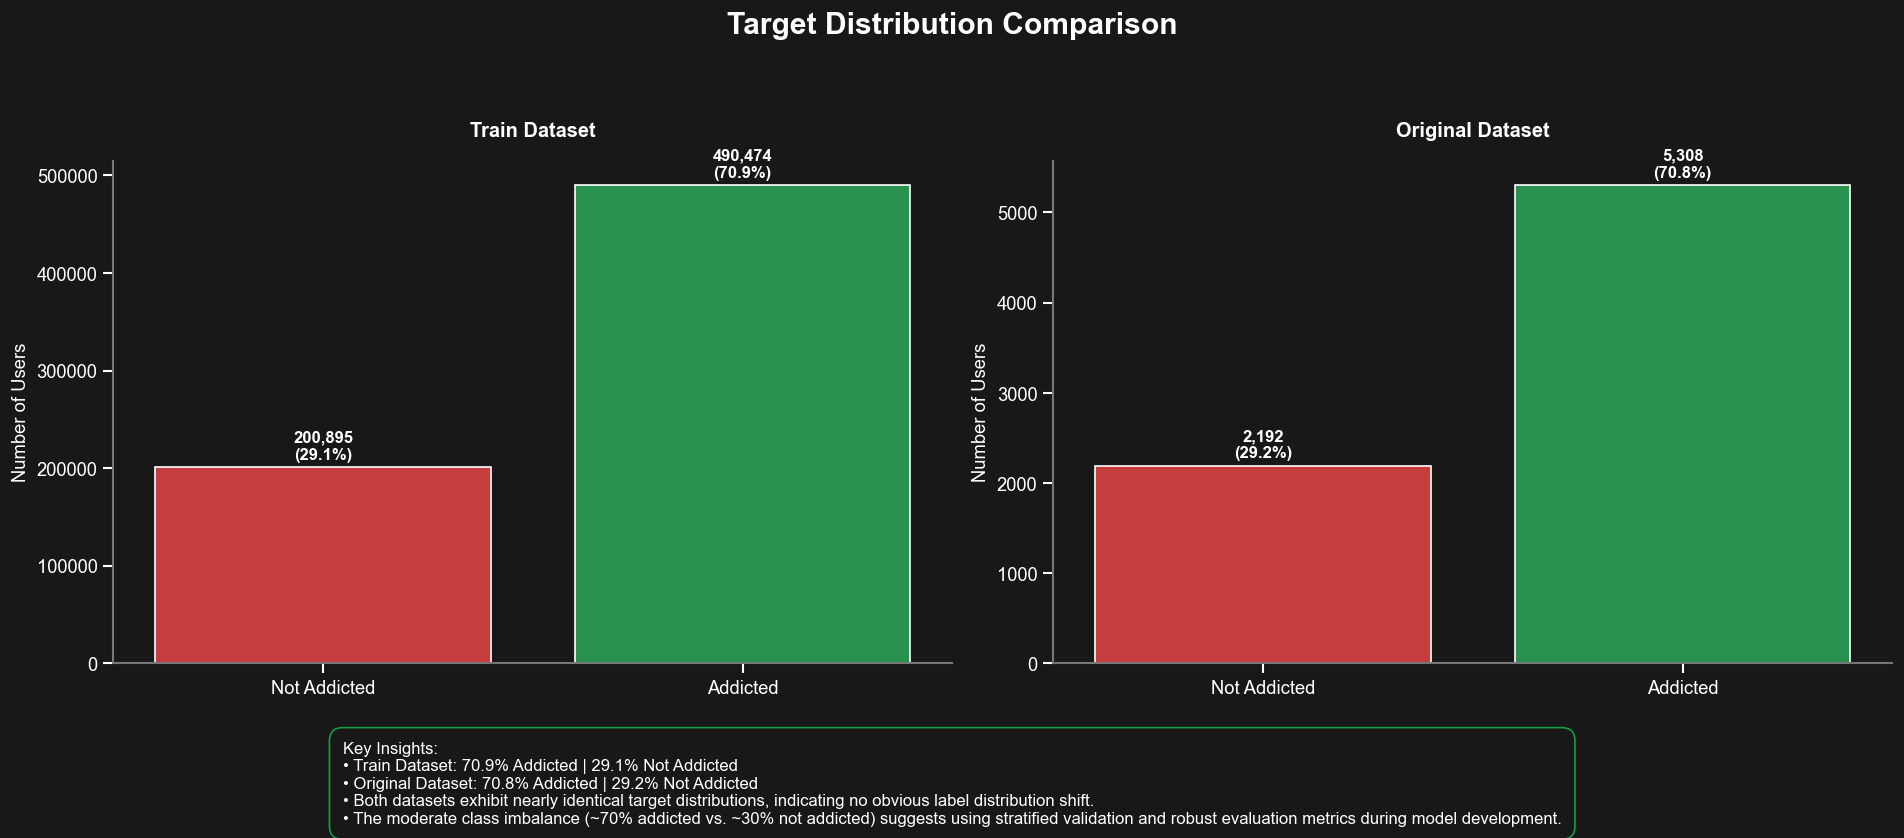

In [80]:
# Target Distribution Comparison
mapping = {0: "Not Addicted", 1: "Addicted"}
order = ["Not Addicted", "Addicted"]
colors = ["#DC2626", "#16A34A"]
datasets = {"Train Dataset": df_train, "Original Dataset": df_original}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="#181818")

distribution_summary = {}

for ax, (dataset_name, df) in zip(axes, datasets.items()):
    # Copy dataframe
    df_plot = df.copy()

    # Map target labels
    df_plot[CFG.TARGET_FEATURE] = df_plot[CFG.TARGET_FEATURE].map(mapping)

    # Target distribution
    target_distribution = df_plot[CFG.TARGET_FEATURE].value_counts().reindex(order)

    total = len(df_plot)

    distribution_summary[dataset_name] = {
        "Not Addicted": target_distribution["Not Addicted"] / total * 100,
        "Addicted": target_distribution["Addicted"] / total * 100
    }
    
    # Count Plot    
    sns.countplot(data=df_plot, x=CFG.TARGET_FEATURE, order=order, palette=colors, ax=ax)
    ax.set_title(dataset_name, fontsize=12, fontweight="bold", pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("Number of Users", fontsize=11)
    sns.despine(ax=ax)
    
    # Count + Percentage Labels    
    for container in ax.containers:
        labels = [
            f"{int(bar.get_height()):,}\n({bar.get_height()/total:.1%})"
            for bar in container
        ]
        ax.bar_label(container, labels=labels, fontsize=10, fontweight="bold", padding=3)

# Disable grid
for ax in axes:
    ax.grid(False)

# Overall Title
plt.suptitle("Target Distribution Comparison", fontsize=18, fontweight="bold")

# Overall Insight
train_not = distribution_summary["Train Dataset"]["Not Addicted"]
train_add = distribution_summary["Train Dataset"]["Addicted"]

original_not = distribution_summary["Original Dataset"]["Not Addicted"]
original_add = distribution_summary["Original Dataset"]["Addicted"]

insight = (
    "Key Insights:\n"
    f"• Train Dataset: {train_add:.1f}% Addicted | {train_not:.1f}% Not Addicted\n"
    f"• Original Dataset: {original_add:.1f}% Addicted | {original_not:.1f}% Not Addicted\n"
    "• Both datasets exhibit nearly identical target distributions, indicating no obvious label distribution shift.\n"
    "• The moderate class imbalance (~70% addicted vs. ~30% not addicted) suggests using stratified validation and robust evaluation metrics during model development."
)

fig.text(
    0.5,
    0.01,
    insight,
    ha="center",
    va="bottom",
    multialignment="left",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#181818",
        edgecolor="#16A34A",
        alpha=0.95
    )
)

# Leave space for insight box
plt.tight_layout(rect=[0, 0.14, 1, 0.93])
plt.show()

## Numerical Feature Distributions

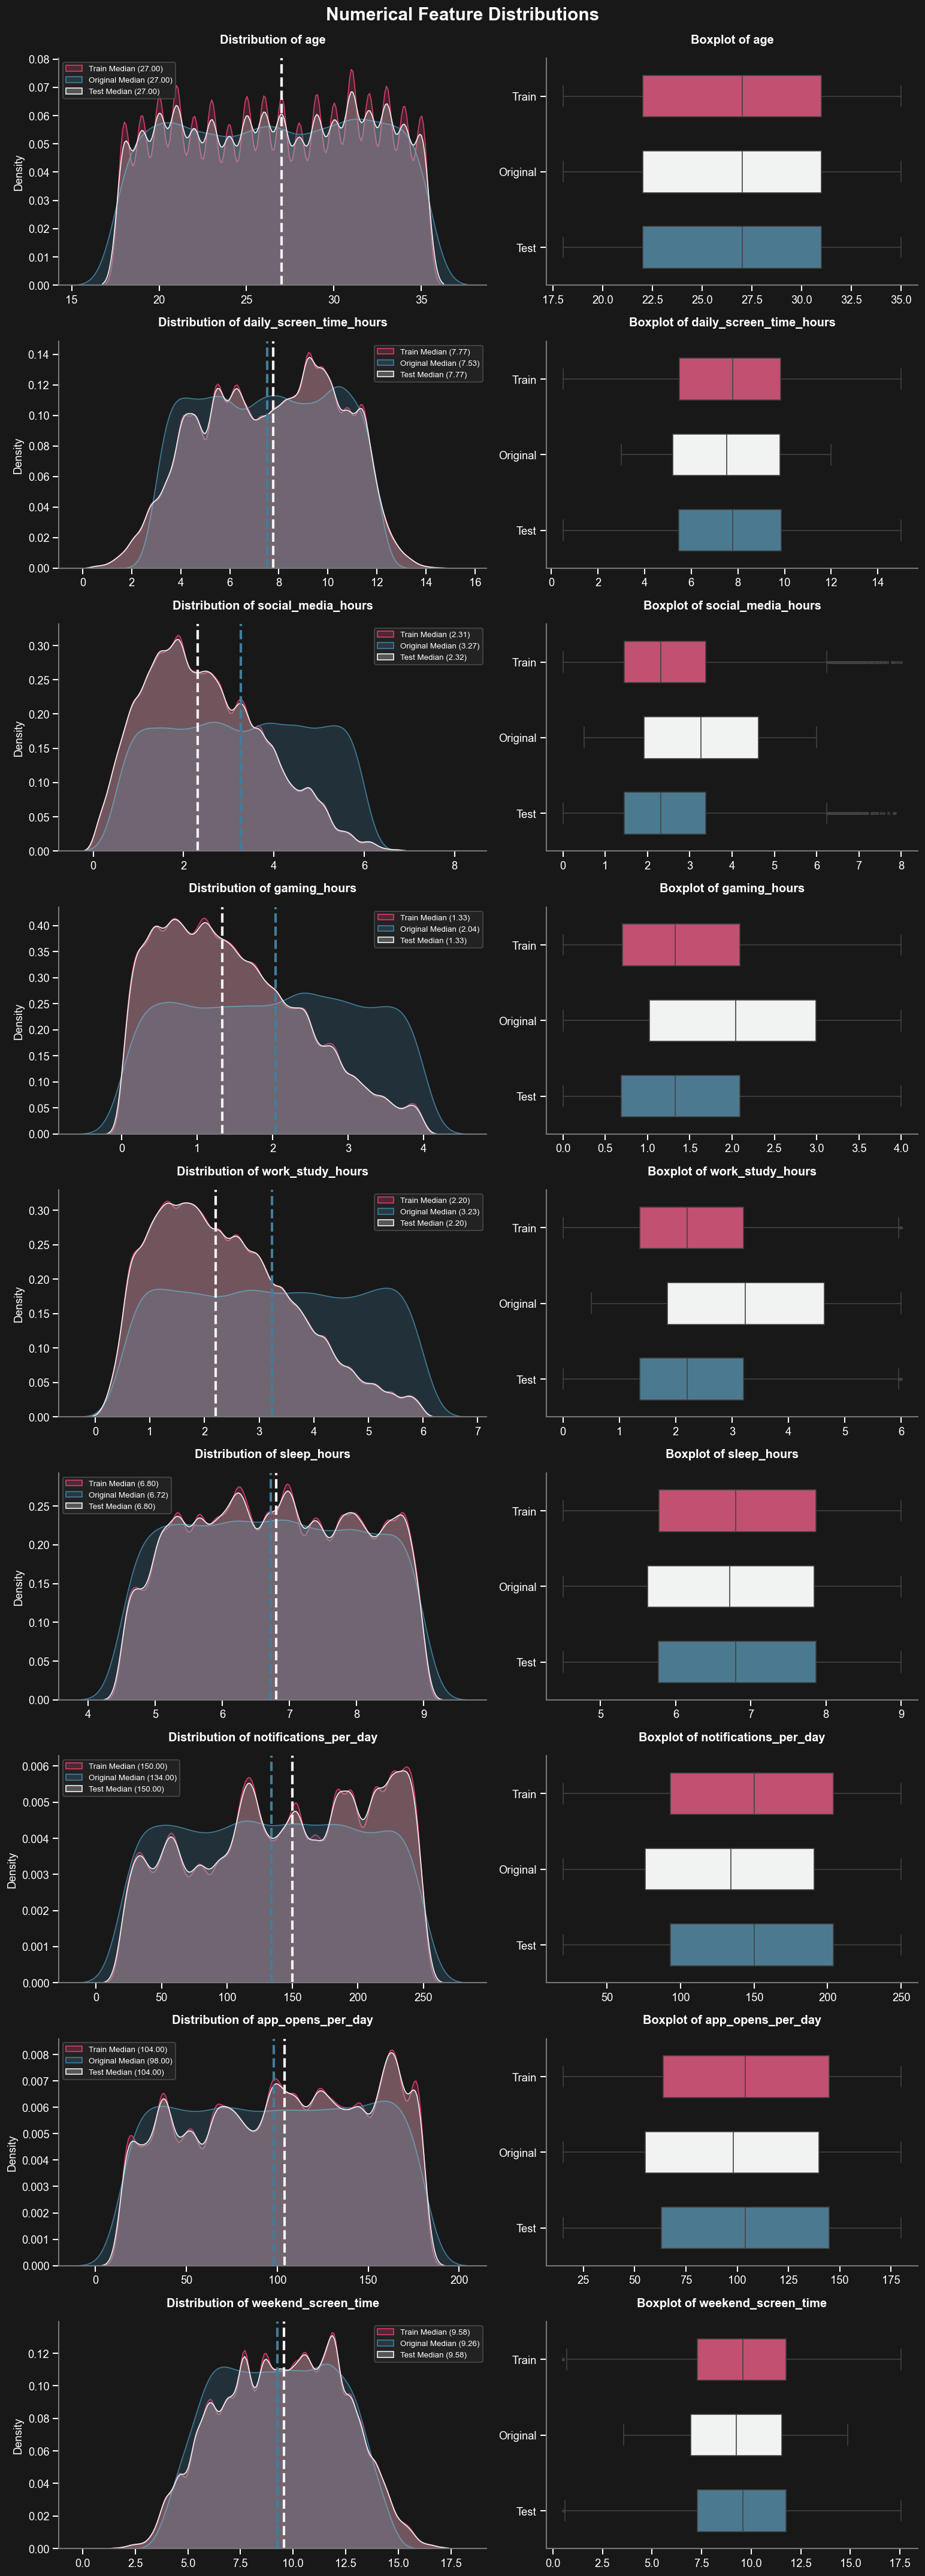

In [81]:
def plot_numerical_features(
    df_train: pd.DataFrame, df_test: pd.DataFrame, df_original: pd.DataFrame, num_features: List[str]
) -> None:
    """
    Plot numerical feature distributions.

    Left:
        - Histogram (Train vs Test)
        - Median line for each dataset

    Right:
        - Horizontal boxplot comparison
    """
    
    # Generate color palette for 3 datasets
    colors = color(n_colors=3)
    train_color, test_color, original_color = colors
    n_features = len(num_features)

    # Create subplot grid: each feature has 1 row, 2 columns (hist + boxplot)
    fig, axes = plt.subplots(nrows=n_features, ncols=2, figsize=(13, 4 * n_features), 
                             facecolor="#181818", gridspec_kw={"width_ratios": [1.15, 1]})
    axes = np.array(axes).reshape(n_features, 2)

    fig.suptitle("Numerical Feature Distributions", fontsize=18, fontweight="bold", y=0.995)
    
    # Plot Each Feature    
    for i, feature in enumerate(num_features):
        train_data = df_train[feature].dropna()
        original_data = df_original[feature].dropna()
        test_data = df_test[feature].dropna()

        train_median = train_data.median()
        original_median = original_data.median()
        test_median = test_data.median()

        # kdeplot
        sns.kdeplot(train_data, color=train_color, label="Train", ax=axes[i, 0], fill=True)
        sns.kdeplot(original_data, color=original_color, label="Original", ax=axes[i, 0], fill=True)
        sns.kdeplot(test_data,  color=test_color, label="Test",  ax=axes[i, 0], fill=True)

        # Median Lines
        axes[i, 0].axvline(train_median, color=train_color, linestyle="--", linewidth=2.5, label=f"Train Median ({train_median:.2f})")
        axes[i, 0].axvline(original_median, color=original_color, linestyle="--", linewidth=2.5, label=f"Original Median ({original_median:.2f})")
        axes[i, 0].axvline(test_median, color=test_color, linestyle="--", linewidth=2.5, label=f"Test Median ({test_median:.2f})")
        axes[i, 0].set_title(f"Distribution of {feature}", fontsize=12, fontweight="bold", pad=15)
        axes[i, 0].set_xlabel("")
        axes[i, 0].set_ylabel("Density")
        axes[i, 0].legend(fontsize=9)
        axes[i, 0].grid(False)
        sns.despine(ax=axes[i, 0])

        # Legend
        legend = axes[i, 0].legend(
            [
                f"Train Median ({train_median:.2f})",
                f"Original Median ({original_median:.2f})",
                f"Test Median ({test_median:.2f})",
            ],
            loc="best",
            fontsize=8,
            frameon=True,
            facecolor="#252525",
            edgecolor="#555555",
        )

        for text in legend.get_texts():
            text.set_color("white")

        # Prepare Data for Boxplot
        df_plot = pd.concat([
                pd.DataFrame({"Dataset": "Train", feature: train_data}),
                pd.DataFrame({"Dataset": "Original", feature: original_data}),
                pd.DataFrame({"Dataset": "Test", feature: test_data}),
            ],
            ignore_index=True
        )

        # Boxplot
        sns.boxplot(data=df_plot, x=feature, y="Dataset", orient="h", palette=colors, width=0.55, fliersize=2, ax=axes[i, 1])
        axes[i, 1].set_title(f"Boxplot of {feature}", fontsize=12, fontweight="bold", pad=15)
        axes[i, 1].set_xlabel("")
        axes[i, 1].set_ylabel("")
        # axes[i, 1].grid(axis="x", linestyle="--", alpha=0.25)
        axes[i, 1].grid(False)
        sns.despine(ax=axes[i, 1])

    plt.tight_layout()
    plt.show()

plot_numerical_features(df_train=df_train, df_test=df_test, df_original=df_original, num_features=num_features)

### Analyze skewness

In [82]:
def check_skewness(data: pd.DataFrame, dataset_name: str, numerical_features: List[str] =num_features, 
                   sort=True, logger: logging.Logger=logger):
    """
    Analyze skewness of numerical features in a dataset and log summary insights.

    This function computes the skewness for each numerical feature, optionally
    sorts them by absolute skewness, and categorizes features based on the
    degree of skewness. Detailed results are logged at DEBUG level, while
    high-level insights and recommendations are logged at INFO level.

    Parameters
    ----------
    data : pandas.DataFrame
        The input dataset containing numerical features to be analyzed.

    dataset_name : str
        A descriptive name of the dataset, used for logging and reporting.

    numerical_features : list of str, optional
        List of numerical feature names to evaluate.
        Default is `num_features`.

    sort : bool, optional (default=True)
        If True, sort features by absolute skewness in descending order.

    logger : logging.Logger
        Logger object used to output analysis results and insights.

    Returns
    -------
    list of str
        A list of feature names that are considered highly skewed
        (|skewness| > 1).

    Notes
    -----
    - Skewness interpretation:
        * |skew| ≤ 0.5  : Approximately symmetric
        * 0.5 < |skew| ≤ 1 : Moderately skewed
        * |skew| > 1   : Highly skewed
    - Highly skewed features may benefit from transformations such as:
        log, Box-Cox, or Yeo-Johnson.
    - This function is intended for exploratory data analysis (EDA)
      and feature preprocessing stages.
    """

    skewness_dict = {}
    skew_features = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)

    # ===== Summary header =====
    logger.info(f"Skewness analysis for {dataset_name}")
    logger.info(f"Total numerical features checked: {len(skew_df)}")

    # ===== Detailed table (DEBUG) =====
    logger.debug("-"*70)
    logger.debug(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    logger.debug("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            skew_features.append(feature)
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
        else:
            remark = "Approximately symmetric"
        logger.debug(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    logger.debug("-" * 70)

    # ===== Summary insight =====
    if skew_features:
        logger.info(f"{len(skew_features)} features are highly skewed (|skew| > 1).")
        logger.info(f"Recommendation: Consider log / Box-Cox / Yeo-Johnson transformation.")
    else:
        logger.info("No highly skewed features detected.")

    return skew_features

skew_feature_train = check_skewness(df_train, CFG.DATASET_NAME + " Data Train")
logger.info("-" * 80)
skew_feature_original = check_skewness(df_original, CFG.DATASET_NAME + " Data Original")
logger.info("-" * 80)
skew_feature_test = check_skewness(df_test, CFG.DATASET_NAME + " Data Test")
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-08-10 22:19:11 | INFO     | Skewness analysis for Smartphone Addiction Data Train
2026-08-10 22:19:11 | INFO     | Total numerical features checked: 9
2026-08-10 22:19:11 | DEBUG    | ----------------------------------------------------------------------
2026-08-10 22:19:11 | DEBUG    | Feature                        | Skewness  | Remark
2026-08-10 22:19:11 | DEBUG    | ----------------------------------------------------------------------
2026-08-10 22:19:11 | DEBUG    | work_study_hours               |   +0.5635 | Moderately skewed
2026-08-10 22:19:11 | DEBUG    | gaming_hours                   |   +0.5447 | Moderately skewed
2026-08-10 22:19:11 | DEBUG    | social_media_hours             |   +0.4681 | Approximately symmetric
2026-08-10 22:19:11 | DEBUG    | notifications_per_day          |   -0.2065 | Approximately symmetric
2026-08-10 22:19:11 | DEBUG    | daily_screen_time_hours        |   -0.1320 | Approximately symmetric
2026-08-10 22:19:11 | DEBUG    | app_opens_per_day   

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Distribution & Skewness Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li>The <b>training, test, and original datasets</b> exhibit broadly consistent numerical distributions, with similar medians and value ranges, suggesting <b>no meaningful dataset shift</b>.</li>

<li><code>social_media_hours</code>, <code>gaming_hours</code>, and <code>work_study_hours</code> show slightly higher values in the original dataset, but the overall distribution patterns remain comparable across datasets.</li>

<li><code>work_study_hours</code> and <code>gaming_hours</code> are <b>moderately right-skewed</b> in the training and test datasets (<code>skew ≈ 0.54–0.56</code>), indicating that a relatively small group of users spends substantially more time on these activities.</li>

<li>All remaining numerical features, including <code>age</code>, <code>daily_screen_time_hours</code>, <code>sleep_hours</code>, <code>notifications_per_day</code>, <code>app_opens_per_day</code>, and <code>weekend_screen_time</code>, are <b>approximately symmetric</b>, reflecting balanced value distributions.</li>

<li><b>No highly skewed features</b> were identified (<code>|skew| &lt; 1</code> for every numerical variable), suggesting that additional transformations such as logarithmic or Box-Cox scaling are generally unnecessary before model development.</li>

</ul>

</div>

### Correlation Analysis of Numerical Features

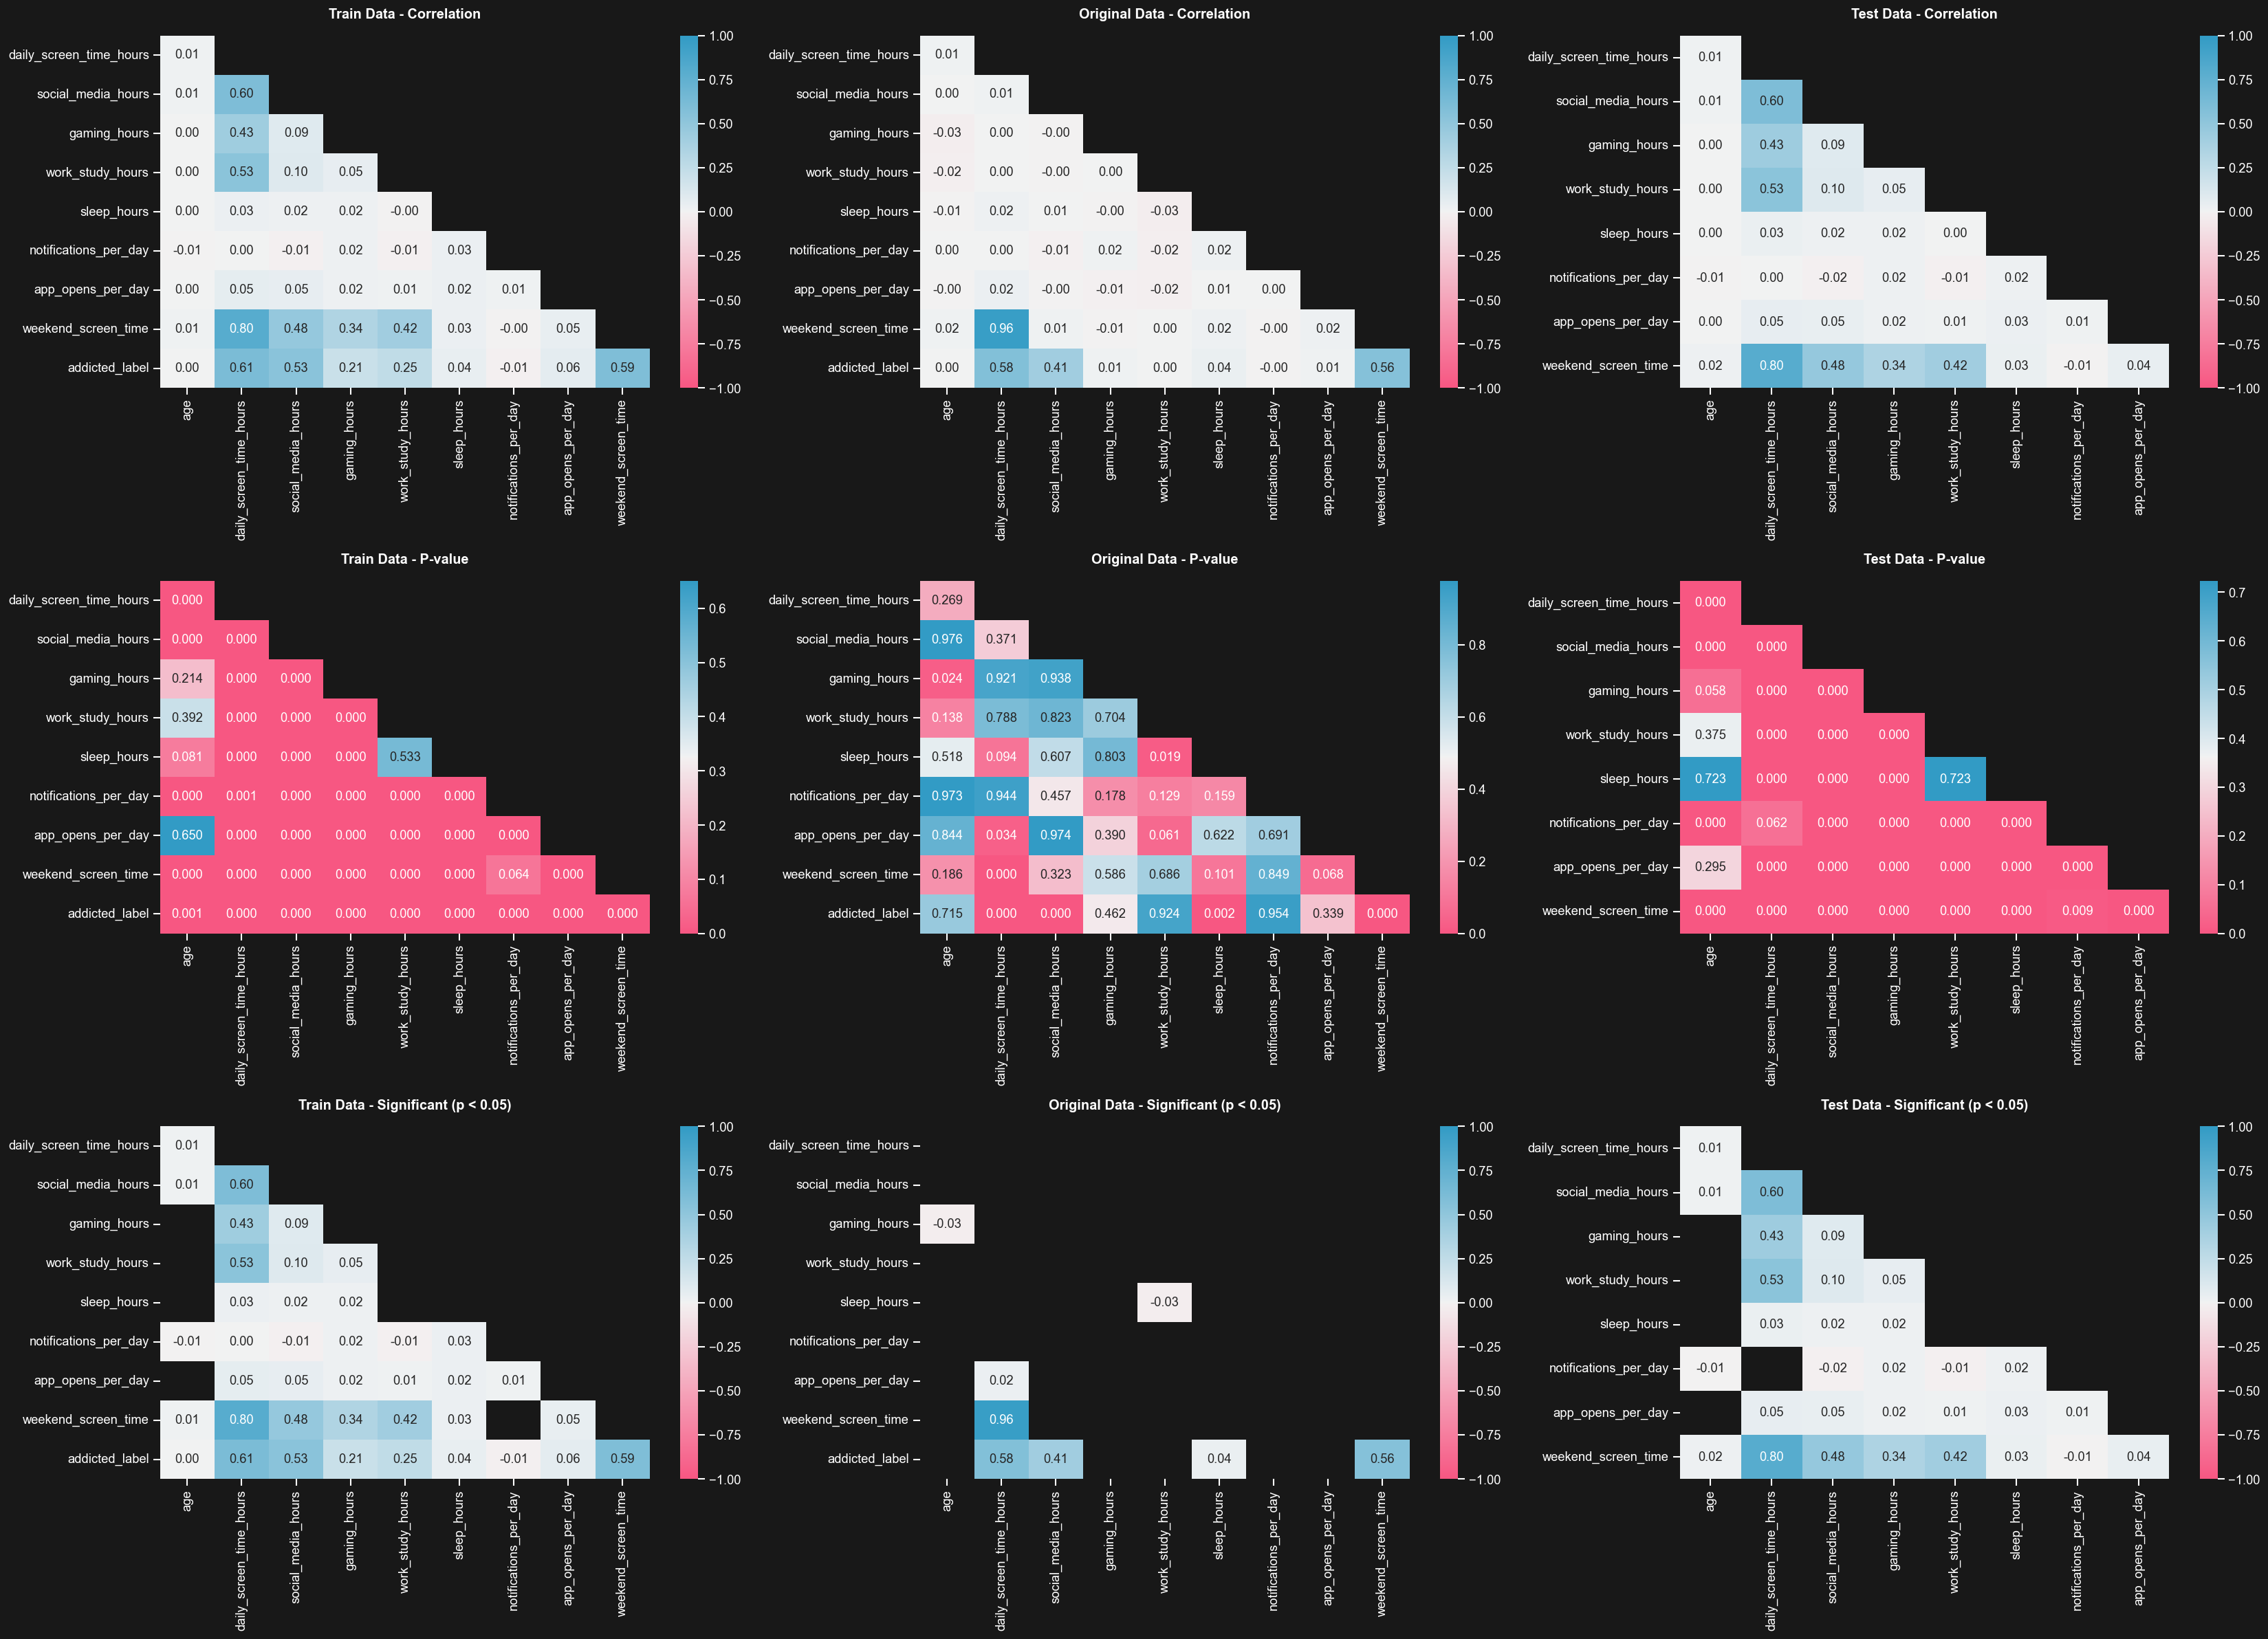

In [83]:
def _compute_corr_pval(df: pd.DataFrame):
    """
    Compute pairwise correlation coefficients and p-values.

    Correlation method:
    - Pearson correlation:
        Continuous ↔ Continuous
    - Point-biserial correlation:
        Binary (0/1) ↔ Continuous

    Notes
    -----
    If the dataset contains no binary numeric variables
    (e.g. competition test dataset), all correlations
    are computed using Pearson correlation.
    """
    
    # Select numeric columns    
    cols = df.select_dtypes(include=np.number).columns.tolist()
    
    # Detect binary numeric columns only once    
    binary_cols = {col for col in cols if set(df[col].dropna().unique()).issubset({0, 1})}
    
    # Initialize matrices    
    corr_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)
    pval_matrix = pd.DataFrame(np.nan, index=cols, columns=cols)
    
    # Pairwise computation    
    for col_x in cols:
        for col_y in cols:
            # Diagonal
            if col_x == col_y:
                corr_matrix.loc[col_x, col_y] = 1.0
                pval_matrix.loc[col_x, col_y] = 0.0
                continue

            # Pairwise remove missing values
            pair = df[[col_x, col_y]].dropna()

            if len(pair) < 3:
                continue

            x = pair[col_x]
            y = pair[col_y]

            try:                
                # Binary vs Continuous
                if (
                    col_x in binary_cols
                    and col_y not in binary_cols
                ):
                    r, p = pointbiserialr(x, y)

                elif (
                    col_y in binary_cols
                    and col_x not in binary_cols
                ):
                    r, p = pointbiserialr(y, x)
                
                # Continuous vs Continuous
                # OR Binary vs Binary
                else:

                    r, p = pearsonr(x, y)

                corr_matrix.loc[col_x, col_y] = r
                pval_matrix.loc[col_x, col_y] = p

            except Exception:
                corr_matrix.loc[col_x, col_y] = np.nan
                pval_matrix.loc[col_x, col_y] = np.nan

    return corr_matrix, pval_matrix

def _prepare_heatmap(matrix: pd.DataFrame):
    """
    Prepare lower-triangular matrix for heatmap visualization.
    """

    mask = np.triu(np.ones_like(matrix, dtype=bool))

    return (
        matrix.iloc[1:, :-1],
        mask[1:, :-1]
    )

def plot_correlation_with_pvalue(df_train: pd.DataFrame, df_test: pd.DataFrame, df_original: pd.DataFrame,
                                 train_name: str = "Train Data", original_name: str = "Original Data", test_name: str = "Test Data") -> None:
    """
    Plot correlation and statistical significance.

    Row 1
    -----
    Correlation matrix

    Row 2
    -----
    P-value matrix

    Row 3
    -----
    Significant correlations only (p < 0.05)
    """
    
    # Compute matrices    
    corr_train, p_train = _compute_corr_pval(df_train)
    corr_original, p_original = _compute_corr_pval(df_original)
    corr_test, p_test = _compute_corr_pval(df_test)
    
    # Prepare triangular matrices    
    corr_train, mask_train = _prepare_heatmap(corr_train)
    p_train, _ = _prepare_heatmap(p_train)

    corr_original, mask_original = _prepare_heatmap(corr_original)
    p_original, _ = _prepare_heatmap(p_original)

    corr_test, mask_test = _prepare_heatmap(corr_test)
    p_test, _ = _prepare_heatmap(p_test)
    
    # Plot settings    
    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
    fig, axes = plt.subplots(3, 3, figsize=(28, 20), facecolor="#181818")

    datasets = [
        (corr_train, p_train, mask_train, train_name),
        (corr_original, p_original, mask_original, original_name),
        (corr_test,  p_test,  mask_test, test_name)
    ]
    
    # Plot each dataset    
    for col, (corr, pval, mask, title) in enumerate(datasets):        
        # Correlation        
        sns.heatmap(corr,  mask=mask, annot=True, fmt=".2f",  cmap=cmap, vmin=-1, vmax=1, linewidths=0, linecolor="white", ax=axes[0, col])
        axes[0, col].grid(False)
        axes[0, col].set_title(f"{title} - Correlation", fontsize=12, fontweight="bold", pad=15)
        
        # P-value        
        sns.heatmap(pval, mask=mask, annot=True, fmt=".3f", cmap=cmap, linewidths=0, linecolor="white", ax=axes[1, col])
        axes[1, col].grid(False)
        axes[1, col].set_title(f"{title} - P-value", fontsize=12, fontweight="bold", pad=15)
        
        # Significant correlation only        
        significant_corr = corr.where(pval < 0.05)
        sns.heatmap(significant_corr, mask=mask, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1, linewidths=0, linecolor="white", ax=axes[2, col])
        axes[2, col].grid(False)
        axes[2, col].set_title(f"{title} - Significant (p < 0.05)", fontsize=12, fontweight="bold", pad=15)

    plt.tight_layout()
    plt.show()

plot_correlation_with_pvalue(df_train=df_train, df_test=df_test, df_original=df_original)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Correlation Analysis Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li>The <b>training, test, and original datasets</b> exhibit broadly consistent correlation patterns, indicating <b>no meaningful structural differences</b> among the datasets.</li>

<li>Most feature pairs show <b>weak to moderate correlations</b>, suggesting limited multicollinearity and that each variable contributes complementary information for prediction.</li>

<li><code>daily_screen_time_hours</code> has the strongest positive relationship with <code>weekend_screen_time</code> (<b>r ≈ 0.80–0.96</b>), indicating that users with heavier weekday smartphone usage also tend to spend substantially more time on their phones during weekends.</li>

<li><code>addicted_label</code> is most strongly associated with <code>daily_screen_time_hours</code> (<b>r ≈ 0.58–0.61</b>), <code>weekend_screen_time</code> (<b>r ≈ 0.56–0.59</b>), and <code>social_media_hours</code> (<b>r ≈ 0.41–0.53</b>), highlighting these variables as the strongest behavioral indicators of smartphone addiction.</li>

<li>Because the <b>training and test datasets contain much larger sample sizes</b>, many weak correlations become statistically significant (<code>p &lt; 0.05</code>). In contrast, the original dataset retains similar correlation directions but fewer weak relationships reach statistical significance due to its substantially smaller sample size.</li>

</ul>

</div>

## Categorical Feature Distributions

In [84]:
def categorical_distribution_across_datasets(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    df_original: pd.DataFrame,
    feature: str,
    logger: logging.Logger
) -> None:

    logger.info(f"Analyzing categorical feature: {feature}")

    # TRAIN
    train_summary = (
        df_train[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Train_Count")
    )
    train_summary["Train_%"] = round(
        train_summary["Train_Count"] / train_summary["Train_Count"].sum() * 100, 2
    )

    # ORIGINAL
    original_summary = (
        df_original[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Original_Count")
    )
    original_summary["Original_%"] = round(
        original_summary["Original_Count"] / original_summary["Original_Count"].sum() * 100, 2
    )

    # TEST
    test_summary = (
        df_test[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Test_Count")
    )
    test_summary["Test_%"] = round(
        test_summary["Test_Count"] / test_summary["Test_Count"].sum() * 100, 2
    )

    # Merge ALL
    summary = train_summary.merge(original_summary, on="Category", how="outer")
    summary = summary.merge(test_summary, on="Category", how="outer")

    logger.debug(f"{feature}: {len(summary)} categories detected")
    summary["Category"] = summary["Category"].astype(str)

    num_cols = [
        "Train_Count", "Train_%",
        "Original_Count", "Original_%",
        "Test_Count", "Test_%"
    ]

    summary[num_cols] = summary[num_cols].fillna(0)
    summary = summary.sort_values(by="Train_Count", ascending=False)

    logger.info(
        f"Categorical Feature Distribution: {feature}:\n"
        f"{summary.to_string()}"
    )

    logger.info(f"Completed analysis for: {feature}")
    logger.info("*" * 80)

for feature in cat_features:
    categorical_distribution_across_datasets(df_train=df_train, df_test=df_test, df_original=df_original, feature=feature, logger=logger)

2026-08-10 22:19:18 | INFO     | Analyzing categorical feature: gender
2026-08-10 22:19:18 | DEBUG    | gender: 3 categories detected
2026-08-10 22:19:18 | INFO     | Categorical Feature Distribution: gender:
  Category  Train_Count  Train_%  Original_Count  Original_%  Test_Count  Test_%
1     Male       223662    33.77            2553       34.04       95357   33.80
0   Female       221595    33.46            2461       32.81       94295   33.43
2    Other       217078    32.77            2486       33.15       92438   32.77
2026-08-10 22:19:18 | INFO     | Completed analysis for: gender
2026-08-10 22:19:18 | INFO     | ********************************************************************************
2026-08-10 22:19:18 | INFO     | Analyzing categorical feature: stress_level
2026-08-10 22:19:18 | DEBUG    | stress_level: 3 categories detected
2026-08-10 22:19:18 | INFO     | Categorical Feature Distribution: stress_level:
  Category  Train_Count  Train_%  Original_Count  Original_%  

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Categorical Feature Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><code>gender</code> is remarkably well balanced across all three categories (<code>Male</code>, <code>Female</code>, and <code>Other</code>), with each representing approximately <b>one-third</b> of users in the training, original, and test datasets.</li>

<li><code>stress_level</code> also exhibits a balanced distribution, with the <code>High</code> category appearing only slightly more frequently (<b>≈34%</b>) than <code>Low</code> and <code>Medium</code> (both ≈33%).</li>

<li><code>academic_work_impact</code> is nearly evenly split between <code>Yes</code> and <code>No</code>, with just over <b>50%</b> of users reporting that smartphone usage affects their academic or work performance.</li>

<li>The categorical feature distributions are <b>highly consistent across the training, original, and test datasets</b>, indicating <b>no noticeable categorical distribution shift</b> and supporting reliable model development and evaluation.</li>

<li>Overall, the balanced categorical distributions reduce the risk of category bias and provide stable inputs for categorical encoding and downstream machine learning models.</li>

</ul>

</div>

## Multivariate Statistical Analysis

,addicted_label,Count,Mean,Median,Std
0,Addicted,469836,26.628750,27.000000,5.113040
1,Not Addicted,192604,26.582865,27.000000,5.249620


2026-08-10 22:19:18 | INFO     | Checking normality of feature 'age' by groups of 'addicted_label'...
2026-08-10 22:19:18 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-08-10 22:19:18 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:18 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-08-10 22:19:19 | DEBUG    | [addicted_label=0] skew=-0.0428, kurtosis=-1.2641 → Approximately symmetric, Normal tails
2026-08-10 22:19:19 | DEBUG    | [addicted_label=1] skew=-0.0337, kurtosis=-1.1978 → Approximately symmetric, Normal tails
2026-08-10 22:19:19 | INFO     | Generating Q–Q plots for visual assessment...


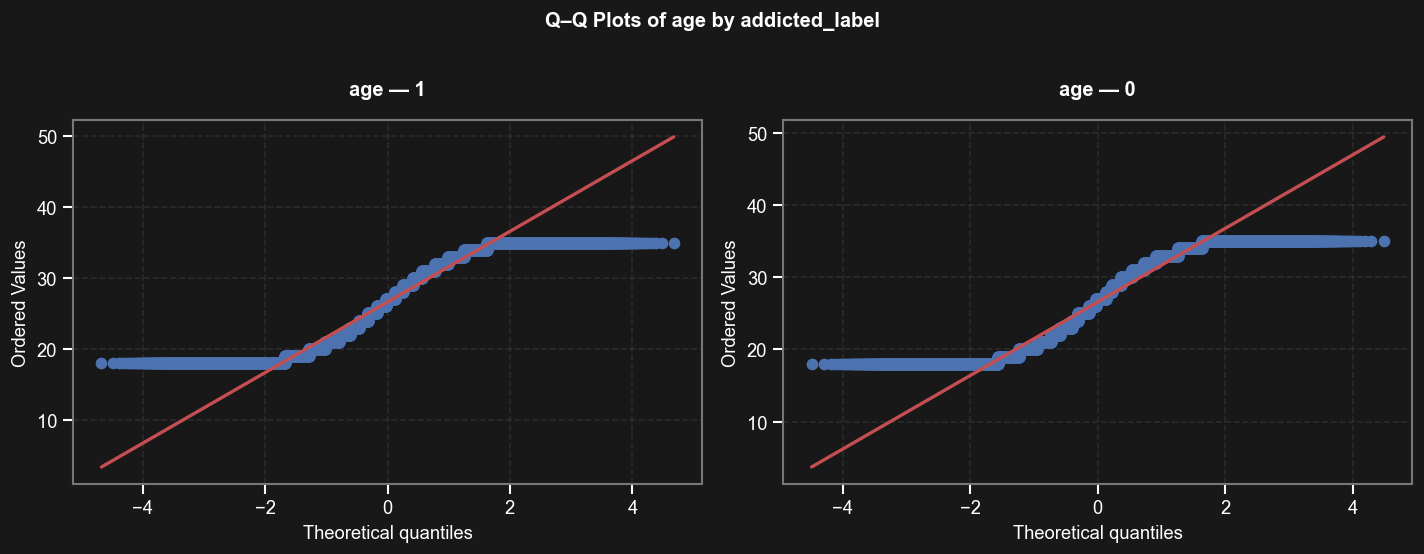

,Feature,Group,Skewness,Kurtosis,Remark
0,age,0,-0.0428,-1.2641,"Approximately symmetric, Normal tails"
1,age,1,-0.0337,-1.1978,"Approximately symmetric, Normal tails"


2026-08-10 22:19:21 | INFO     | All groups approximately follow a normal distribution.
2026-08-10 22:19:21 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-08-10 22:19:21 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,482.1839
1,p-value,0.000000
2,Max/Min Variance Ratio,1.05


2026-08-10 22:19:21 | INFO     | Interpretation:
2026-08-10 22:19:21 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-08-10 22:19:21 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-08-10 22:19:21 | INFO     | Running Independent Two-Sample T-Test: 'age' ~ 'addicted_label'
2026-08-10 22:19:21 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:21 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-08-10 22:19:21 | INFO     | Comparing groups: '1' vs '0'
2026-08-10 22:19:21 | INFO     | p-value: 0.001134
2026-08-10 22:19:21 | INFO     | Cohen's d: 0.009
2026-08-10 22:19:21 | DEBUG    | t-statistic: 3.255
2026-08-10 22:19:21 | DEBUG    | Group means → 1: 26.629, 0: 26.583
2026-08-10 22:19:21 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-08-10 22:19:21 | INFO     | Conclusion: Significant difference between the two groups.
2026-08-10 22:19:21 | 

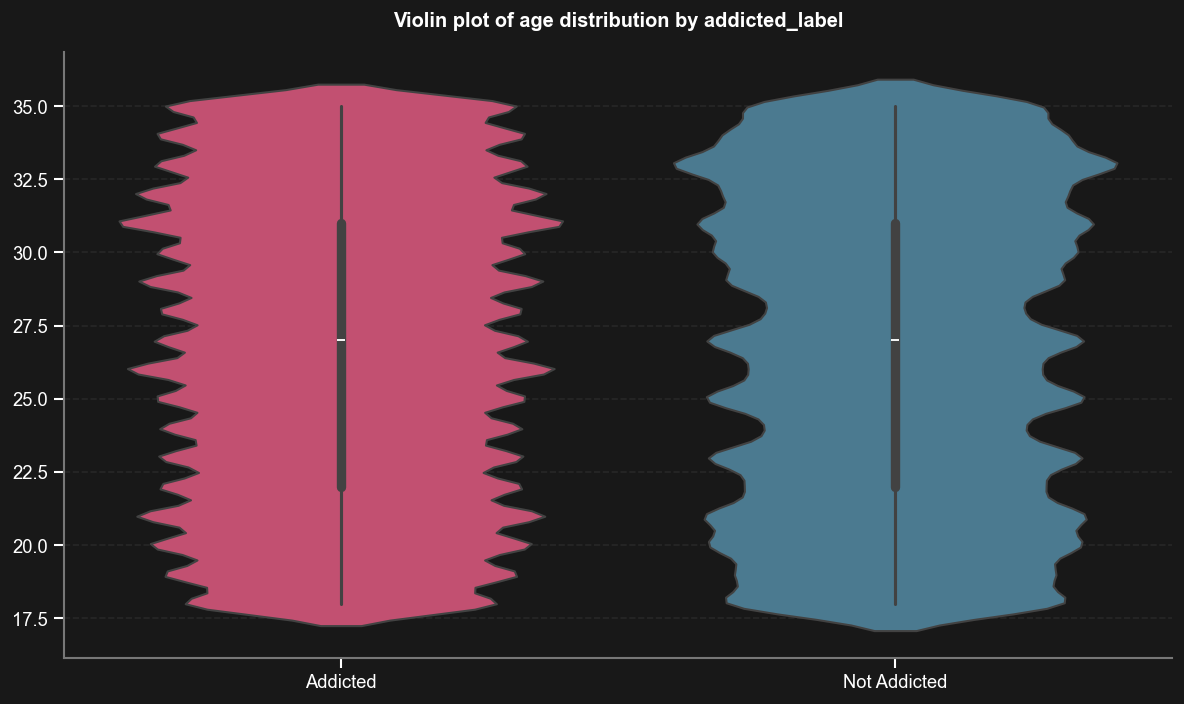

,addicted_label,Count,Mean,Median,Std
0,Addicted,422293,8.706523,9.070000,2.337327
1,Not Addicted,173222,5.042929,5.040000,1.620399


2026-08-10 22:19:25 | INFO     | Checking normality of feature 'daily_screen_time_hours' by groups of 'addicted_label'...
2026-08-10 22:19:25 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-08-10 22:19:25 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:25 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-08-10 22:19:25 | DEBUG    | [addicted_label=0] skew=0.0882, kurtosis=-0.2424 → Approximately symmetric, Normal tails
2026-08-10 22:19:25 | DEBUG    | [addicted_label=1] skew=-0.5477, kurtosis=-0.1989 → Moderately skewed, Normal tails
2026-08-10 22:19:25 | INFO     | Generating Q–Q plots for visual assessment...


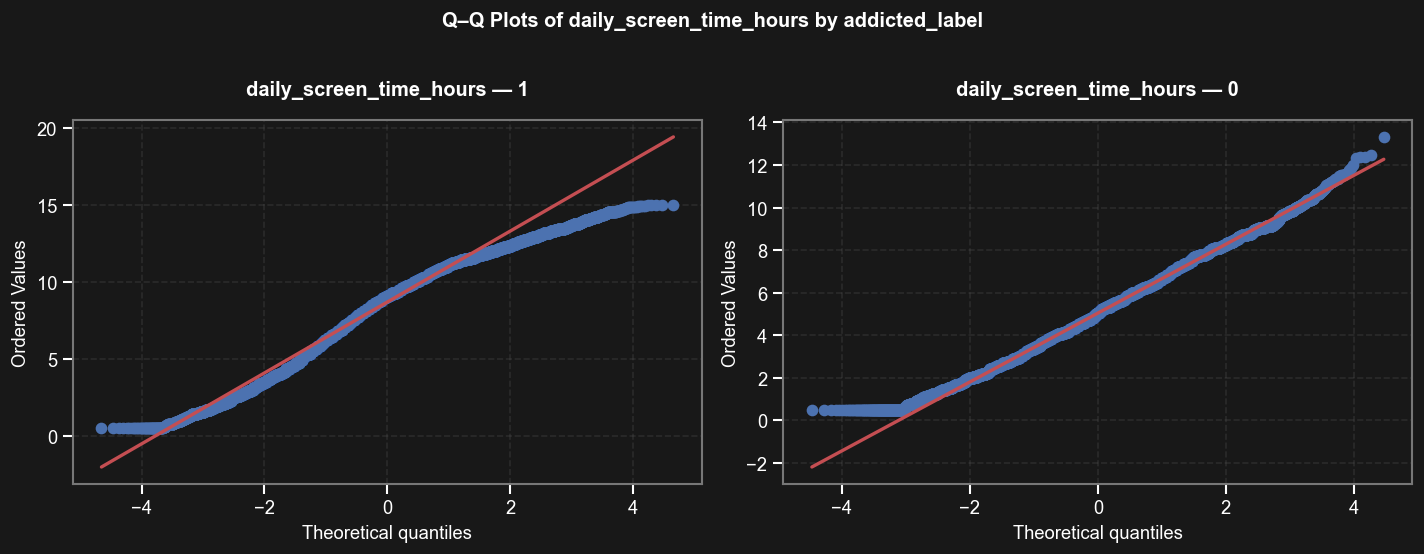

,Feature,Group,Skewness,Kurtosis,Remark
0,daily_screen_time_hours,0,0.0882,-0.2424,"Approximately symmetric, Normal tails"
1,daily_screen_time_hours,1,-0.5477,-0.1989,"Moderately skewed, Normal tails"


2026-08-10 22:19:27 | WARNING  | Normality assumption violated in at least one group.
2026-08-10 22:19:27 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-08-10 22:19:27 | INFO     | Running Mann–Whitney U Test: 'daily_screen_time_hours' by 'addicted_label'...
2026-08-10 22:19:27 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:27 | INFO     | U statistic: 65071013888.0
2026-08-10 22:19:27 | INFO     | p-value    : 0.000000
2026-08-10 22:19:27 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-08-10 22:19:27 | INFO     | Conclusion: Significant difference between the two groups.
2026-08-10 22:19:27 | INFO     | Effect size interpretation: Large


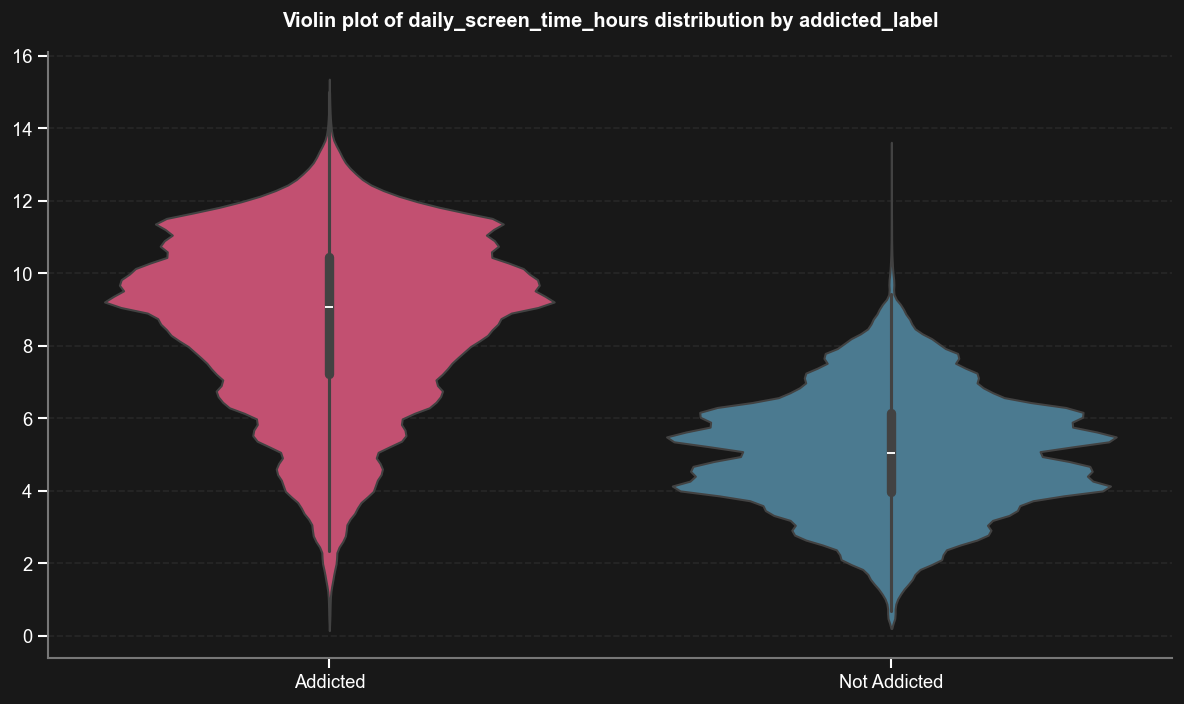

,addicted_label,Count,Mean,Median,Std
0,Addicted,395416,2.919495,2.820000,1.235099
1,Not Addicted,161958,1.376144,1.290000,0.739717


2026-08-10 22:19:31 | INFO     | Checking normality of feature 'social_media_hours' by groups of 'addicted_label'...
2026-08-10 22:19:31 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-08-10 22:19:31 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:31 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-08-10 22:19:31 | DEBUG    | [addicted_label=0] skew=0.6551, kurtosis=0.3717 → Moderately skewed, Normal tails
2026-08-10 22:19:31 | DEBUG    | [addicted_label=1] skew=0.2796, kurtosis=-0.3717 → Approximately symmetric, Normal tails
2026-08-10 22:19:31 | INFO     | Generating Q–Q plots for visual assessment...


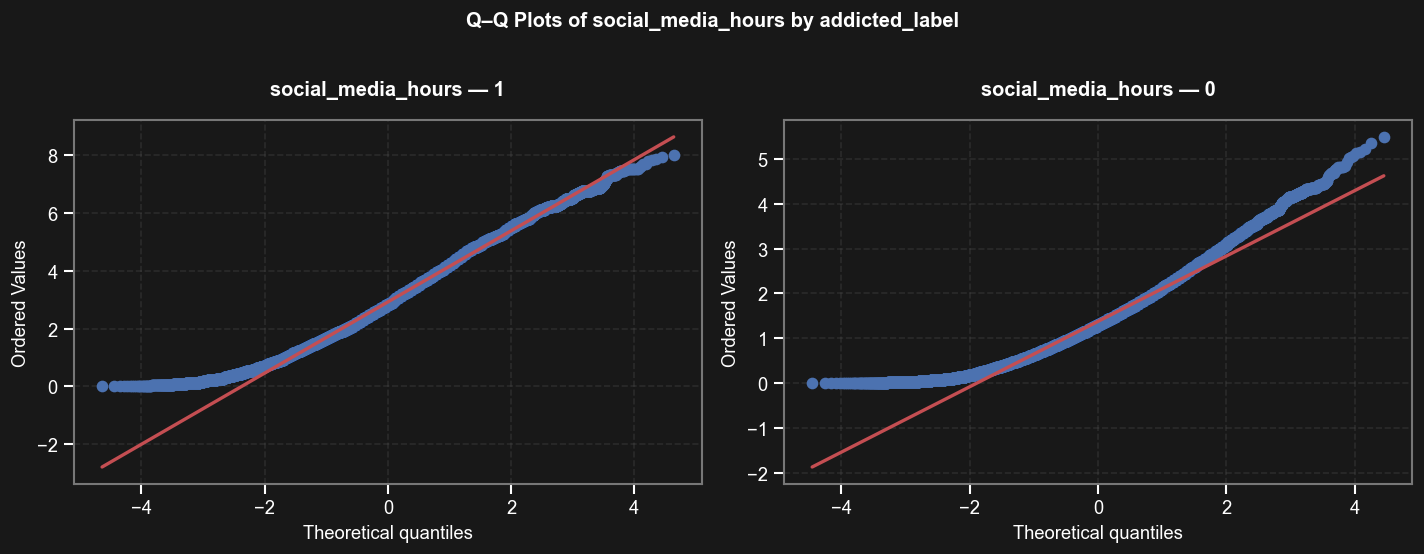

,Feature,Group,Skewness,Kurtosis,Remark
0,social_media_hours,0,0.6551,0.3717,"Moderately skewed, Normal tails"
1,social_media_hours,1,0.2796,-0.3717,"Approximately symmetric, Normal tails"


2026-08-10 22:19:33 | WARNING  | Normality assumption violated in at least one group.
2026-08-10 22:19:33 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-08-10 22:19:33 | INFO     | Running Mann–Whitney U Test: 'social_media_hours' by 'addicted_label'...
2026-08-10 22:19:33 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:33 | INFO     | U statistic: 54933053440.0
2026-08-10 22:19:33 | INFO     | p-value    : 0.000000
2026-08-10 22:19:33 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-08-10 22:19:33 | INFO     | Conclusion: Significant difference between the two groups.
2026-08-10 22:19:33 | INFO     | Effect size interpretation: Large


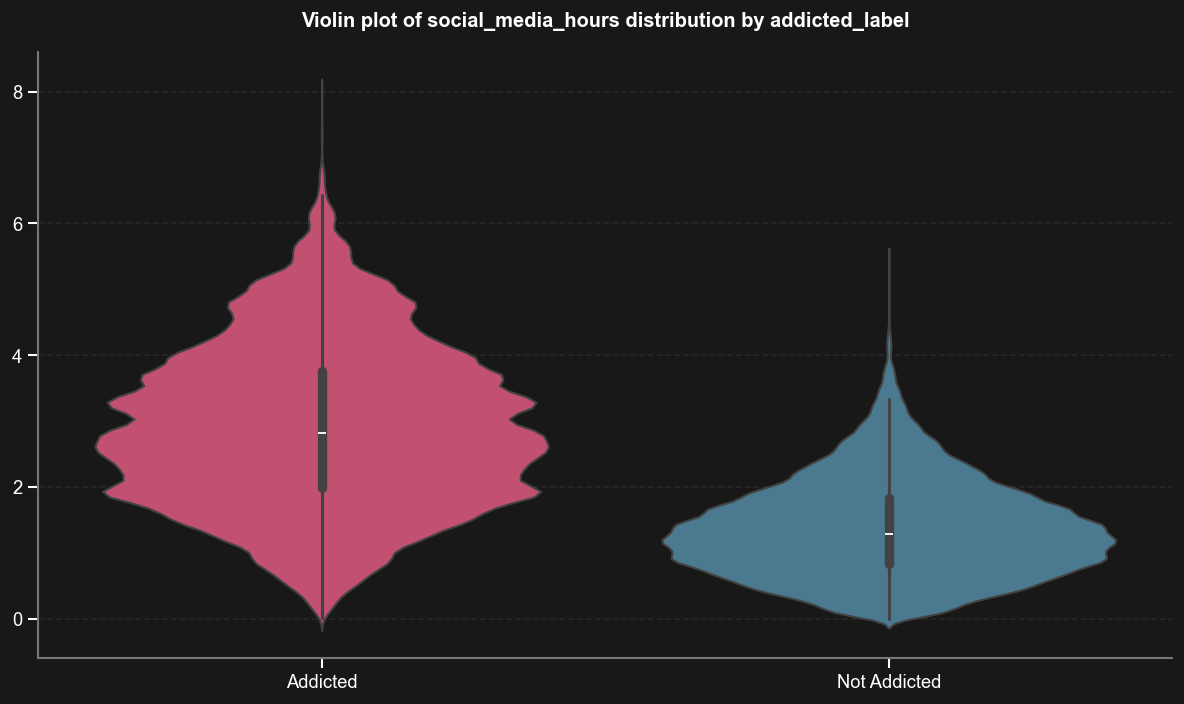

,addicted_label,Count,Mean,Median,Std
0,Addicted,400367,1.582119,1.480000,0.978345
1,Not Addicted,164181,1.159677,1.070000,0.736580


2026-08-10 22:19:36 | INFO     | Checking normality of feature 'gaming_hours' by groups of 'addicted_label'...
2026-08-10 22:19:36 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-08-10 22:19:36 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:36 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-08-10 22:19:36 | DEBUG    | [addicted_label=0] skew=0.7070, kurtosis=0.2368 → Moderately skewed, Normal tails
2026-08-10 22:19:36 | DEBUG    | [addicted_label=1] skew=0.3924, kurtosis=-0.7157 → Approximately symmetric, Normal tails
2026-08-10 22:19:36 | INFO     | Generating Q–Q plots for visual assessment...


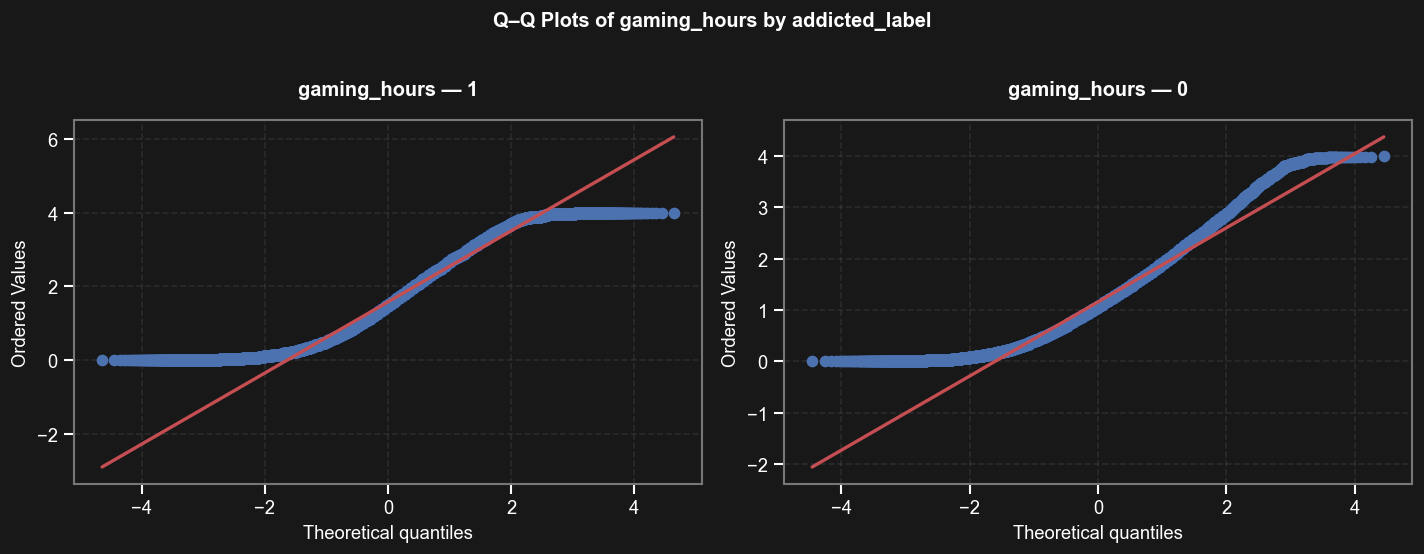

,Feature,Group,Skewness,Kurtosis,Remark
0,gaming_hours,0,0.7070,0.2368,"Moderately skewed, Normal tails"
1,gaming_hours,1,0.3924,-0.7157,"Approximately symmetric, Normal tails"


2026-08-10 22:19:38 | WARNING  | Normality assumption violated in at least one group.
2026-08-10 22:19:38 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-08-10 22:19:38 | INFO     | Running Mann–Whitney U Test: 'gaming_hours' by 'addicted_label'...
2026-08-10 22:19:38 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:38 | INFO     | U statistic: 40883068928.0
2026-08-10 22:19:38 | INFO     | p-value    : 0.000000
2026-08-10 22:19:38 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-08-10 22:19:38 | INFO     | Conclusion: Significant difference between the two groups.
2026-08-10 22:19:38 | INFO     | Effect size interpretation: Small


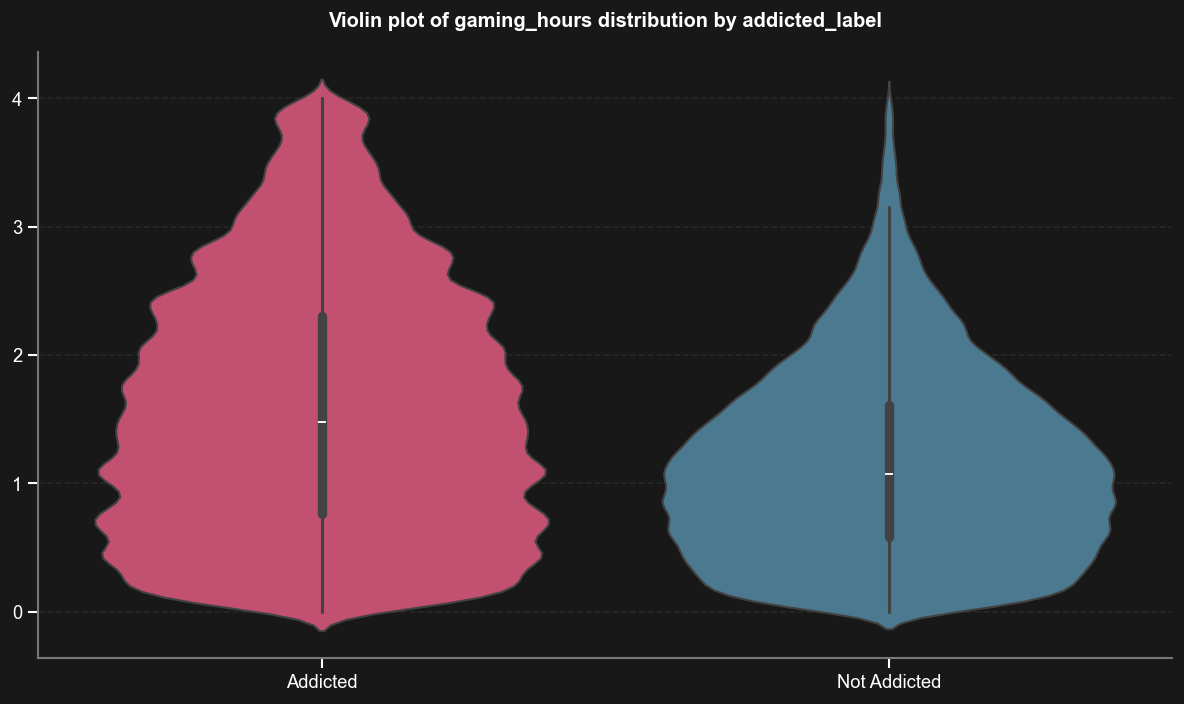

,addicted_label,Count,Mean,Median,Std
0,Addicted,453863,2.569566,2.470000,1.306252
1,Not Addicted,185988,1.872582,1.750000,0.971055


2026-08-10 22:19:42 | INFO     | Checking normality of feature 'work_study_hours' by groups of 'addicted_label'...
2026-08-10 22:19:42 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-08-10 22:19:42 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:42 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-08-10 22:19:42 | DEBUG    | [addicted_label=0] skew=0.7010, kurtosis=0.3510 → Moderately skewed, Normal tails
2026-08-10 22:19:42 | DEBUG    | [addicted_label=1] skew=0.4032, kurtosis=-0.5841 → Approximately symmetric, Normal tails
2026-08-10 22:19:42 | INFO     | Generating Q–Q plots for visual assessment...


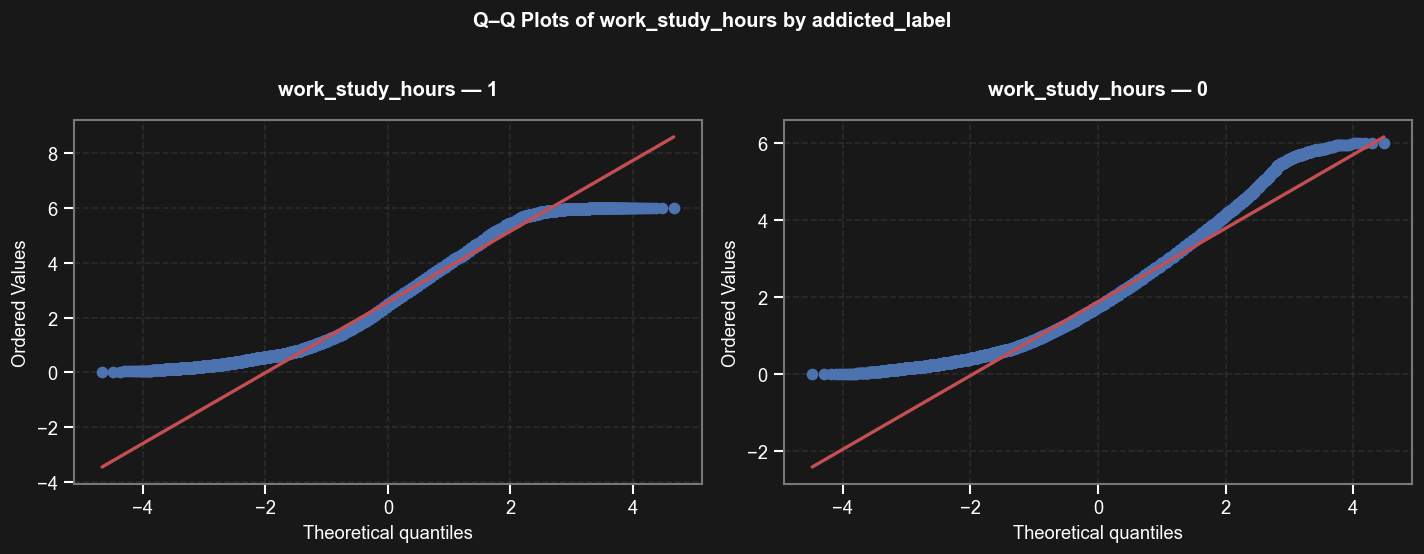

,Feature,Group,Skewness,Kurtosis,Remark
0,work_study_hours,0,0.7010,0.3510,"Moderately skewed, Normal tails"
1,work_study_hours,1,0.4032,-0.5841,"Approximately symmetric, Normal tails"


2026-08-10 22:19:44 | WARNING  | Normality assumption violated in at least one group.
2026-08-10 22:19:44 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-08-10 22:19:44 | INFO     | Running Mann–Whitney U Test: 'work_study_hours' by 'addicted_label'...
2026-08-10 22:19:44 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:44 | INFO     | U statistic: 55280427008.0
2026-08-10 22:19:44 | INFO     | p-value    : 0.000000
2026-08-10 22:19:44 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-08-10 22:19:44 | INFO     | Conclusion: Significant difference between the two groups.
2026-08-10 22:19:44 | INFO     | Effect size interpretation: Small


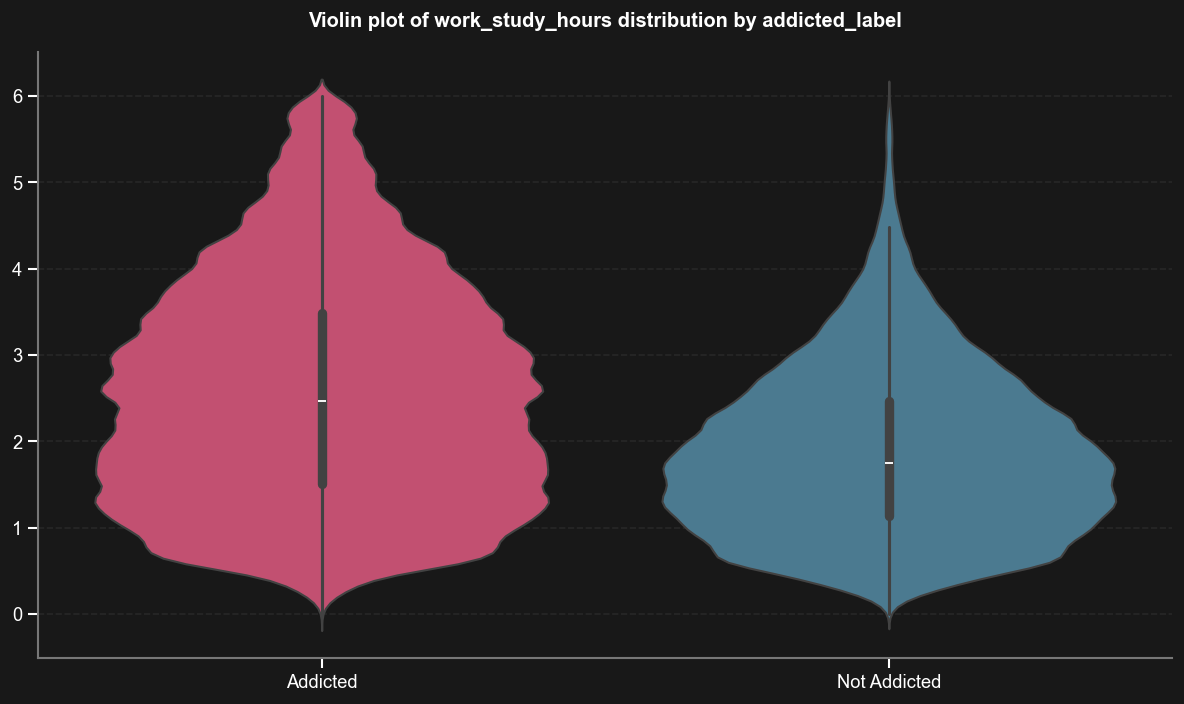

,addicted_label,Count,Mean,Median,Std
0,Addicted,458743,6.837970,6.840000,1.230772
1,Not Addicted,188146,6.722322,6.720000,1.239769


2026-08-10 22:19:48 | INFO     | Checking normality of feature 'sleep_hours' by groups of 'addicted_label'...
2026-08-10 22:19:48 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-08-10 22:19:48 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:48 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-08-10 22:19:48 | DEBUG    | [addicted_label=0] skew=0.0522, kurtosis=-1.1269 → Approximately symmetric, Normal tails
2026-08-10 22:19:48 | DEBUG    | [addicted_label=1] skew=-0.0299, kurtosis=-1.1257 → Approximately symmetric, Normal tails
2026-08-10 22:19:48 | INFO     | Generating Q–Q plots for visual assessment...


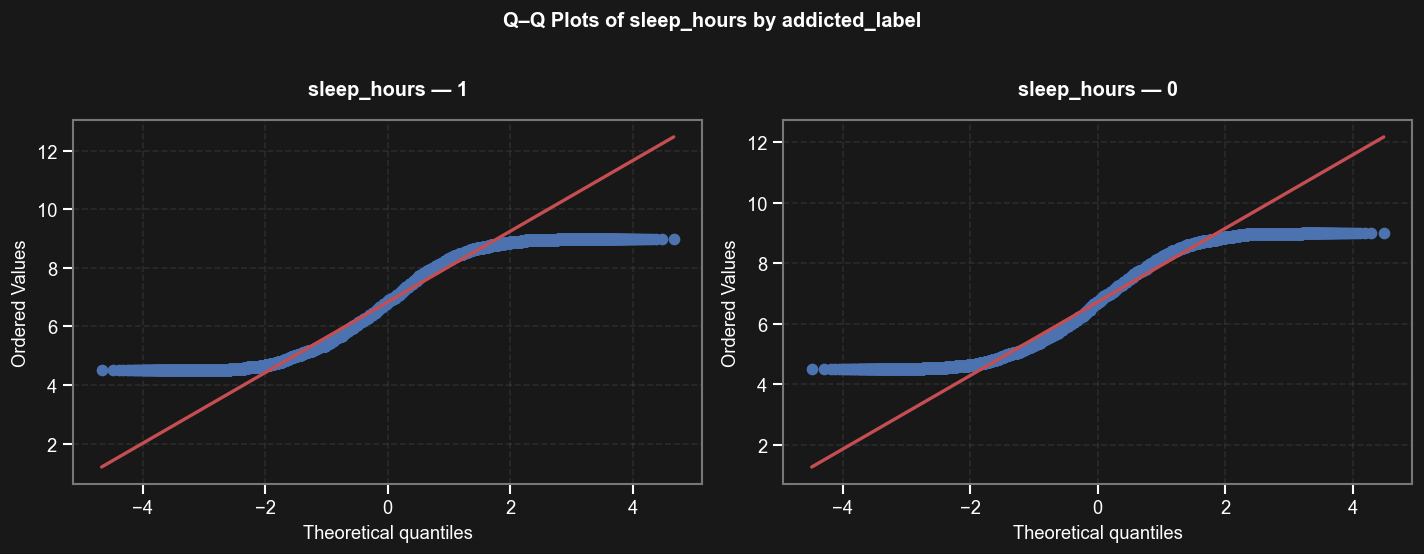

,Feature,Group,Skewness,Kurtosis,Remark
0,sleep_hours,0,0.0522,-1.1269,"Approximately symmetric, Normal tails"
1,sleep_hours,1,-0.0299,-1.1257,"Approximately symmetric, Normal tails"


2026-08-10 22:19:50 | INFO     | All groups approximately follow a normal distribution.
2026-08-10 22:19:50 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-08-10 22:19:50 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,35.6709
1,p-value,0.000000
2,Max/Min Variance Ratio,1.01


2026-08-10 22:19:50 | INFO     | Interpretation:
2026-08-10 22:19:50 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-08-10 22:19:50 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-08-10 22:19:50 | INFO     | Running Independent Two-Sample T-Test: 'sleep_hours' ~ 'addicted_label'
2026-08-10 22:19:50 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:50 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-08-10 22:19:50 | INFO     | Comparing groups: '1' vs '0'
2026-08-10 22:19:50 | INFO     | p-value: 0.000000
2026-08-10 22:19:50 | INFO     | Cohen's d: 0.094
2026-08-10 22:19:50 | DEBUG    | t-statistic: 34.145
2026-08-10 22:19:50 | DEBUG    | Group means → 1: 6.838, 0: 6.722
2026-08-10 22:19:50 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-08-10 22:19:50 | INFO     | Conclusion: Significant difference between the two groups.
2026-08-10 22:1

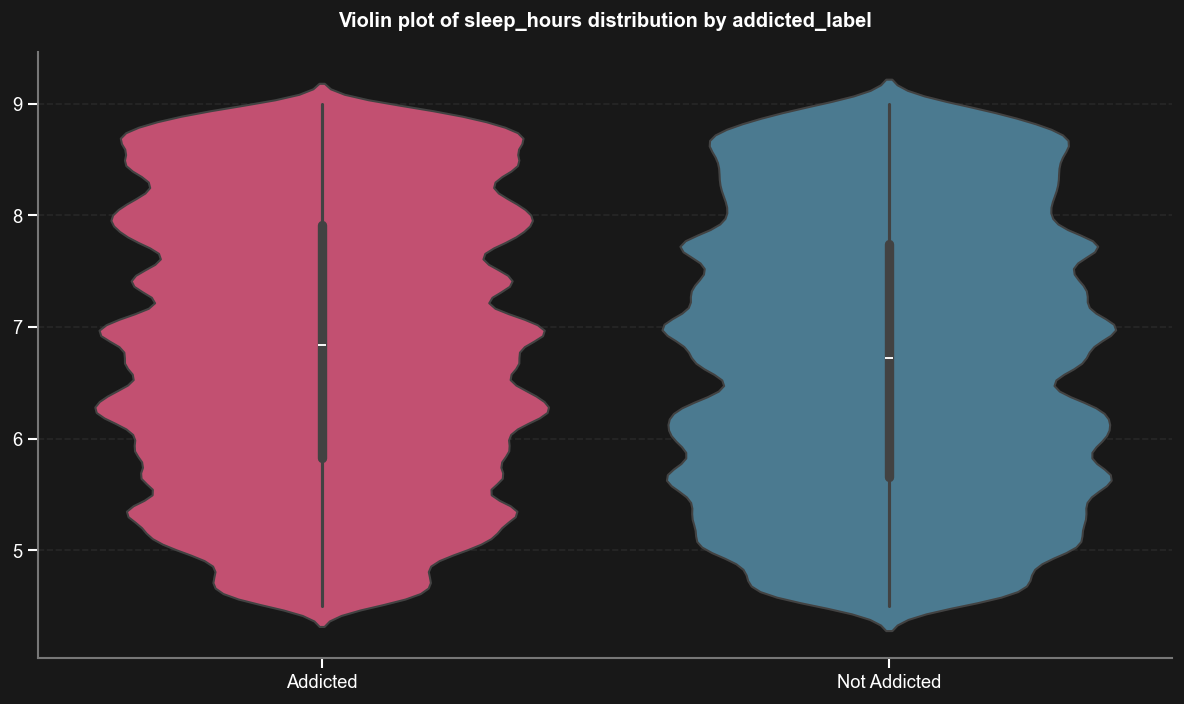

,addicted_label,Count,Mean,Median,Std
0,Not Addicted,181312,147.087662,154.000000,65.979988
1,Addicted,442473,145.406143,150.000000,65.885796


2026-08-10 22:19:54 | INFO     | Checking normality of feature 'notifications_per_day' by groups of 'addicted_label'...
2026-08-10 22:19:54 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-08-10 22:19:54 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:54 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-08-10 22:19:54 | DEBUG    | [addicted_label=0] skew=-0.2275, kurtosis=-1.1291 → Approximately symmetric, Normal tails
2026-08-10 22:19:54 | DEBUG    | [addicted_label=1] skew=-0.1980, kurtosis=-1.1297 → Approximately symmetric, Normal tails
2026-08-10 22:19:54 | INFO     | Generating Q–Q plots for visual assessment...


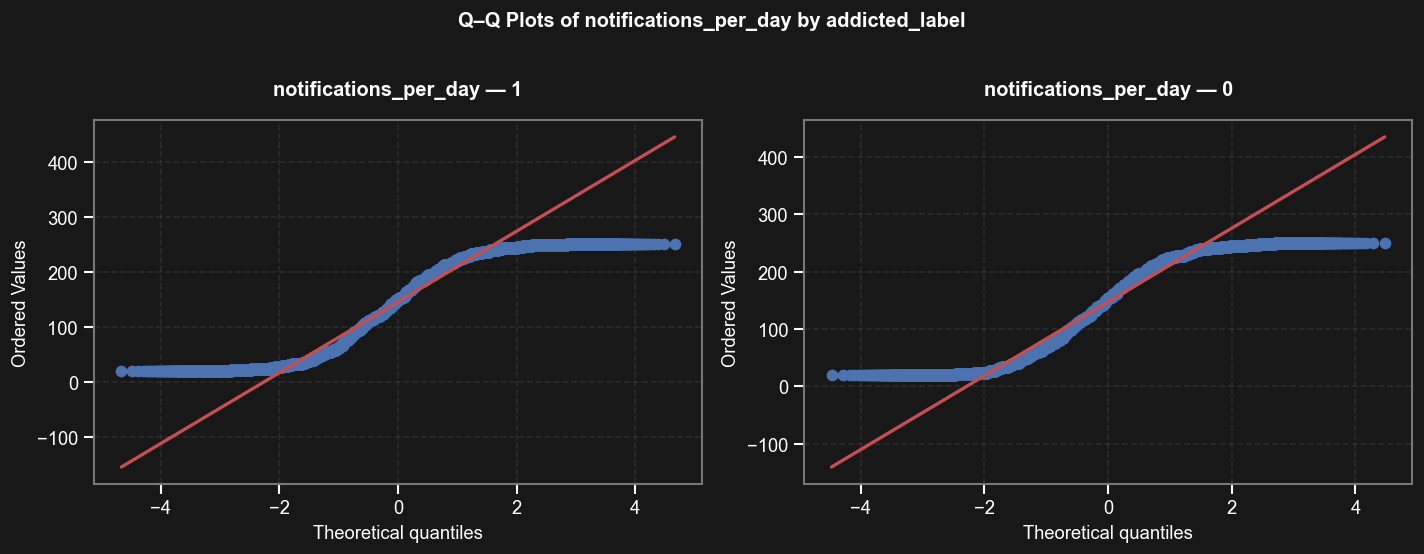

,Feature,Group,Skewness,Kurtosis,Remark
0,notifications_per_day,0,-0.2275,-1.1291,"Approximately symmetric, Normal tails"
1,notifications_per_day,1,-0.1980,-1.1297,"Approximately symmetric, Normal tails"


2026-08-10 22:19:56 | INFO     | All groups approximately follow a normal distribution.
2026-08-10 22:19:56 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-08-10 22:19:56 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,4.1896
1,p-value,0.040674
2,Max/Min Variance Ratio,1.00


2026-08-10 22:19:56 | INFO     | Interpretation:
2026-08-10 22:19:56 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-08-10 22:19:56 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-08-10 22:19:56 | INFO     | Running Independent Two-Sample T-Test: 'notifications_per_day' ~ 'addicted_label'
2026-08-10 22:19:56 | DEBUG    | Number of groups detected: 2
2026-08-10 22:19:56 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-08-10 22:19:56 | INFO     | Comparing groups: '1' vs '0'
2026-08-10 22:19:56 | INFO     | p-value: 0.000000
2026-08-10 22:19:56 | INFO     | Cohen's d: -0.026
2026-08-10 22:19:56 | DEBUG    | t-statistic: -9.144
2026-08-10 22:19:56 | DEBUG    | Group means → 1: 145.406, 0: 147.088
2026-08-10 22:19:56 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-08-10 22:19:56 | INFO     | Conclusion: Significant difference between the two groups.


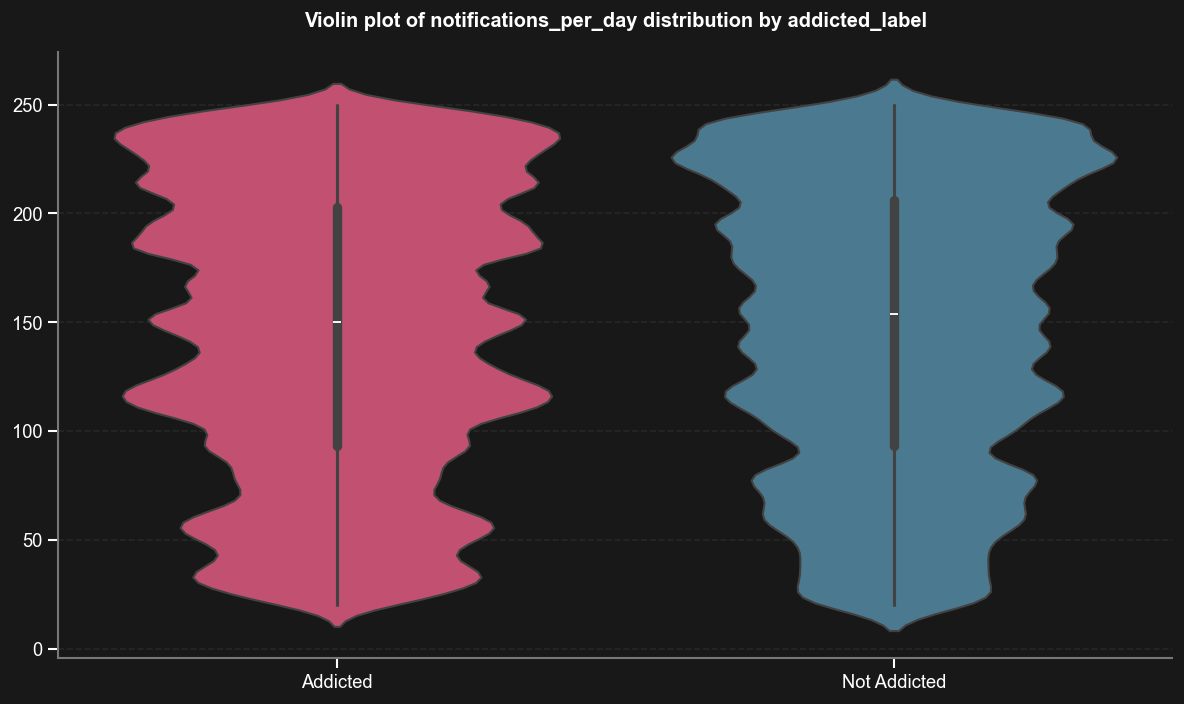

,addicted_label,Count,Mean,Median,Std
0,Addicted,432945,104.592842,109.000000,48.246056
1,Not Addicted,177714,97.871437,99.000000,47.384792


2026-08-10 22:20:00 | INFO     | Checking normality of feature 'app_opens_per_day' by groups of 'addicted_label'...
2026-08-10 22:20:00 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-08-10 22:20:00 | DEBUG    | Number of groups detected: 2
2026-08-10 22:20:00 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-08-10 22:20:00 | DEBUG    | [addicted_label=0] skew=-0.0392, kurtosis=-1.1098 → Approximately symmetric, Normal tails
2026-08-10 22:20:00 | DEBUG    | [addicted_label=1] skew=-0.1654, kurtosis=-1.1806 → Approximately symmetric, Normal tails
2026-08-10 22:20:00 | INFO     | Generating Q–Q plots for visual assessment...


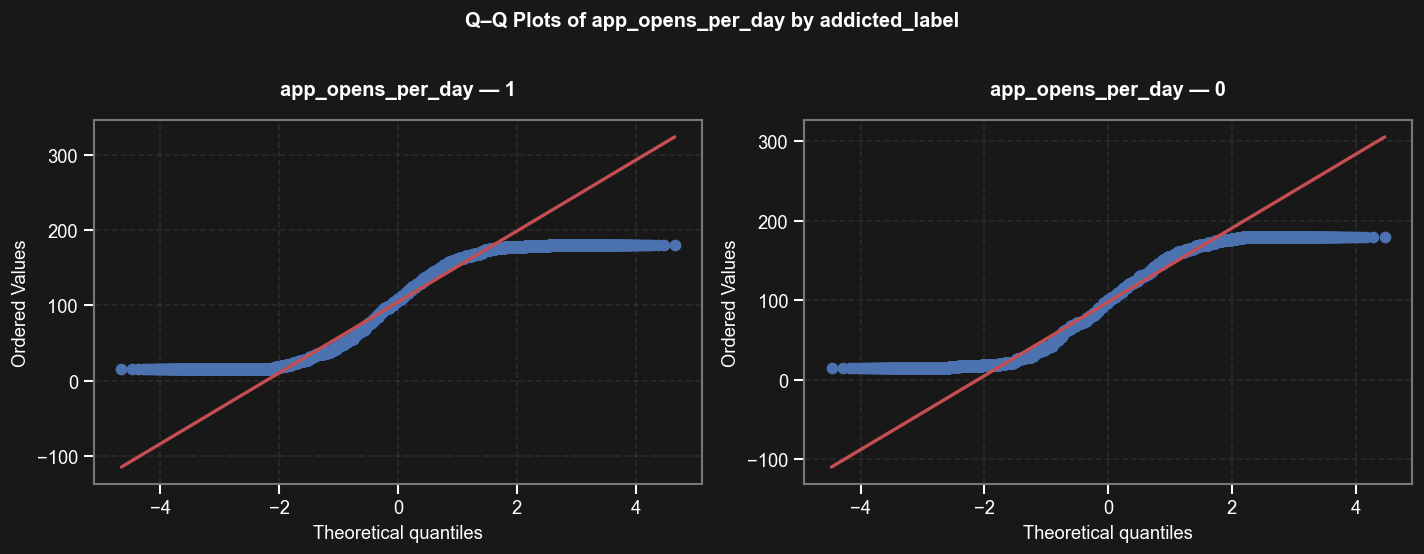

,Feature,Group,Skewness,Kurtosis,Remark
0,app_opens_per_day,0,-0.0392,-1.1098,"Approximately symmetric, Normal tails"
1,app_opens_per_day,1,-0.1654,-1.1806,"Approximately symmetric, Normal tails"


2026-08-10 22:20:02 | INFO     | All groups approximately follow a normal distribution.
2026-08-10 22:20:02 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-08-10 22:20:02 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,214.5789
1,p-value,0.000000
2,Max/Min Variance Ratio,1.04


2026-08-10 22:20:02 | INFO     | Interpretation:
2026-08-10 22:20:02 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-08-10 22:20:02 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-08-10 22:20:02 | INFO     | Running Independent Two-Sample T-Test: 'app_opens_per_day' ~ 'addicted_label'
2026-08-10 22:20:02 | DEBUG    | Number of groups detected: 2
2026-08-10 22:20:02 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-08-10 22:20:02 | INFO     | Comparing groups: '1' vs '0'
2026-08-10 22:20:02 | INFO     | p-value: 0.000000
2026-08-10 22:20:02 | INFO     | Cohen's d: 0.141
2026-08-10 22:20:02 | DEBUG    | t-statistic: 50.083
2026-08-10 22:20:02 | DEBUG    | Group means → 1: 104.593, 0: 97.871
2026-08-10 22:20:02 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-08-10 22:20:02 | INFO     | Conclusion: Significant difference between the two groups.
2026-0

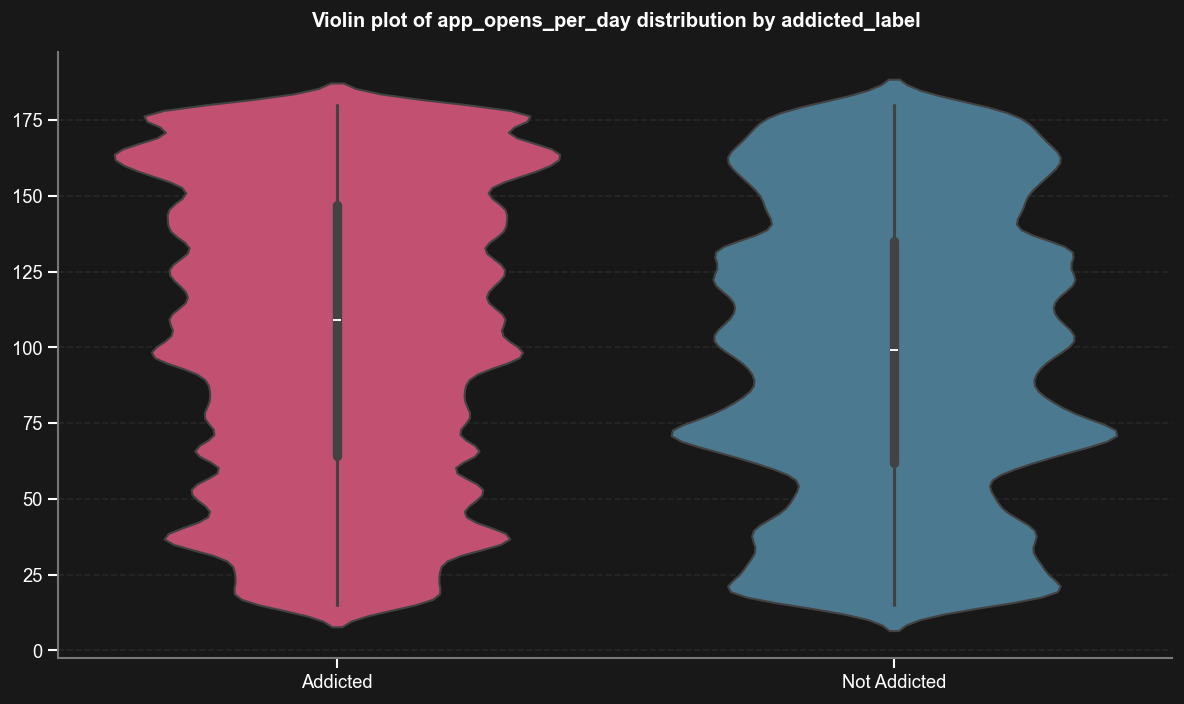

,addicted_label,Count,Mean,Median,Std
0,Addicted,410836,10.558729,10.790000,2.496676
1,Not Addicted,168470,6.848920,6.820000,1.756948


2026-08-10 22:20:06 | INFO     | Checking normality of feature 'weekend_screen_time' by groups of 'addicted_label'...
2026-08-10 22:20:06 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-08-10 22:20:06 | DEBUG    | Number of groups detected: 2
2026-08-10 22:20:06 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-08-10 22:20:06 | DEBUG    | [addicted_label=0] skew=0.1094, kurtosis=-0.2694 → Approximately symmetric, Normal tails
2026-08-10 22:20:06 | DEBUG    | [addicted_label=1] skew=-0.4047, kurtosis=-0.1069 → Approximately symmetric, Normal tails
2026-08-10 22:20:06 | INFO     | Generating Q–Q plots for visual assessment...


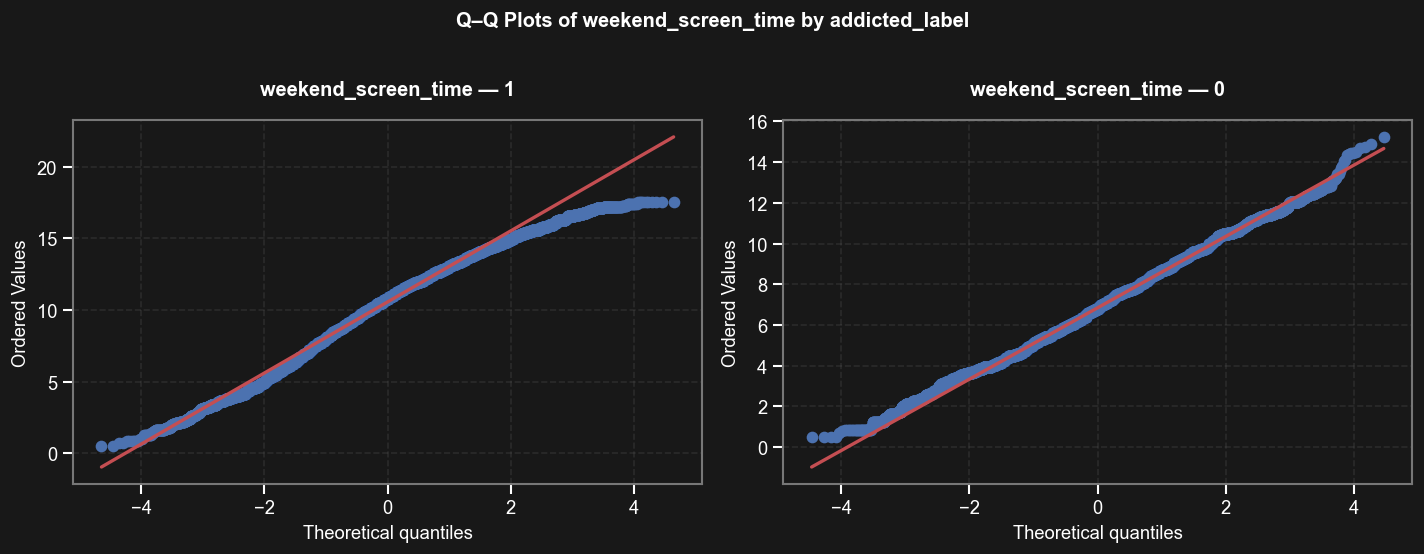

,Feature,Group,Skewness,Kurtosis,Remark
0,weekend_screen_time,0,0.1094,-0.2694,"Approximately symmetric, Normal tails"
1,weekend_screen_time,1,-0.4047,-0.1069,"Approximately symmetric, Normal tails"


2026-08-10 22:20:08 | INFO     | All groups approximately follow a normal distribution.
2026-08-10 22:20:08 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-08-10 22:20:08 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,19839.2168
1,p-value,0.000000
2,Max/Min Variance Ratio,2.02


2026-08-10 22:20:08 | INFO     | Interpretation:
2026-08-10 22:20:08 | INFO     | - Status: Strong variance heterogeneity detected.
2026-08-10 22:20:08 | INFO     | - Recommendation: Use Kruskal–Wallis or Mann–Whitney U test.
2026-08-10 22:20:08 | INFO     | Running Mann–Whitney U Test: 'weekend_screen_time' by 'addicted_label'...
2026-08-10 22:20:08 | DEBUG    | Number of groups detected: 2
2026-08-10 22:20:08 | INFO     | U statistic: 60976316416.0
2026-08-10 22:20:08 | INFO     | p-value    : 0.000000
2026-08-10 22:20:08 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-08-10 22:20:08 | INFO     | Conclusion: Significant difference between the two groups.
2026-08-10 22:20:08 | INFO     | Effect size interpretation: Large


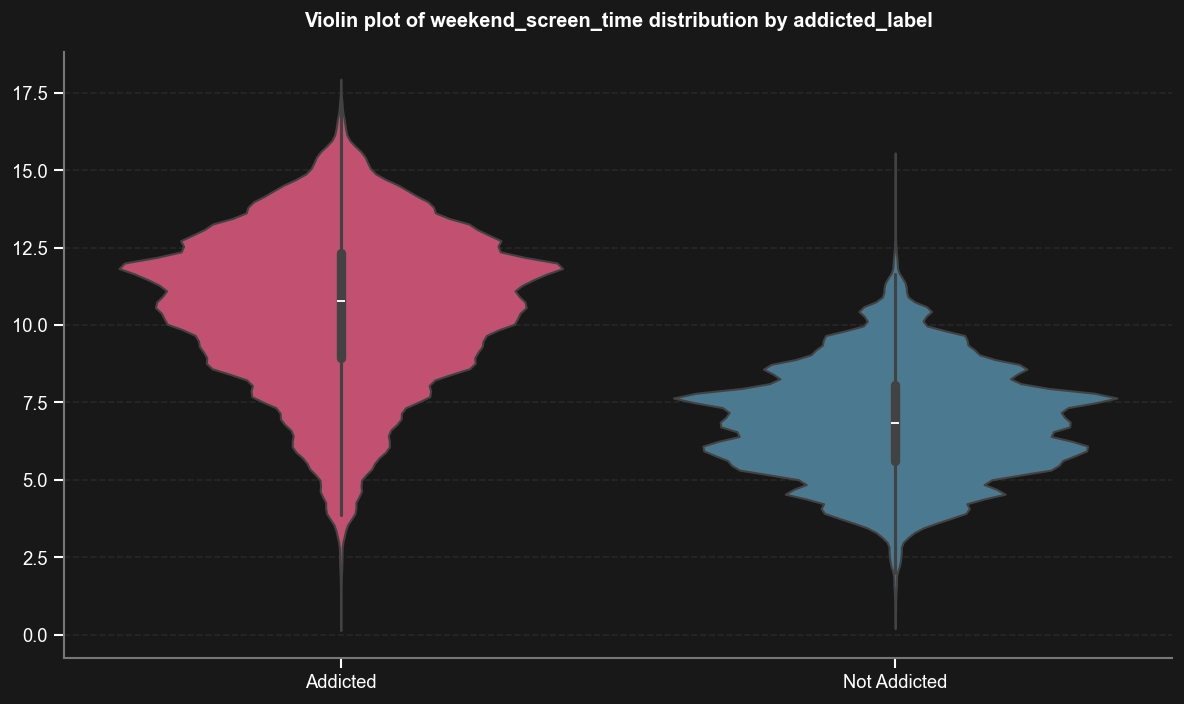

In [85]:
def perform_statical_testing(feature: str, df: pd.DataFrame = df_train,  target_feature: str = CFG.TARGET_FEATURE) -> None:
    """
    Automatically select and perform appropriate statistical tests
    for comparing a numerical feature across categorical groups.

    This function implements a decision-based statistical testing pipeline
    that selects parametric or non-parametric tests based on:

    - Distribution normality (via skewness, kurtosis, and Q–Q plots)
    - Homogeneity of variances
    - Number of categorical groups

    The procedure follows standard statistical analysis guidelines:

    1. Check normality of the numerical feature within each group.
    2. Determine the number of comparison groups.
    3. Evaluate homogeneity of variance when parametric tests are applicable.
    4. Select and execute the most appropriate hypothesis test.

    Decision Logic
    --------------
    For more than two groups:

    - Non-normal distribution → Kruskal–Wallis test
    - Normal + equal variances → One-way ANOVA + Tukey HSD
    - Normal + unequal variances → Welch’s ANOVA
    - Otherwise → Kruskal–Wallis test

    For two groups:

    - Non-normal distribution → Mann–Whitney U test
    - Normal + equal variances → Independent t-test (with Cohen’s d)
    - Normal + unequal variances → Welch’s t-test (with Cohen’s d)
    - Otherwise → Mann–Whitney U test

    The function also reports effect sizes and post-hoc comparisons
    where applicable.

    Parameters
    ----------
    feature : str
        Name of the numerical feature to be analyzed.

    df : pandas.DataFrame, default=df_train
        Dataset containing the numerical feature and categorical target.

    target_feature : str, default=config.target_feature
        Categorical variable defining comparison groups.

    Returns
    -------
    None
        Executes statistical tests and logs/prints results.
        No value is returned.

    Notes
    -----
    - This function is designed for exploratory and confirmatory
      statistical analysis in machine learning and research workflows.
    - Assumption checks (normality and homoscedasticity) are performed
      automatically prior to testing.
    - For small sample sizes, non-parametric tests are generally preferred.

    Examples
    --------
    >>> perform_statical_testing(
    ...     feature="cholesterol",
    ...     df=df_train,
    ...     target_feature="heart_disease"
    ... )
    """

    # Step 1: Check normality of the feature in each group
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    # Count number of categories in target feature
    total_categories = df[target_feature].nunique()
    # Case 1: More than two groups (Multi-class comparison)
    if total_categories > 2:
        # If data is not normally distributed → use Kruskal–Wallis
        if non_normal_detected:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        # If data is approximately normal → check variance homogeneity
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            # Normal + equal variance → One-way ANOVA + Tukey test
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            # Normal + unequal variance → Welch ANOVA
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            # Otherwise → fallback to Kruskal–Wallis
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    # Case 2: Two groups (Binary comparison)
    else:
        # If data is not normal → use Mann–Whitney U test
        if non_normal_detected:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        # If data is approximately normal → check variance homogeneity
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            # Normal + equal variance → Independent t-test + Cohen's d
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            # Normal + unequal variance → Welch t-test + Cohen's d
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            # Otherwise → fallback to Mann–Whitney U
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def analyze_numeric_feature_by_target(feature: str, df: pd.DataFrame = df_train,
                                      target_feature: str = CFG.TARGET_FEATURE, order: list = None) -> None:
    """
    Analyze and visualize the distribution of a numerical feature
    across categories of a target variable.

    This function performs:
    - Descriptive statistics (mean, median, std) by group
    - Overall summary statistics
    - Automated statistical hypothesis testing
    - Violin plot visualization

    Parameters
    ----------
    feature : str
        Numerical feature to be analyzed.

    df : pandas.DataFrame
        Input dataset containing the feature and target variable.

    target_feature : str
        Categorical variable used for grouping.

    order : list, optional
        Custom order of categories for plotting.

    Returns
    -------
    None
        Displays summary tables, test results, and plots.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False).reset_index(drop=True)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(10, 6), facecolor="#181818")
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique()))
    
    plt.title(f"Violin plot of {feature} distribution by {target_feature}", pad=15, weight="bold", fontsize=12)
    plt.xlabel("")
    plt.ylabel("")
    plt.legend().remove()
    plt.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

mapping = {0: "Not Addicted", 1: "Addicted"}
df_plot = df_train.copy()
df_plot[CFG.TARGET_FEATURE] = df_plot[CFG.TARGET_FEATURE].map(mapping)

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature} by Addicted Label</b></h2>"))
    analyze_numeric_feature_by_target(feature=feature, df = df_plot)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Numerical Feature Insights by Addicted Label
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><b><code>age</code></b>: Age distributions are nearly identical between the two groups. Despite statistical significance (<code>p &lt; 0.05</code>), the practical effect is negligible (<code>Cohen's d = 0.009</code>), suggesting that age is a weak predictor of smartphone addiction.</li>

<li><b><code>daily_screen_time_hours</code></b>: Daily screen time differs markedly between the two groups (<code>p &lt; 0.001</code>), with addicted users averaging nearly <b>9 hours/day</b> versus <b>5 hours/day</b> for non-addicted users. This feature shows a large practical effect and is one of the strongest predictors of smartphone addiction.</li>

<li><b><code>social_media_hours</code></b>: Social media usage is substantially higher among addicted users (<code>p &lt; 0.001</code>), with a large effect size, making it one of the strongest behavioral predictors of smartphone addiction.</li>

<li><b><code>gaming_hours</code></b>: Although addicted users spend more time gaming (<code>p &lt; 0.001</code>), the small effect size indicates that gaming hours are a weaker indicator than overall screen time or social media usage.</li>

<li><b><code>work_study_hours</code></b>: Work/study screen time is significantly higher among addicted users (<code>p &lt; 0.001</code>), although the small effect size suggests only a modest contribution to smartphone addiction.</li>

<li><b><code>sleep_hours</code></b>: Sleep duration shows a statistically significant difference (<code>p &lt; 0.001</code>), but the small effect size indicates that it is a relatively weak predictor of smartphone addiction.</li>

<li><b><code>notifications_per_day</code></b>: Notifications per day differ significantly between the two groups (<code>p &lt; 0.001</code>), but the negligible effect size suggests they provide little practical value for distinguishing smartphone addiction.</li>

<li><b><code>app_opens_per_day</code></b>: App opening frequency is significantly higher among addicted users (<code>p &lt; 0.001</code>), but the small effect size indicates only a modest contribution to distinguishing smartphone addiction.</li>

<li><b><code>weekend_screen_time</code></b>: Addicted users spend considerably more time on their smartphones during weekends (<code>p &lt; 0.001</code>), with a large effect size, making weekend screen time one of the strongest predictors of smartphone addiction.</li>

</ul>

</div>

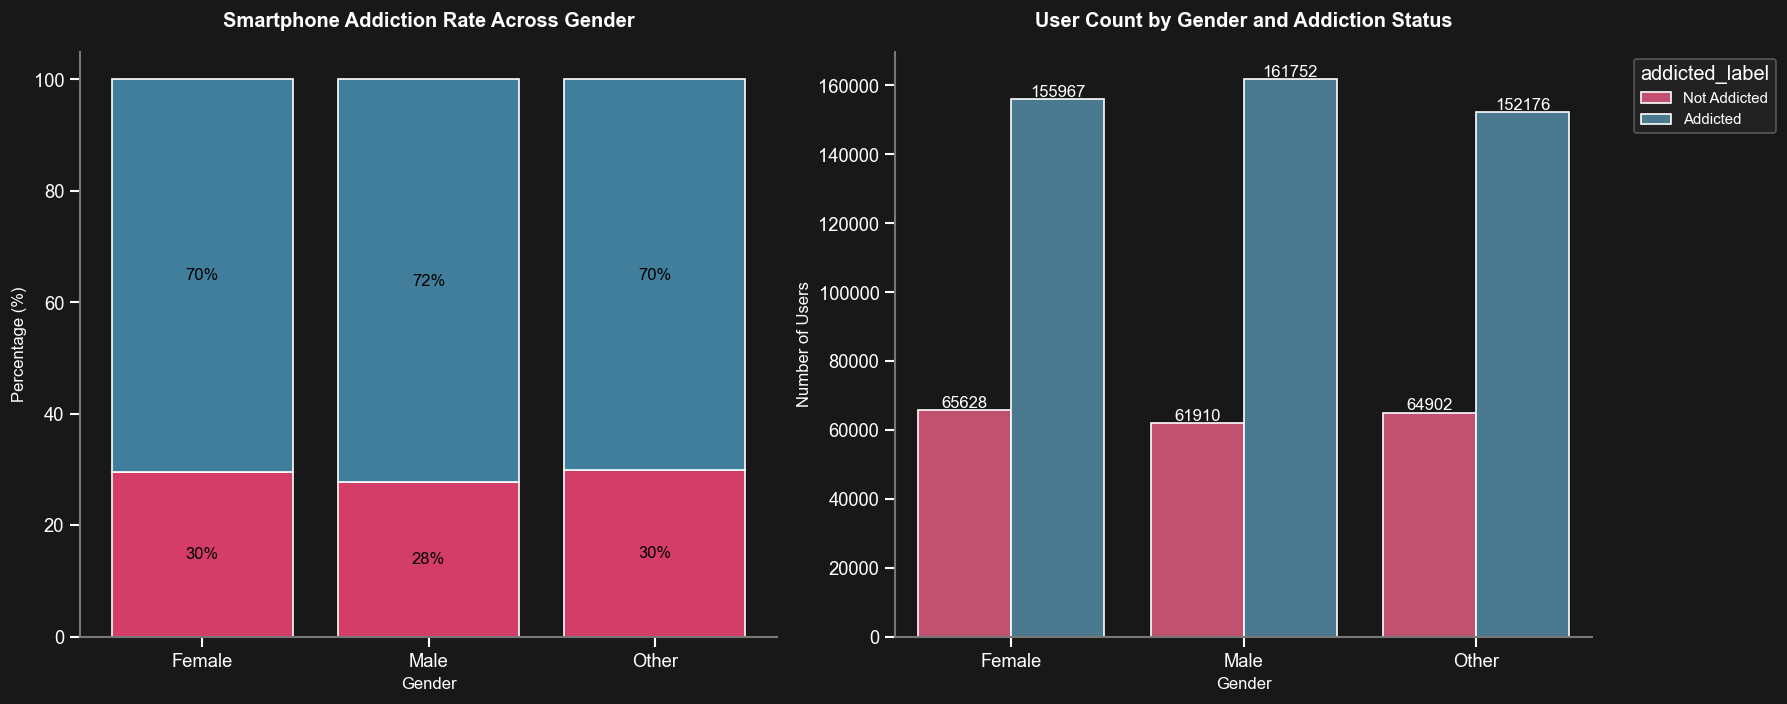

2026-08-10 22:20:13 | INFO     | Chi-Square Test of Independence: 'gender' vs. 'addicted_label'...
2026-08-10 22:20:13 | INFO     | Chi-squared statistic: 313.793
2026-08-10 22:20:13 | INFO     | Degrees of freedom: 2
2026-08-10 22:20:13 | INFO     | p-value: 0.000000
2026-08-10 22:20:13 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-08-10 22:20:13 | INFO     | Variables 'gender' and 'addicted_label' are statistically associated.
2026-08-10 22:20:13 | DEBUG    | Displaying standardized residuals heatmap.


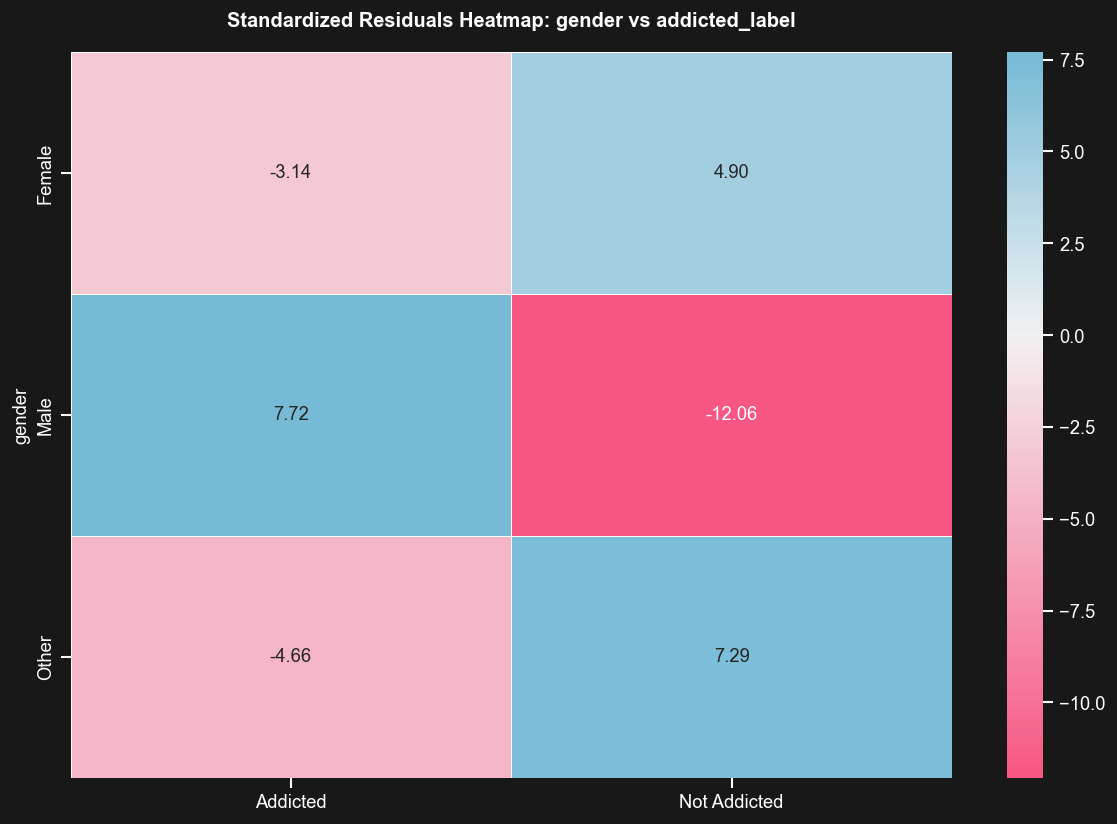

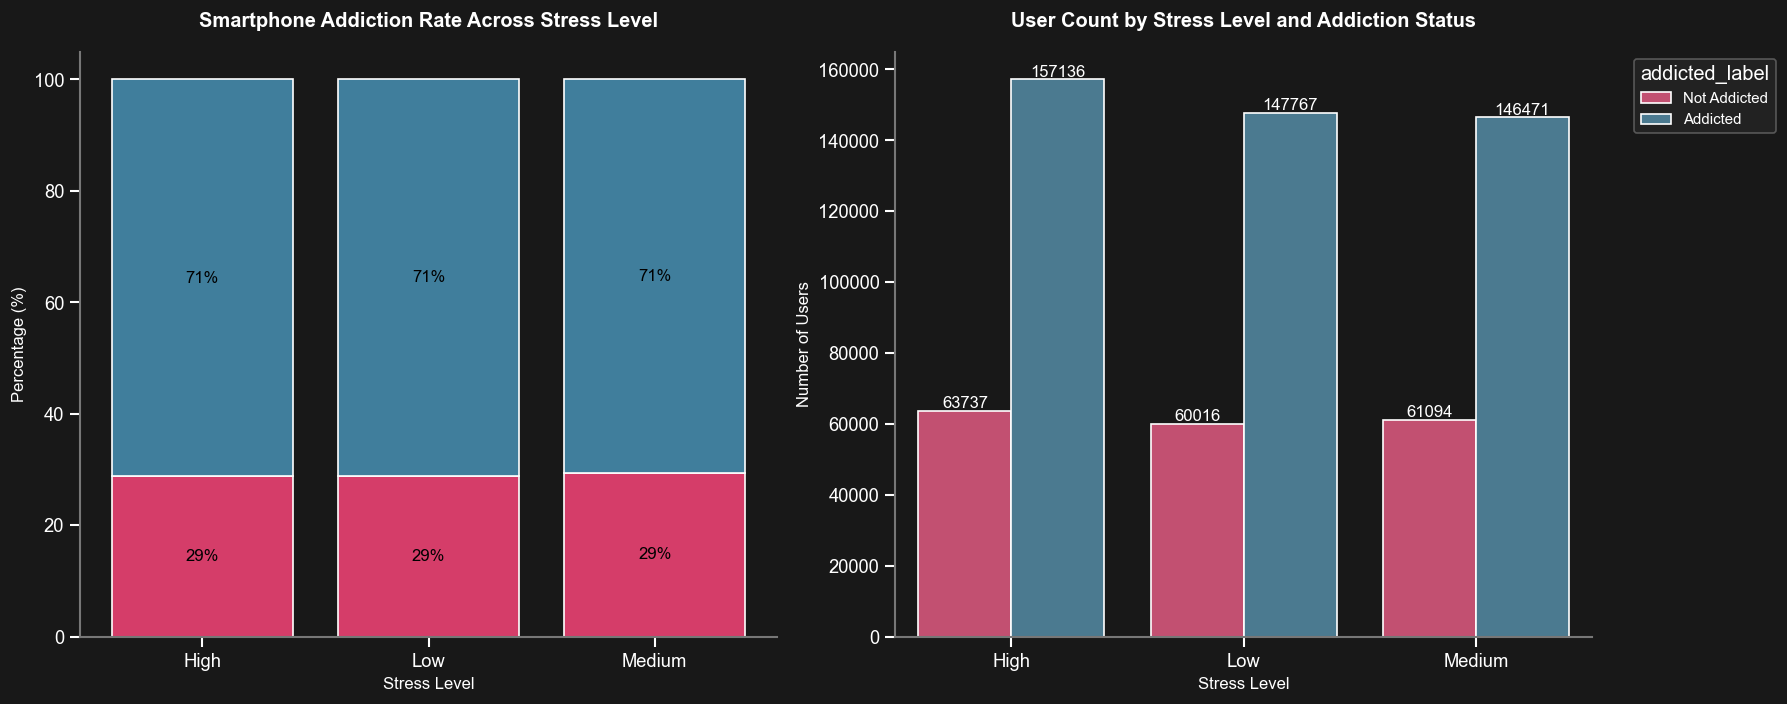

2026-08-10 22:20:15 | INFO     | Chi-Square Test of Independence: 'stress_level' vs. 'addicted_label'...
2026-08-10 22:20:15 | INFO     | Chi-squared statistic: 21.594
2026-08-10 22:20:15 | INFO     | Degrees of freedom: 2
2026-08-10 22:20:15 | INFO     | p-value: 0.000020
2026-08-10 22:20:15 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-08-10 22:20:15 | INFO     | Variables 'stress_level' and 'addicted_label' are statistically associated.
2026-08-10 22:20:15 | DEBUG    | Displaying standardized residuals heatmap.


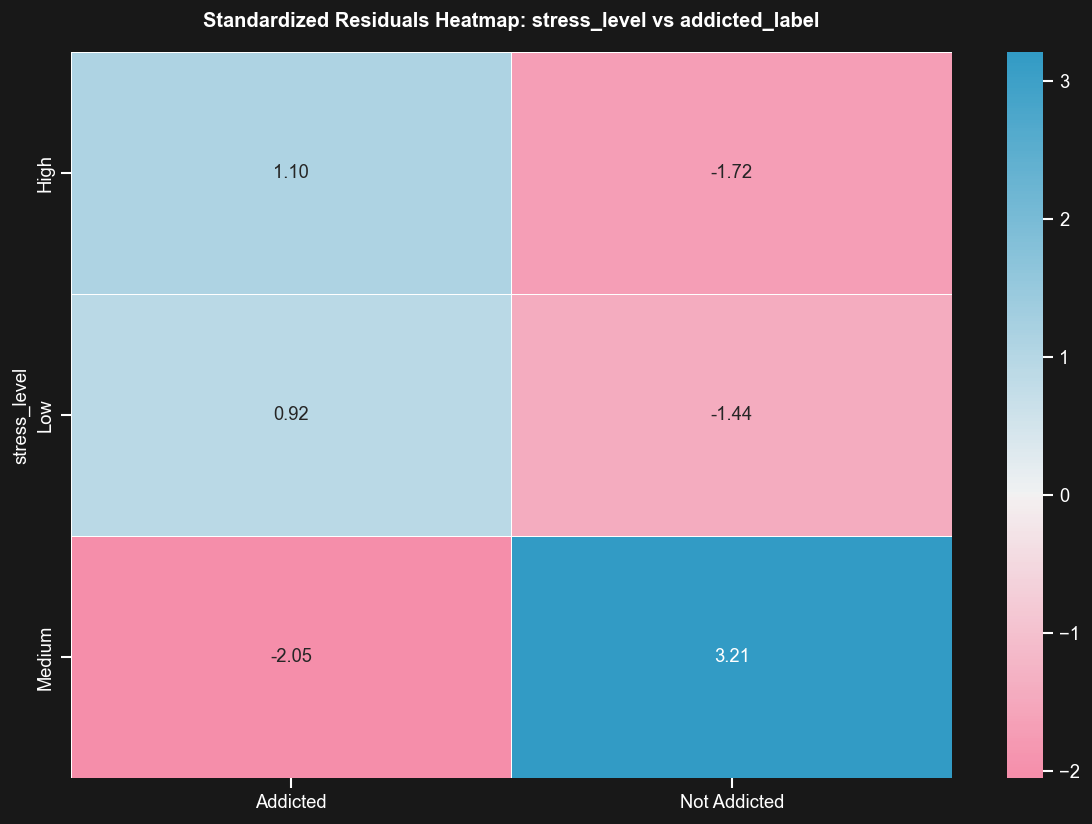

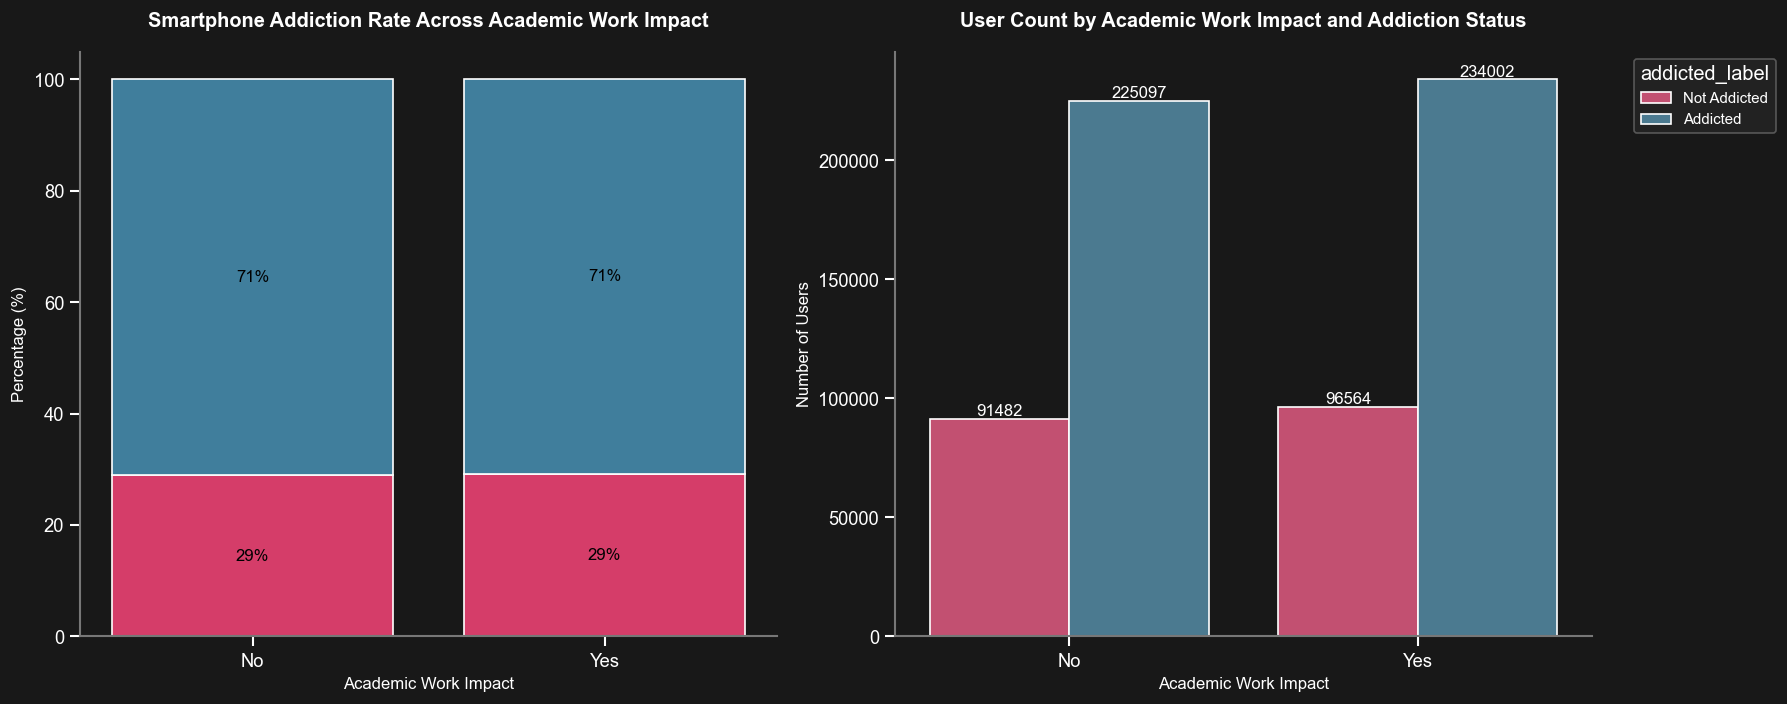

2026-08-10 22:20:16 | INFO     | Chi-Square Test of Independence: 'academic_work_impact' vs. 'addicted_label'...
2026-08-10 22:20:17 | INFO     | Chi-squared statistic: 7.752
2026-08-10 22:20:17 | INFO     | Degrees of freedom: 1
2026-08-10 22:20:17 | INFO     | p-value: 0.005366
2026-08-10 22:20:17 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-08-10 22:20:17 | INFO     | Variables 'academic_work_impact' and 'addicted_label' are statistically associated.
2026-08-10 22:20:17 | DEBUG    | Displaying standardized residuals heatmap.


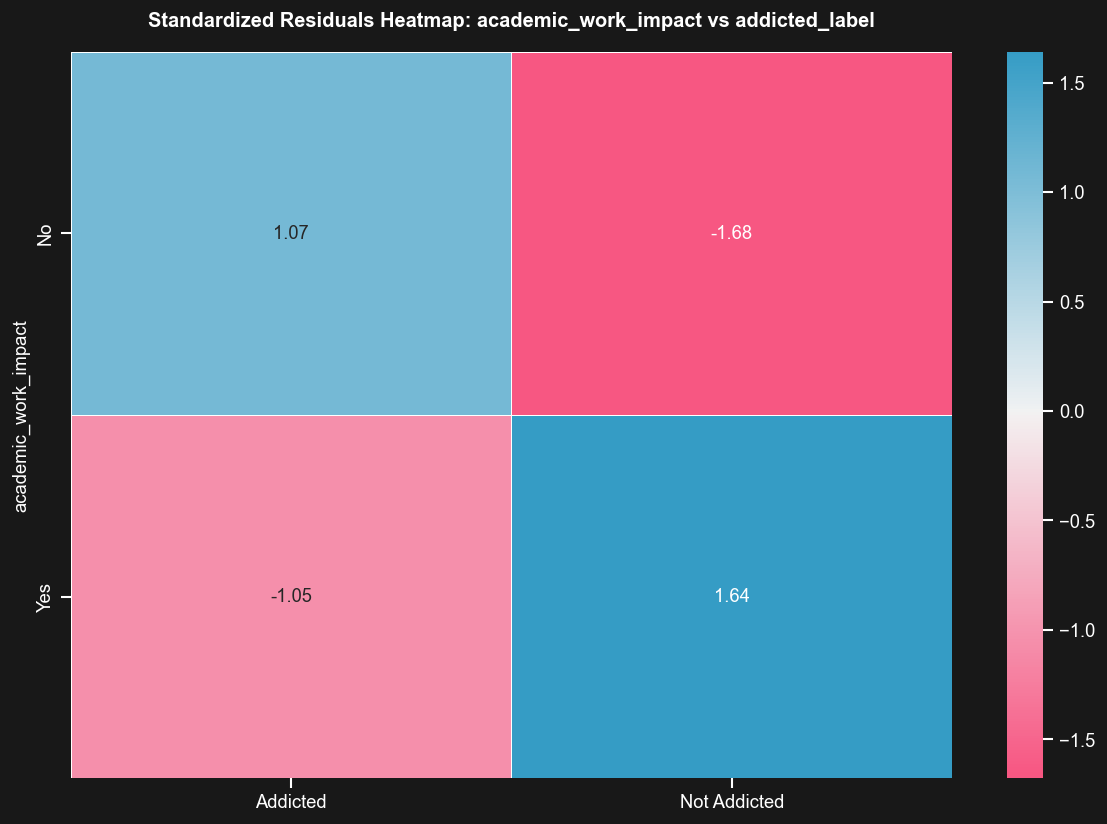

In [86]:
def analyze_categorical_feature_vs_target(cat: str, target_feature: str,
                                          df: pd.DataFrame, figsize=(15, 6), order=None) -> None:
    """
    Plot the relationship between a categorical feature and the target variable.

    This function displays:
    - A stacked bar chart showing percentage distribution of target classes.
    - A count plot showing absolute frequencies.
    - A Chi-Square test for feature–target dependence.

    Parameters
    ----------
    cat : str
        Categorical feature name.

    target_feature : str
        Target variable name.

    df : pd.DataFrame
        Input dataset.

    figsize : tuple, optional
        Figure size (width, height). Default is (15, 6).

    order : list, optional
        Custom order of categories on x-axis.

    Returns
    -------
    None
    """

    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {cat.replace('_', ' ').title()} by Smartphone Addiction Status</b></h2>"))
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=figsize, facecolor="#181818")

    # Data processing
    grouped = df.groupby([cat, target_feature]).size().unstack(fill_value=0)

    # Define a fixed hue order (adjust if needed)
    target_order = ["Not Addicted", "Addicted"]
    target_order = [c for c in target_order if c in grouped.columns]

    # Fallback if the labels are 0/1 or have different names
    if not target_order:
        target_order = list(grouped.columns)

    # Calculate percentages row-wise and reorder columns by target_order
    percentages = grouped.div(grouped.sum(axis=1), axis=0)[target_order] * 100

    # Define X-axis category order
    if order is not None:
        percentages = percentages.loc[order]
        labels = order
    else:
        labels = percentages.index.tolist()

    # Consistent color palette for both charts
    base_colors = color(n_colors=len(target_order))
    color_map = dict(zip(target_order, base_colors))

    # Plot 1: Stacked bar chart (percentage)
    bottom = np.zeros(len(percentages))
    for cls in target_order:
        ax[0].bar(percentages.index.astype(str), percentages[cls].values, bottom=bottom,
                  label=cls, color=color_map[cls])
        bottom += percentages[cls].values

    # Add percentage labels
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt="%1.0f%%", label_type="center",
                        fontsize=10, color="black")

    ax[0].set_title(f"Smartphone Addiction Rate Across {cat.replace('_', ' ').title()}", fontsize=12, weight="bold", pad=15)
    ax[0].set_xlabel(cat.replace("_", " ").title(), fontsize=10)
    ax[0].set_ylabel("Percentage (%)", fontsize=10)
    ax[0].grid(False)
    sns.despine(left=False, bottom=False, ax=ax[0])
    ax[0].legend().remove()

    # Plot 2: Count plot (using same color_map + hue_order)
    sns.countplot(data=df, hue=target_feature, x=cat,
                  order=labels, hue_order=target_order,
                  palette=color_map, ax=ax[1])

    for container in ax[1].containers:
        ax[1].bar_label(container, fmt="%d", label_type="edge",
                        fontsize=10, color="white")

    ax[1].set_title(f"User Count by {cat.replace('_', ' ').title()} and Addiction Status", fontsize=12, weight="bold", pad=15)
    ax[1].set_xlabel(cat.replace("_", " ").title(), fontsize=10)
    ax[1].set_ylabel("Number of Users", fontsize=10)
    ax[1].legend(title=target_feature, bbox_to_anchor=(1.05, 1), loc="upper left")
    ax[1].grid(False)
    sns.despine(left=False, bottom=False, ax=ax[1])
    plt.tight_layout()
    plt.show()

    # Chi-Square Test
    cal_ChiSquare(cat_feature=cat, target_feature=target_feature, df=df, show_residuals=True)

# Run for all categorical features
for feature in cat_features:
    analyze_categorical_feature_vs_target(cat=feature, target_feature=CFG.TARGET_FEATURE,
                                          df=df_plot)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Categorical Feature Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><code>Gender</code> has a <b>statistically significant but modest association</b> with smartphone addiction, with <b>male users</b> showing the highest addiction rate among the three groups.</li>

<li><code>Stress Level</code> is <b>statistically significant</b>, but addiction rates remain nearly identical across all stress groups, indicating a <b>weak practical relationship</b>.</li>

<li><code>Academic Work Impact</code> is also <b>statistically significant</b>; however, the difference in addiction rates between users reporting impact and no impact is <b>minimal</b>, suggesting limited predictive value on its own.</li>

</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Overall Picture</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Overall Picture
    </h1>
</div>


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Overall Picture
</div>

<table style="
    width:100%;
    border-collapse:collapse;
    background-color:rgba(255,255,255,0.04);
    font-size:14px;
">

<tr style="background-color:rgba(249,231,159,0.15);">
    <th style="padding:12px;border:1px solid #5d8a72;text-align:left;">Feature</th>
    <th style="padding:12px;border:1px solid #5d8a72;text-align:left;">Key Insight</th>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;"><b>Age</b></td>
<td style="padding:10px;border:1px solid #5d8a72;">
Age differs statistically but has virtually no practical impact on smartphone addiction.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#ff6b6b;">Daily Screen Time</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
One of the strongest predictors—addicted users spend substantially more screen time each day.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#ff6b6b;">Social Media Hours</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Heavy social media usage strongly distinguishes addicted users from non-addicted users.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#f9e79f;">Gaming Hours</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Gaming time is higher among addicted users but provides only modest predictive value.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#f9e79f;">Work/Study Hours</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Longer work/study screen time is associated with addiction, although the practical effect is small.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;"><b>Sleep Hours</b></td>
<td style="padding:10px;border:1px solid #5d8a72;">
Sleep duration differs slightly between groups but contributes little to predicting addiction.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;"><b>Notifications per Day</b></td>
<td style="padding:10px;border:1px solid #5d8a72;">
Notification frequency has negligible practical influence despite statistical significance.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#f9e79f;">App Opens per Day</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
More frequent app usage is linked to addiction but with only a modest practical effect.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#ff6b6b;">Weekend Screen Time</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Weekend screen time is another strong behavioral indicator, with addicted users spending considerably longer on their phones.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;"><b>Gender</b></td>
<td style="padding:10px;border:1px solid #5d8a72;">
Male users show a slightly higher addiction rate, although the overall gender effect is modest.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;"><b>Stress Level</b></td>
<td style="padding:10px;border:1px solid #5d8a72;">
Stress level is statistically associated with addiction, but differences across groups are minimal.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;"><b>Academic Work Impact</b></td>
<td style="padding:10px;border:1px solid #5d8a72;">
Perceived academic/work impact shows only a weak relationship with smartphone addiction.
</td>
</tr>

</table>

<div style="
    margin-top:18px;
    padding:12px 15px;
    background-color:rgba(0,0,0,0.15);
    border-radius:8px;
    font-size:13px;
">
<span style="color:#ff6b6b;"><b>● Strong relationship</b></span>
&nbsp;&nbsp;|&nbsp;&nbsp;
<span style="color:#f9e79f;"><b>● Moderate relationship</b></span>
&nbsp;&nbsp;|&nbsp;&nbsp;
<span style="color:#ecf0f1;"><b>● Limited practical impact</b></span>
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


## Feature Engineering

In [87]:
logger.info("=" * 80)
logger.info("DATA PREPROCESSING")
logger.info("=" * 80)

# Prepare Base Features
logger.info("Preparing base features...")
BASE = [
    c for c in df_train.columns
    if c not in [CFG.ID_COLUMN, CFG.TARGET_FEATURE]
]

logger.info(
    f"Data loaded | "
    f"Train: {df_train.shape} | "
    f"Test: {df_test.shape} | "
    f"Original: {df_original.shape}"
)

logger.info(f"Base features: {len(BASE)}")
logger.debug(f"Base feature list: {BASE}")

# Combine Train + Original Dataset
logger.info("Combining train and original datasets...")

train_before = len(df_train)

df_train = pd.concat([df_train, df_original], ignore_index=True)
logger.info(
    f"Train dataset combined | "
    f"Rows: {train_before:,} -> {len(df_train):,}"
)

# Feature Engineering
logger.info("Starting feature engineering...")

for df_name, df in [("Train", df_train), ("Test", df_test)]:

    logger.info(f"[{df_name}] Creating engineered features...")

    # Total phone usage
    df["total_usage_hours"] = (
        df["social_media_hours"]
        + df["gaming_hours"]
        + df["work_study_hours"]
    )

    # Entertainment usage
    df["entertainment_hours"] = (
        df["social_media_hours"]
        + df["gaming_hours"]
    )

    # Productivity ratio
    df["study_usage_ratio"] = (
        df["work_study_hours"]
        / (df["daily_screen_time_hours"] + 1e-6)
    )

    # Entertainment ratio
    df["entertainment_ratio"] = (
        (df["social_media_hours"] + df["gaming_hours"])
        / (df["daily_screen_time_hours"] + 1e-6)
    )

    # Weekend increment
    df["weekend_usage_diff"] = (
        df["weekend_screen_time"]
        - df["daily_screen_time_hours"]
    )

    # Weekend ratio
    df["weekend_ratio"] = (
        df["weekend_screen_time"]
        / (df["daily_screen_time_hours"] + 1e-6)
    )

    # Notifications per screen hour
    df["notification_density"] = (
        df["notifications_per_day"]
        / (df["daily_screen_time_hours"] + 1e-6)
    )

    # App opens per hour
    df["app_open_density"] = (
        df["app_opens_per_day"]
        / (df["daily_screen_time_hours"] + 1e-6)
    )

    # Opens per notification
    df["opens_per_notification"] = (
        df["app_opens_per_day"]
        / (df["notifications_per_day"] + 1)
    )

    # Sleep deficit
    df["sleep_deficit"] = 8 - df["sleep_hours"]

    # Screen time × sleep
    df["screen_sleep_score"] = (
        df["daily_screen_time_hours"]
        * df["sleep_deficit"]
    )

    # Screen time × age
    df["age_screen_interaction"] = (
        df["age"]
        * df["daily_screen_time_hours"]
    )

    # Weekend × social media
    df["weekend_social"] = (
        df["weekend_screen_time"]
        * df["social_media_hours"]
    )

    # Social × gaming
    df["social_gaming"] = (
        df["social_media_hours"]
        * df["gaming_hours"]
    )

    # Activity score
    df["activity_score"] = (
        df["notifications_per_day"]
        + df["app_opens_per_day"]
    )

    # Overall engagement
    df["engagement_score"] = (
        df["daily_screen_time_hours"]
        * df["app_opens_per_day"]
    )

    logger.info(
        f"[{df_name}] Feature engineering completed | "
        f"Shape: {df.shape}"
    )

# Native Categorical Typing

logger.info("Converting categorical features to native category dtype...")

for col in cat_features:
    if col not in df_train.columns or col not in df_test.columns:
        logger.warning(f"Categorical feature '{col}' not found in both datasets.")
        continue

    train_missing = df_train[col].isna().sum()
    test_missing = df_test[col].isna().sum()

    logger.debug(
        f"{col:<30} | "
        f"Train missing: {train_missing:,} | "
        f"Test missing: {test_missing:,}"
    )
    df_train[col] = df_train[col].fillna("Unknown").astype("category")
    df_test[col] = df_test[col].fillna("Unknown").astype("category")

logger.info("Categorical dtype conversion completed.")

# Missing Value Indicators
logger.info("Creating missing-value indicators...")

missing_features = []

for col in num_features:
    if col not in df_train.columns or col not in df_test.columns:
        logger.warning(
            f"Numerical feature '{col}' "
            f"not found in both datasets."
        )
        continue

    train_missing = df_train[col].isna().sum()
    test_missing = df_test[col].isna().sum()

    if train_missing > 0 or test_missing > 0:
        missing_col = f"{col}_is_missing"
        df_train[missing_col] = df_train[col].isna().astype("int8")
        df_test[missing_col] = df_test[col].isna().astype("int8")
        missing_features.append(missing_col)
        logger.debug(
            f"Missing indicator created | "
            f"{missing_col} | "
            f"Train: {train_missing:,} | "
            f"Test: {test_missing:,}"
        )

logger.info(
    f"Missing-value indicators created: "
    f"{len(missing_features)}"
)

# Final Preprocessing Summary
logger.info("=" * 80)
logger.info("DATA PREPROCESSING COMPLETED")
logger.info("=" * 80)

logger.info(
    f"Final dataset shapes | "
    f"Train: {df_train.shape} | "
    f"Test: {df_test.shape}"
)

logger.info(f"Categorical features processed: {len(cat_features)}")
logger.info(f"Missing-value indicator features: {len(missing_features)}")

2026-08-10 22:20:17 | INFO     | ================================================================================
2026-08-10 22:20:17 | INFO     | DATA PREPROCESSING
2026-08-10 22:20:17 | INFO     | ================================================================================
2026-08-10 22:20:17 | INFO     | Preparing base features...
2026-08-10 22:20:17 | INFO     | Data loaded | Train: (691369, 13) | Test: (296302, 12) | Original: (7500, 13)
2026-08-10 22:20:17 | INFO     | Base features: 12
2026-08-10 22:20:17 | DEBUG    | Base feature list: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']
2026-08-10 22:20:17 | INFO     | Combining train and original datasets...
2026-08-10 22:20:17 | INFO     | Train dataset combined | Rows: 691,369 -> 698,869
2026-08-10 22:20:17 | INFO     | Starting feature engineering.

In [ ]:
# Final Feature List
logger.info("Preparing final feature list...")

new_features = [
    # Usage features
    "total_usage_hours",
    "entertainment_hours",

    # Ratio features
    "study_usage_ratio",
    "entertainment_ratio",
    "weekend_usage_diff",
    "weekend_ratio",
    "notification_density",
    "app_open_density",
    "opens_per_notification",

    # Lifestyle features
    "sleep_deficit",
    "screen_sleep_score",

    # Interaction features
    "age_screen_interaction",
    "weekend_social",
    "social_gaming",

    # Composite behavioral features
    "activity_score",
    "engagement_score",
]

# Add missing indicators for original numerical features
new_features.extend(missing_features)

FEATURES = BASE + new_features

logger.info(
    f"Feature composition | "
    f"Base: {len(BASE)} | "
    f"Engineered: {len(new_features) - len(missing_features)} | "
    f"Missing Indicators: {len(missing_features)} | "
    f"Total: {len(FEATURES)}"
)

logger.debug(f"Final feature list: {FEATURES}")

# Reduce Memory Usage
logger.info("Reducing memory usage...")

df_train = CFG.reduce_mem_usage(cols=FEATURES, df=df_train)
df_test = CFG.reduce_mem_usage(cols=FEATURES, df=df_test)

logger.info(
    f"Memory optimization completed | "
    f"Train: {df_train.shape} | "
    f"Test: {df_test.shape}"
)

# Final Categorical Conversion
# Only original categorical features are converted.
# Missing indicators remain numerical binary features (0/1).

logger.info("Applying categorical conversion to original categorical features...")

df_train = CFG.convert_cat(features=missing_features, df=df_train)
df_test = CFG.convert_cat(features=missing_features,  df=df_test)

logger.info("Categorical conversion completed.")

# Final Preprocessing Summary
logger.info("=" * 80)
logger.info("DATA PREPROCESSING COMPLETED")
logger.info("=" * 80)
logger.info(f"Final Train Shape: {df_train.shape}")
logger.info(f"Final Test Shape: {df_test.shape}")
logger.info(f"Total Features: {len(FEATURES)}")
logger.info(f"Missing Indicator Features: {len(missing_features)}")
logger.info(f"Categorical Features: {len(cat_features)}")
logger.info("=" * 80)

2026-08-10 22:20:17 | INFO     | Preparing final feature list...
2026-08-10 22:20:17 | INFO     | Feature composition | Base: 12 | Engineered: 16 | Missing Indicators: 9 | Total: 37
2026-08-10 22:20:17 | DEBUG    | Final feature list: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'total_usage_hours', 'entertainment_hours', 'study_usage_ratio', 'entertainment_ratio', 'weekend_usage_diff', 'weekend_ratio', 'notification_density', 'app_open_density', 'opens_per_notification', 'sleep_deficit', 'screen_sleep_score', 'age_screen_interaction', 'weekend_social', 'social_gaming', 'activity_score', 'engagement_score', 'age_is_missing', 'daily_screen_time_hours_is_missing', 'social_media_hours_is_missing', 'gaming_hours_is_missing', 'work_study_hours_is_missing', 'sleep_hours_is_missing', 'notifications_per_day_is_miss

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>

In [94]:
# Training Data
X = df_train[FEATURES]
y = df_train[CFG.TARGET_FEATURE]
logger.info(f"X Shape: {X.shape}")
logger.info(f"y Shape: {y.shape}")

split = StratifiedShuffleSplit(n_splits=CFG.SPLIT["n_splits"], test_size=CFG.SPLIT["test_size"], 
                               random_state=CFG.RANDOM_STATE)

for train_idx, test_idx in split.split(X, y):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

2026-08-10 22:27:55 | INFO     | X Shape: (698869, 37)
2026-08-10 22:27:55 | INFO     | y Shape: (698869,)


In [95]:
def plot_oof_metrics(y_true, oof_preds, fold_preds, threshold=0.5):
    """
    Plot ROC, Precision-Recall curves (by fold) and Confusion Matrix (OOF)

    Parameters
    ----------
    y_true : array-like
        Ground truth labels

    oof_preds : array-like
        Out-of-fold predicted probabilities

    fold_preds : list of tuples
        Each element: (y_val, val_pred) for each fold

    threshold : float, default=0.5
        Threshold for confusion matrix
    """

    roc_curves = []
    pr_curves = []
    auc_values = []
    ap_values = []

    # Collect metrics per fold
    for i, (y_val, val_pred) in enumerate(fold_preds):
        # ROC
        fpr, tpr, _ = roc_curve(y_val, val_pred)
        roc_curves.append((fpr, tpr))

        auc = roc_auc_score(y_val, val_pred)
        auc_values.append(auc)

        # PR
        precision, recall, _ = precision_recall_curve(y_val, val_pred)
        pr_curves.append((recall, precision))

        ap = average_precision_score(y_val, val_pred)
        ap_values.append(ap)

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # ROC
    ax = axes[0, 0]

    for i, (fpr, tpr) in enumerate(roc_curves):
        ax.plot(fpr, tpr, label=f"Fold {i+1} AUC = {auc_values[i]:.4f}")

    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set_title("ROC Curve (Each Fold)", weight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(True)

    # PR
    ax = axes[0, 1]

    for i, (recall, precision) in enumerate(pr_curves):
        ax.plot(recall, precision, label=f"Fold {i+1} AP = {ap_values[i]:.4f}")

    ax.set_title("Precision–Recall Curve (Each Fold)", weight="bold", pad=15, fontsize=12)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.grid(True)

    # Confusion Matrix
    ax = axes[1, 0]

    y_pred_label = (oof_preds >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_label)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix (Threshold = {threshold})", weight="bold", pad=15, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # Empty plot
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

## XGBClassifier

In [98]:
# Out-of-Fold predictions for training set (used for global validation)
xgb_oof_preds = np.zeros(len(X))
# Averaged predictions for test set (from all folds)
xgb_test_preds = np.zeros(len(df_test))

# Store predictions of each fold for later visualization/analysis
# Each element: (true_labels, predicted_probs)
fold_preds_xgb = []

# Stratified K-Fold to preserve label distribution
kf = StratifiedKFold(n_splits=CFG.N_SPLIT_KFOLD, shuffle=True, random_state=CFG.RANDOM_STATE)

def _get_best_iteration(model):
    """
    Return the best iteration from a trained boosting model.

    Supports:
    - CatBoost
    - LightGBM
    - XGBoost
    """

    # CatBoost
    if hasattr(model, "get_best_iteration"):
        return model.get_best_iteration()

    # LightGBM
    if hasattr(model, "best_iteration_"):
        return model.best_iteration_

    # XGBoost
    if hasattr(model, "best_iteration"):
        best_iter = model.best_iteration
        return best_iter if best_iter is not None else "Not using Early Stopping"

    return None

2026-08-10 22:28:35 | INFO     | ================================================================================
2026-08-10 22:28:35 | INFO     | XGBOOST TRAINING START
2026-08-10 22:28:35 | INFO     | ================================================================================
2026-08-10 22:28:35 | DEBUG    | Starting Fold 1/5
2026-08-10 22:29:31 | DEBUG    | Fold 1 training completed | Best iteration: 4919
2026-08-10 22:29:32 | DEBUG    | Fold 1 - AUC: 0.96450
2026-08-10 22:29:32 | DEBUG    | Fold 1 feature importance collected successfully
2026-08-10 22:29:32 | DEBUG    | Fold 1 temporary memory released
2026-08-10 22:29:32 | DEBUG    | --------------------------------------------------------------------------------
2026-08-10 22:29:32 | DEBUG    | Starting Fold 2/5
2026-08-10 22:30:27 | DEBUG    | Fold 2 training completed | Best iteration: 4977
2026-08-10 22:30:29 | DEBUG    | Fold 2 - AUC: 0.96450
2026-08-10 22:30:29 | DEBUG    | Fold 2 feature importance collected successfu

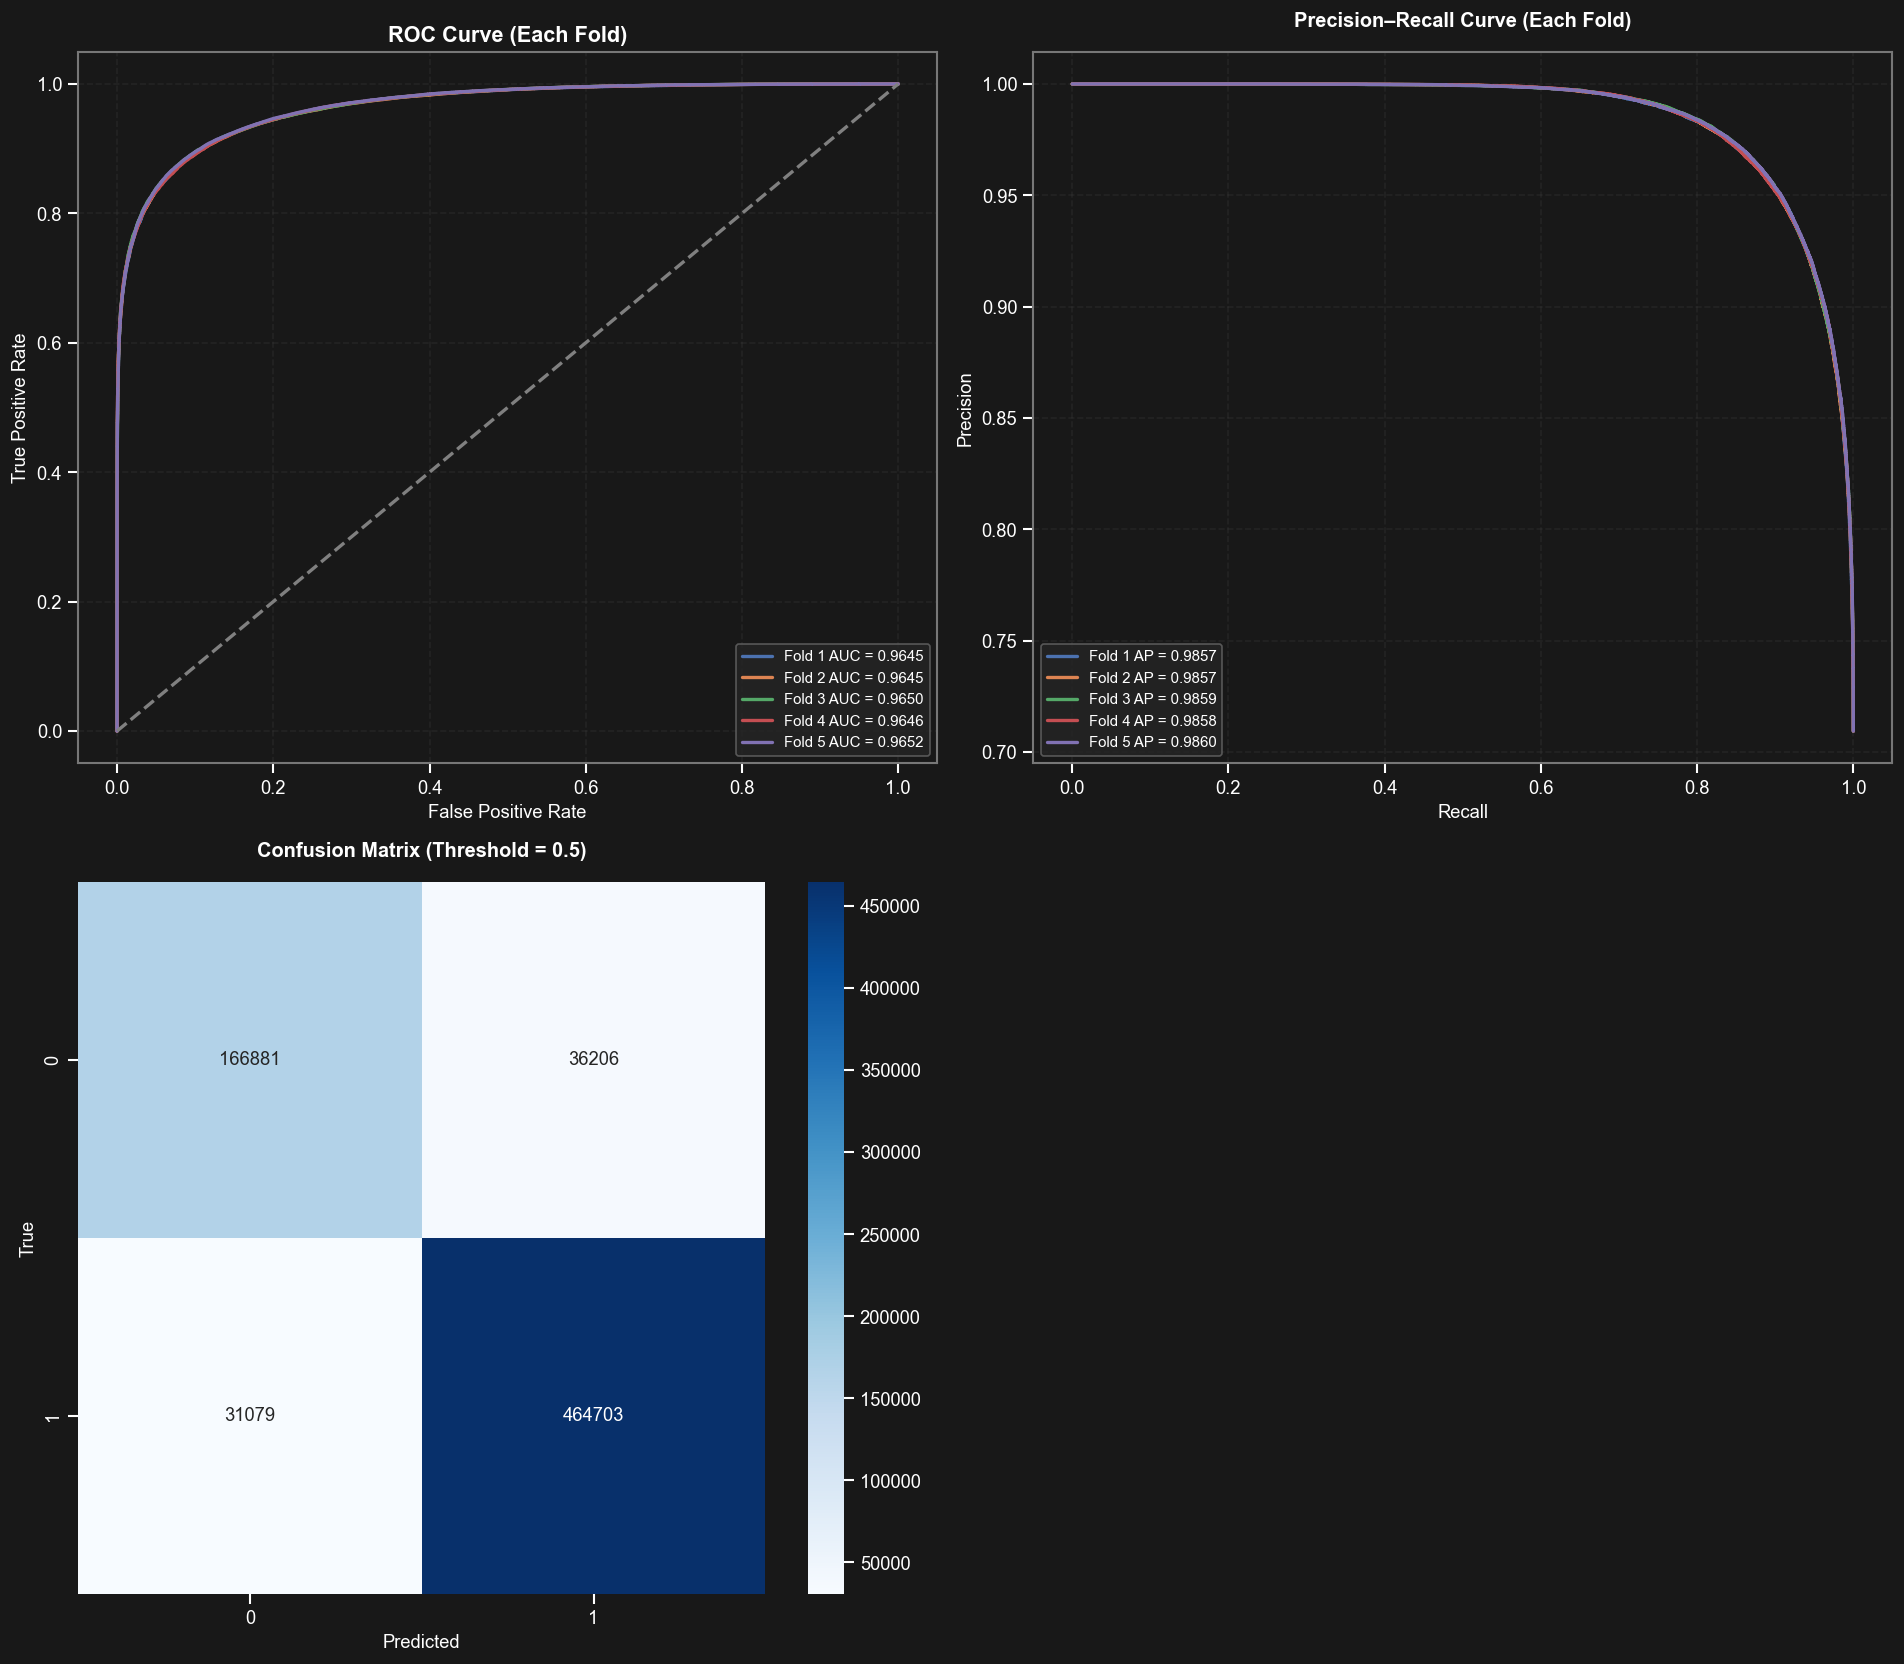

In [99]:
logger.info("="*80)
logger.info("XGBOOST TRAINING START")
logger.info("="*80)

# Since the positive class (Addicted) is already the majority,
# scale_pos_weight is intentionally not used because it is primarily designed
# to compensate for minority positive classes.

# XGBoost Hyperparameters
XGB_PARAM = {
    "n_estimators": 5000,
    "learning_rate": 0.03550101056304099,
    "max_depth": 5,
    "subsample": 0.9519100751825209,
    "colsample_bytree": 0.9766909852082994,
    "min_child_weight": 30,
    "gamma": 0.7416986129898809,
    "reg_alpha": 9.868917138642198e-08,
    "reg_lambda": 2.724606720807439,
    "random_state": CFG.RANDOM_STATE,
    "n_jobs": -1,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "verbose": 0,
    "tree_method": "hist",
    "device": "cuda",
    "max_bin": 256,
    "grow_policy": "lossguide",
    "enable_categorical": True,
    "booster": "gbtree",
    # "scale_pos_weight": scale_pos_weight,
}

# Store feature importance from each fold
fold_feature_importances_xgb = []

# Metric containers
fold_auc_xgb = []

# Cross-validation training loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    logger.debug(f"Starting Fold {fold}/{CFG.N_SPLIT_KFOLD}")

    # Split training and validation data
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]

    # Prepare test set for this fold
    X_test_fold = df_test[FEATURES].copy()

    # Train XGBoost model
    model_xgb = XGBClassifier(**XGB_PARAM, early_stopping_rounds=300)
    model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    logger.debug(
        f"Fold {fold} training completed | "
        f"Best iteration: {_get_best_iteration(model_xgb)}"
    )

    # Predict probability for positive class
    val_preds = model_xgb.predict_proba(X_val)[:, 1]

    # Store OOF predictions
    xgb_oof_preds[val_idx] = val_preds

    # Store fold predictions for plotting
    fold_preds_xgb.append((y_val.values, val_preds))

    # Average predictions across folds
    xgb_test_preds += model_xgb.predict_proba(X_test_fold)[:, 1] / kf.get_n_splits()

    # Evaluate fold performance
    fold_score = roc_auc_score(y_val, val_preds)
    fold_auc_xgb.append(fold_score)

    logger.debug(f"Fold {fold} - AUC: {fold_score:.5f}")

    feature_importance = model_xgb.feature_importances_
    fold_importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": feature_importance,
        "fold": fold
    })
    fold_feature_importances_xgb.append(fold_importance)
    logger.debug(f"Fold {fold} feature importance collected successfully")

    # Cleanup to save memory
    del model_xgb
    del X_train
    del y_train
    del feature_importance
    del fold_importance
    gc.collect()
    
    logger.debug(f"Fold {fold} temporary memory released")
    logger.debug("-" * 80)

# Final OOF evaluation
mean_auc = np.mean(fold_auc_xgb)
std_auc = np.std(fold_auc_xgb)
logger.info("="*80)
logger.info(f"XGB OOF AUC: {roc_auc_score(y, xgb_oof_preds):.5f}")
logger.info(f"Mean Fold AUC: {mean_auc:.5f} +/- {std_auc:.5f}")
logger.info("="*80)

# Aggregate Feature Importance    
feature_importance_all = pd.concat(fold_feature_importances_xgb, ignore_index=True)
feature_importance_xgb = (
    feature_importance_all
    .groupby("feature", as_index=False)
    .agg(
        importance_mean=("importance", "mean"),
        importance_std=("importance", "std")
    )
    .reset_index(drop=True)
)

logger.info("Feature importance successfully aggregated across folds")
logger.info(
    "\nTop 20 Feature Importance:\n"
    f"{feature_importance_xgb.head(20).to_string(index=False)}"
)
logger.info("="*80)

# Plot OOF + Fold Metrics
plot_oof_metrics(y_true=y.values, oof_preds=xgb_oof_preds, fold_preds=fold_preds_xgb, threshold=0.5)

## LGBMClassifier

2026-08-10 22:33:46 | INFO     | ================================================================================
2026-08-10 22:33:46 | INFO     | LIGHTGBM TRAINING START
2026-08-10 22:33:46 | INFO     | ================================================================================
2026-08-10 22:33:46 | DEBUG    | Starting Fold 1/5
2026-08-10 22:34:57 | DEBUG    | Fold 1 training completed | Best iteration: 3023
2026-08-10 22:35:09 | DEBUG    | Fold 1 - AUC: 0.96366
2026-08-10 22:35:09 | DEBUG    | Fold 1 feature importance collected successfully
2026-08-10 22:35:09 | DEBUG    | Fold 1 temporary memory released
2026-08-10 22:35:09 | DEBUG    | --------------------------------------------------------------------------------
2026-08-10 22:35:09 | DEBUG    | Starting Fold 2/5
2026-08-10 22:36:23 | DEBUG    | Fold 2 training completed | Best iteration: 3237
2026-08-10 22:36:34 | DEBUG    | Fold 2 - AUC: 0.96391
2026-08-10 22:36:34 | DEBUG    | Fold 2 feature importance collected successf

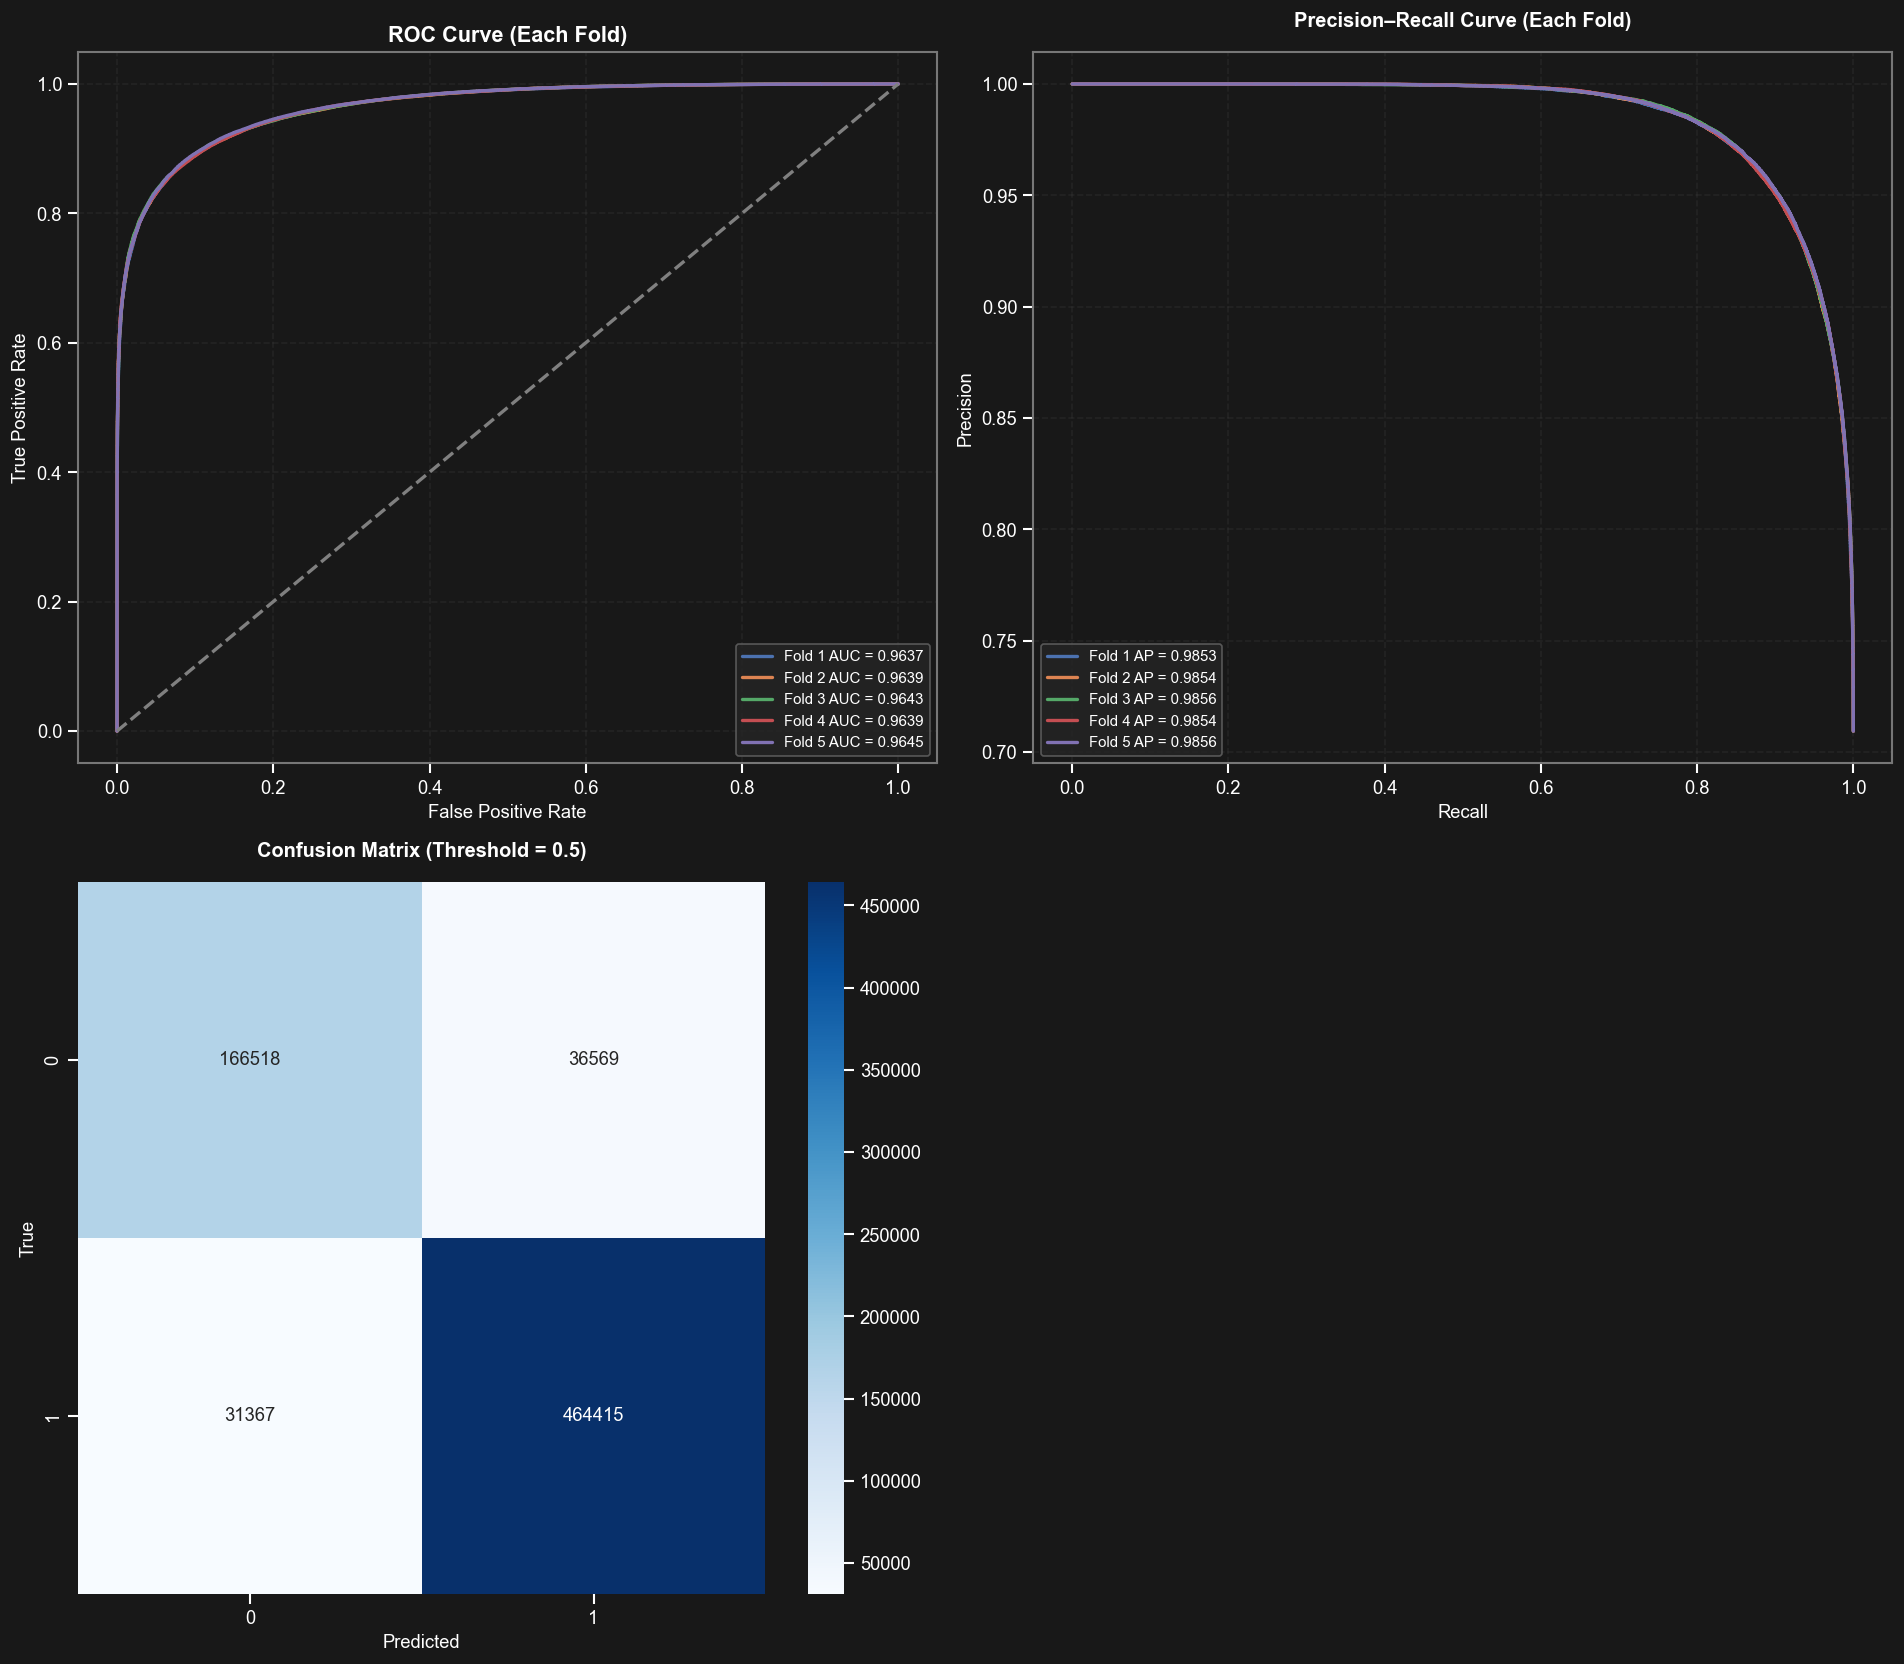

In [100]:
# Out-of-Fold predictions for training set (used for global validation)
lgbm_oof_preds = np.zeros(len(X))
# Averaged predictions for test set (from all folds)
lgbm_test_preds = np.zeros(len(df_test))

# Store predictions of each fold for later visualization/analysis
# Each element: (true_labels, predicted_probs)
fold_preds_lgbm = []

logger.info("="*80)
logger.info("LIGHTGBM TRAINING START")
logger.info("="*80)

# XGBoost Hyperparameters
LGBM_PARAM = {
    "n_estimators": 8000,
    "learning_rate": 0.03,
    "num_leaves": 63,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "objective": "binary",
    "random_state": CFG.RANDOM_STATE,
    "n_jobs": -1,
    "device": "cpu",
    "max_bin": 255,
    "metric": "AUC",
    "verbose": -1
}

# Store feature importance from each fold
fold_feature_importances_lgbm = []

# Metric containers
fold_auc_lgbm = []

# Cross-validation training loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    logger.debug(f"Starting Fold {fold}/{CFG.N_SPLIT_KFOLD}")

    # Split training and validation data
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]

    # Prepare test set for this fold
    X_test_fold = df_test[FEATURES].copy()

    # Train XGBoost model
    model_lgbm = LGBMClassifier(**LGBM_PARAM)
    model_lgbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[early_stopping(stopping_rounds=300, verbose=False)]
    )

    logger.debug(
        f"Fold {fold} training completed | "
        f"Best iteration: {_get_best_iteration(model_lgbm)}"
    )

    # Predict probability for positive class
    val_preds = model_lgbm.predict_proba(X_val)[:, 1]

    # Store OOF predictions
    lgbm_oof_preds[val_idx] = val_preds

    # Store fold predictions for plotting
    fold_preds_lgbm.append((y_val.values, val_preds))

    # Average predictions across folds
    lgbm_test_preds += model_lgbm.predict_proba(X_test_fold)[:, 1] / kf.get_n_splits()

    # Evaluate fold performance
    fold_score = roc_auc_score(y_val, val_preds)
    fold_auc_lgbm.append(fold_score)

    logger.debug(f"Fold {fold} - AUC: {fold_score:.5f}")

    feature_importance = model_lgbm.feature_importances_
    fold_importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": feature_importance,
        "fold": fold
    })
    fold_feature_importances_lgbm.append(fold_importance)
    logger.debug(f"Fold {fold} feature importance collected successfully")

    # Cleanup to save memory
    del model_lgbm
    del X_train
    del y_train
    del feature_importance
    del fold_importance
    gc.collect()

    logger.debug(f"Fold {fold} temporary memory released")
    logger.debug("-" * 80)

# Final OOF evaluation
mean_auc = np.mean(fold_auc_lgbm)
std_auc = np.std(fold_auc_lgbm)
logger.info("="*80)
logger.info(f"LGBM OOF AUC: {roc_auc_score(y, lgbm_oof_preds):.5f}")
logger.info(f"Mean Fold AUC: {mean_auc:.5f} +/- {std_auc:.5f}")
logger.info("="*80)

# Aggregate Feature Importance    
feature_importance_all = pd.concat(fold_feature_importances_lgbm, ignore_index=True)
feature_importance_lgbm = (
    feature_importance_all
    .groupby("feature", as_index=False)
    .agg(
        importance_mean=("importance", "mean"),
        importance_std=("importance", "std")
    )
    .reset_index(drop=True)
)

logger.info("Feature importance successfully aggregated across folds")
logger.info(
    "\nTop 20 Feature Importance:\n"
    f"{feature_importance_lgbm.head(20).to_string(index=False)}"
)
logger.info("="*80)

# Plot OOF + Fold Metrics
plot_oof_metrics(y_true=y.values, oof_preds=lgbm_oof_preds, fold_preds=fold_preds_lgbm, threshold=0.5)

## CatBoostClassifier

2026-08-10 22:42:20 | INFO     | ================================================================================
2026-08-10 22:42:20 | INFO     | CATBOOST TRAINING START
2026-08-10 22:42:20 | INFO     | ================================================================================
2026-08-10 22:42:20 | DEBUG    | Starting Fold 1/5
2026-08-10 22:43:30 | DEBUG    | Fold 1 training completed | Best iteration: 1999
2026-08-10 22:43:32 | DEBUG    | Fold 1 - AUC: 0.95930
2026-08-10 22:43:32 | DEBUG    | Fold 1 feature importance collected successfully
2026-08-10 22:43:32 | DEBUG    | Fold 1 temporary memory released
2026-08-10 22:43:32 | DEBUG    | --------------------------------------------------------------------------------
2026-08-10 22:43:32 | DEBUG    | Starting Fold 2/5
2026-08-10 22:45:58 | DEBUG    | Fold 2 training completed | Best iteration: 4849
2026-08-10 22:46:03 | DEBUG    | Fold 2 - AUC: 0.95982
2026-08-10 22:46:03 | DEBUG    | Fold 2 feature importance collected successf

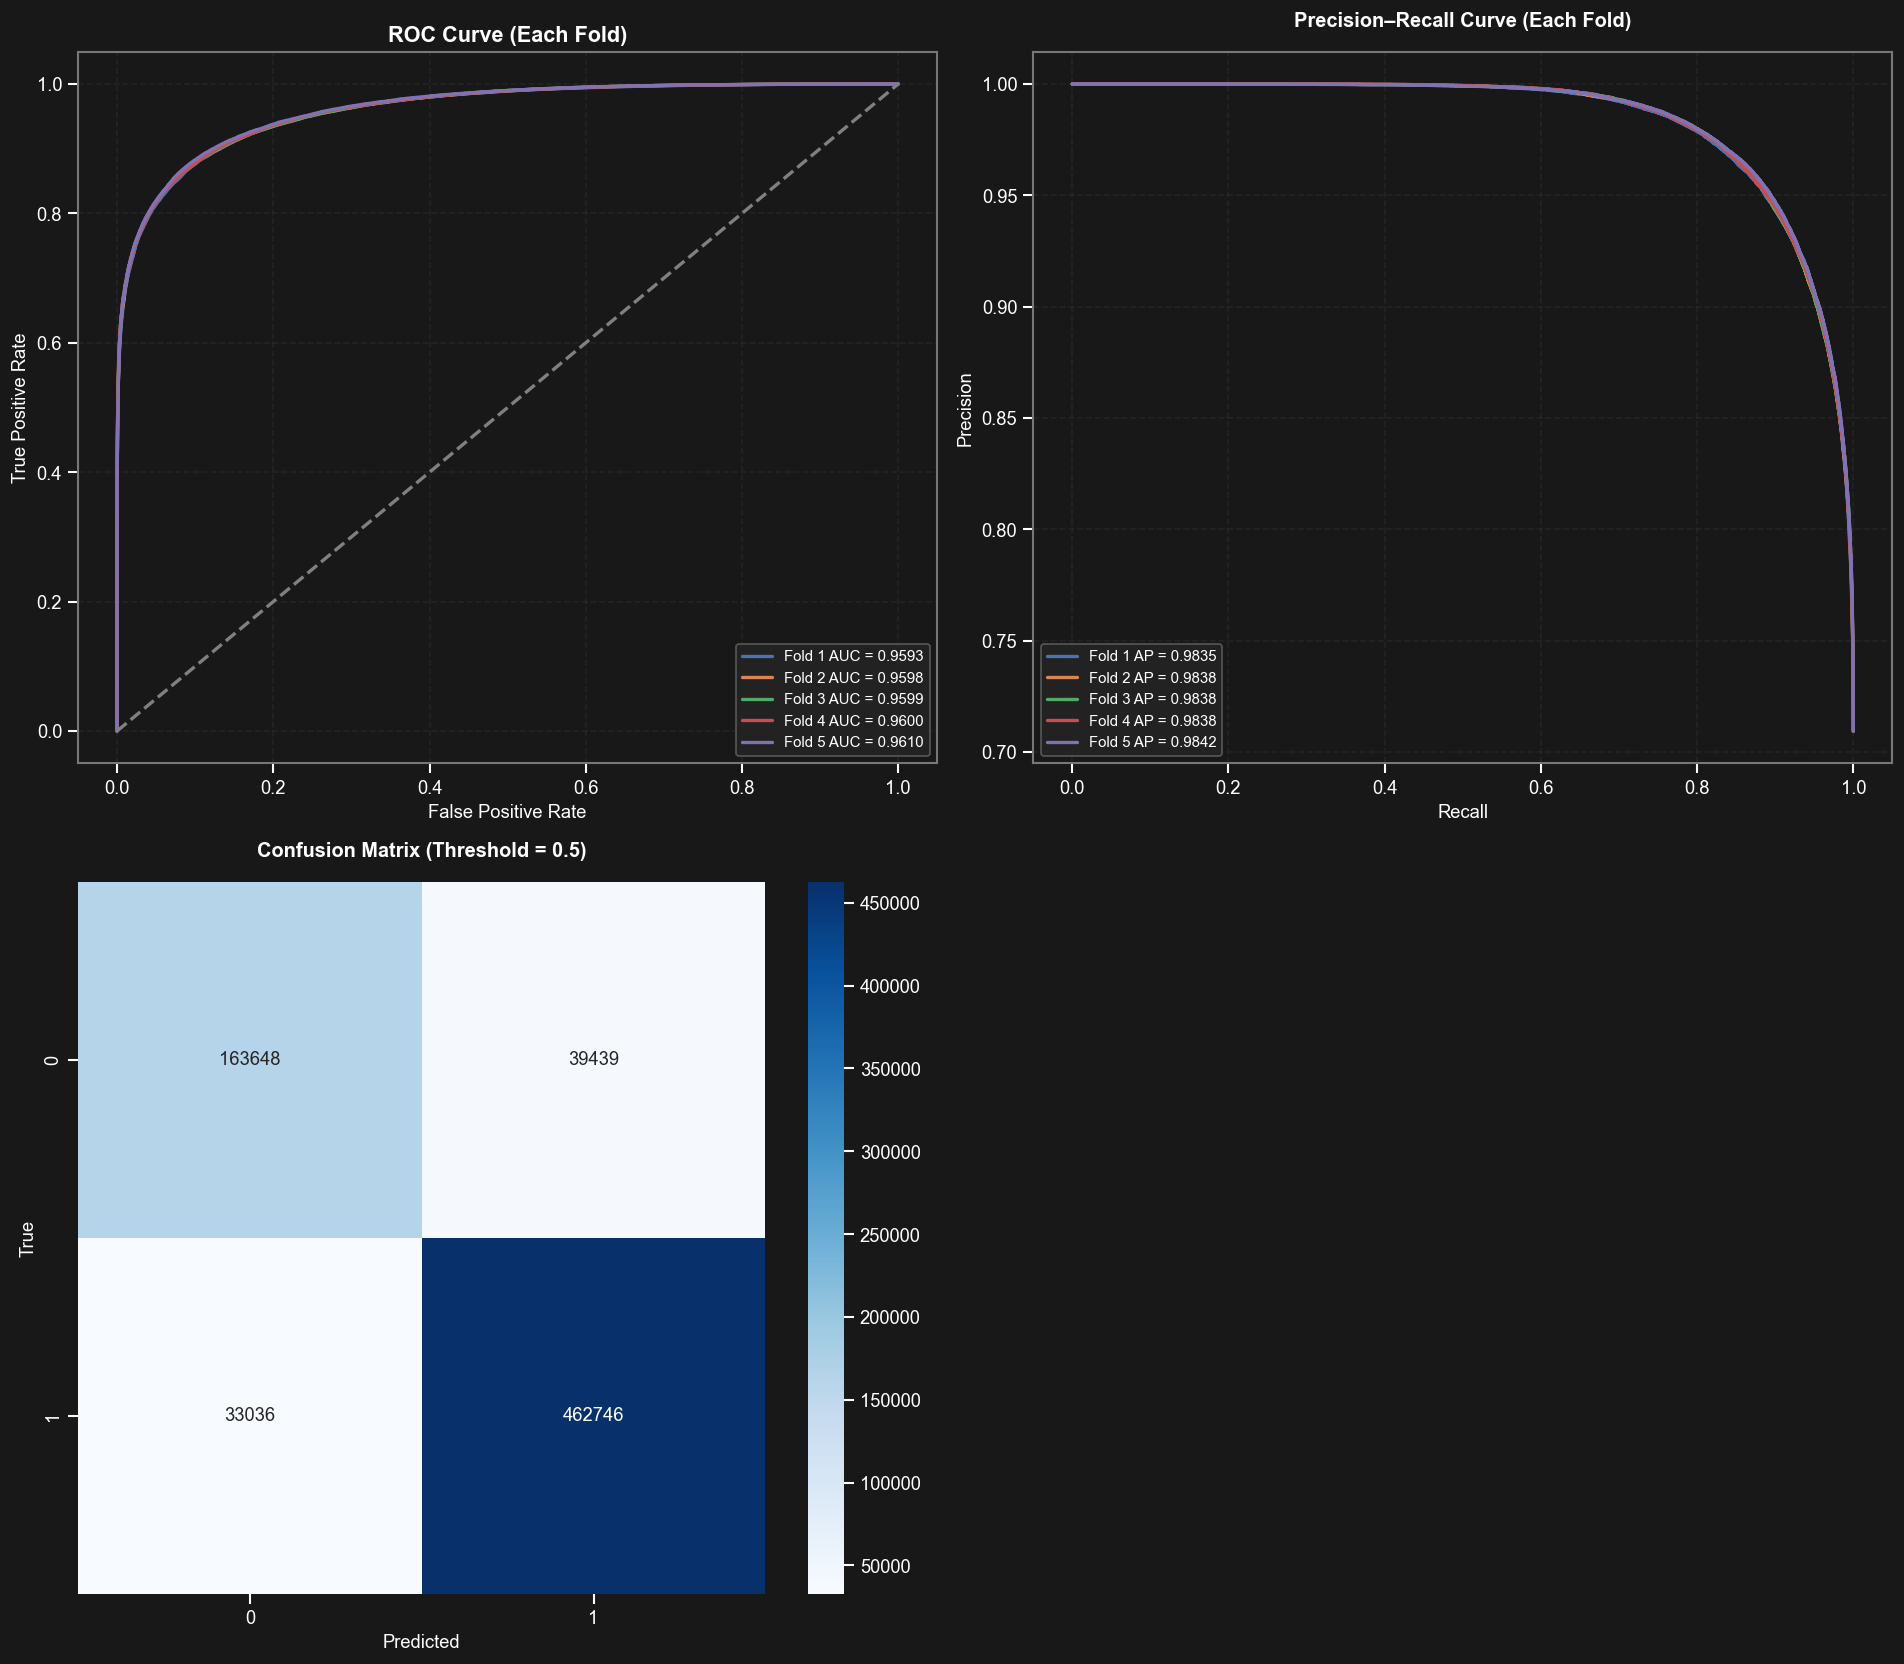

In [104]:
# Out-of-Fold predictions for training set (used for global validation)
cat_oof_preds = np.zeros(len(X))
# Averaged predictions for test set (from all folds)
cat_test_preds = np.zeros(len(df_test))

# Store predictions of each fold for later visualization/analysis
# Each element: (true_labels, predicted_probs)
fold_preds_cat = []

logger.info("="*80)
logger.info("CATBOOST TRAINING START")
logger.info("="*80)

# XGBoost Hyperparameters
CAT_PARAM = {
    "iterations": 6000, 
    "learning_rate": 0.02, 
    "depth": 8,
    "l2_leaf_reg": 3.0, 
    "random_seed": CFG.RANDOM_STATE,
    "task_type": "GPU",
    "devices": "0", 
    "verbose": False, 
    "eval_metric": "Logloss",
    "grow_policy": "Lossguide",
    "loss_function": "Logloss",
    "bootstrap_type": "Bernoulli",
    "verbose": 0,
    "thread_count": -1,
    "allow_writing_files": False
}

cat_features = cat_features + missing_features

# Store feature importance from each fold
fold_feature_importances_cat = []

# Metric containers
fold_auc_cat = []

# Cross-validation training loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    logger.debug(f"Starting Fold {fold}/{CFG.N_SPLIT_KFOLD}")

    # Split training and validation data
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]

    # Prepare test set for this fold
    X_test_fold = df_test[FEATURES].copy()

    # Train XGBoost model
    model_cat = CatBoostClassifier(**CAT_PARAM)
    model_cat.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        early_stopping_rounds=300,
        verbose=False
    )

    logger.debug(
        f"Fold {fold} training completed | "
        f"Best iteration: {_get_best_iteration(model_cat)}"
    )

    # Predict probability for positive class
    val_preds = model_cat.predict_proba(X_val)[:, 1]

    # Store OOF predictions
    cat_oof_preds[val_idx] = val_preds

    # Store fold predictions for plotting
    fold_preds_cat.append((y_val.values, val_preds))

    # Average predictions across folds
    cat_test_preds += model_cat.predict_proba(X_test_fold)[:, 1] / kf.get_n_splits()

    # Evaluate fold performance
    fold_score = roc_auc_score(y_val, val_preds)
    fold_auc_cat.append(fold_score)

    logger.debug(f"Fold {fold} - AUC: {fold_score:.5f}")

    feature_importance = model_cat.feature_importances_
    fold_importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": feature_importance,
        "fold": fold
    })
    fold_feature_importances_cat.append(fold_importance)
    logger.debug(f"Fold {fold} feature importance collected successfully")

    # Cleanup to save memory
    del model_cat
    del X_train
    del y_train
    del feature_importance
    del fold_importance
    gc.collect()

    logger.debug(f"Fold {fold} temporary memory released")
    logger.debug("-" * 80)

# Final OOF evaluation
mean_auc = np.mean(fold_auc_cat)
std_auc = np.std(fold_auc_cat)
logger.info("="*80)
logger.info(f"CATBOOST OOF AUC: {roc_auc_score(y, cat_oof_preds):.5f}")
logger.info(f"Mean Fold AUC: {mean_auc:.5f} +/- {std_auc:.5f}")
logger.info("="*80)

# Aggregate Feature Importance    
feature_importance_all = pd.concat(fold_feature_importances_cat, ignore_index=True)
feature_importance_cat = (
    feature_importance_all
    .groupby("feature", as_index=False)
    .agg(
        importance_mean=("importance", "mean"),
        importance_std=("importance", "std")
    )
    .reset_index(drop=True)
)

logger.info("Feature importance successfully aggregated across folds")
logger.info(
    "\nTop 20 Feature Importance:\n"
    f"{feature_importance_cat.head(20).to_string(index=False)}"
)
logger.info("="*80)

# Plot OOF + Fold Metrics
plot_oof_metrics(y_true=y.values, oof_preds=cat_oof_preds, fold_preds=fold_preds_cat, threshold=0.5)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Evaluation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Evaluation
    </h1>
</div>

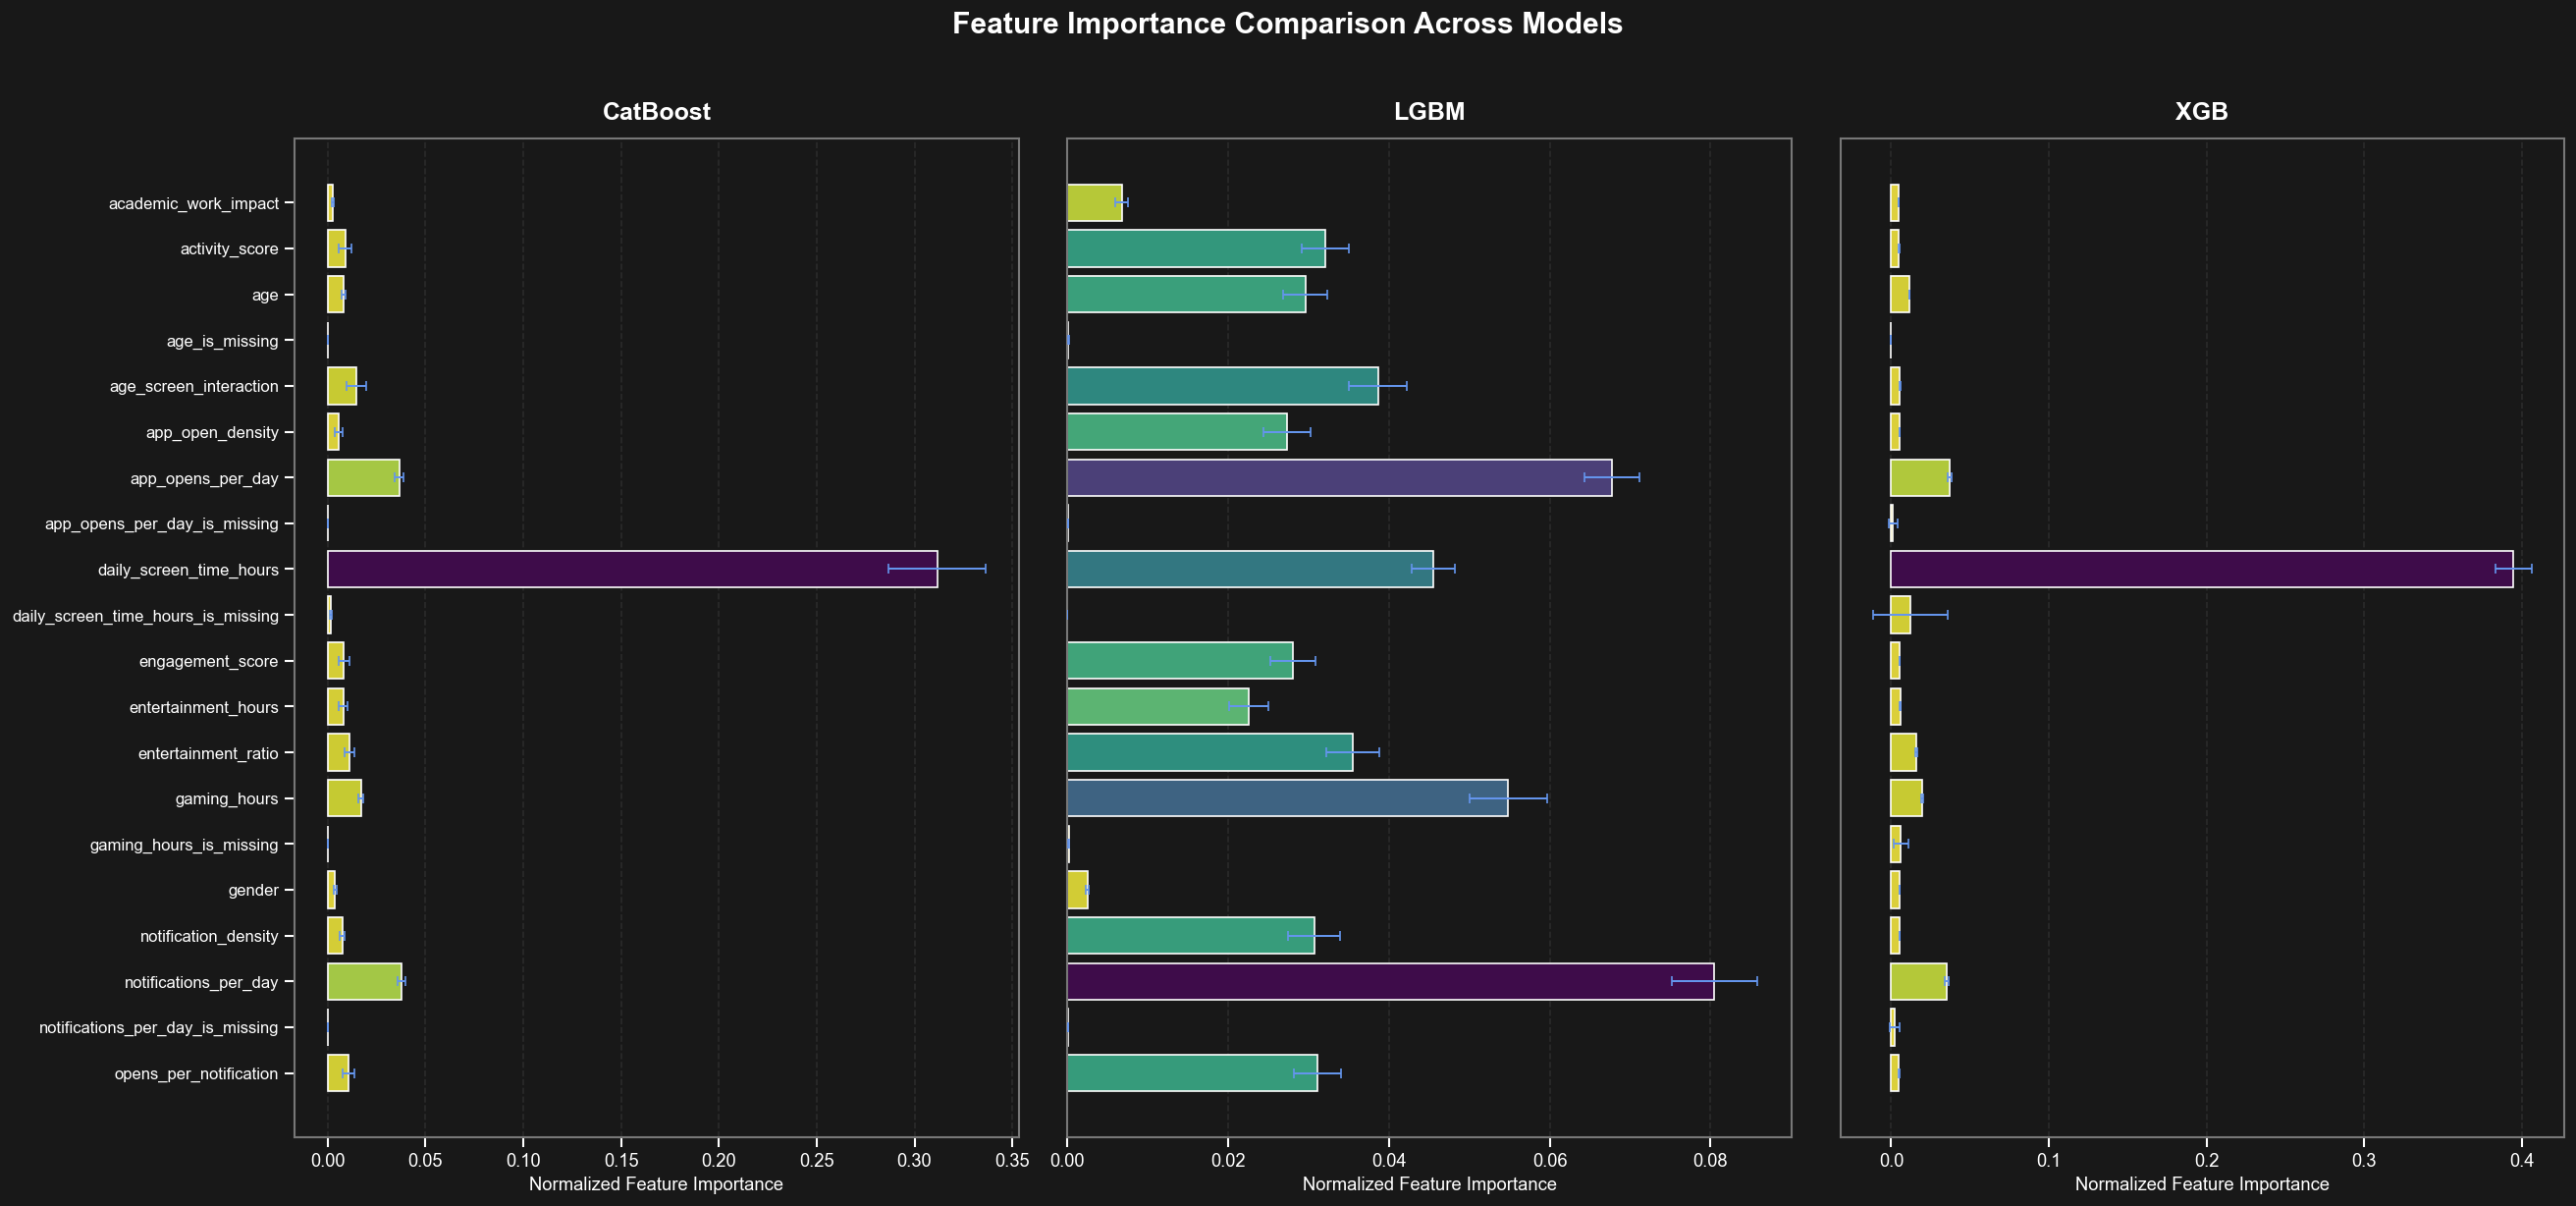

In [105]:
def plot_feature_importance_comparison(
    feature_importances: dict,
    top_n: int = 20,
    figsize: tuple = (22, 10),
    show_std: bool = True,
):
    """
    Compare normalized feature importance across multiple models.

    Notes
    -----
    - Features are displayed in the ORIGINAL order of each DataFrame.
    - No sorting or ranking is performed.
    - Only the first subplot displays feature names.
    """

    required_columns = {
        "feature",
        "importance_mean",
        "importance_std",
    }

    if not feature_importances:
        raise ValueError("feature_importances cannot be empty.")
    
    # Validate input    
    for model_name, df in feature_importances.items():
        missing = required_columns - set(df.columns)
        if missing:
            raise ValueError(f"{model_name} is missing required columns: {sorted(missing)}")

    # Create figure    
    n_models = len(feature_importances)
    fig, axes = plt.subplots(1, n_models, figsize=figsize, sharey=True)

    if n_models == 1:
        axes = [axes]
    
    # Plot each model    
    for idx, (ax, (model_name, importance_df)) in enumerate(zip(axes, feature_importances.items())):
        # Keep original order
        plot_df = importance_df.head(top_n).copy()
        # Normalize by ALL features
        total_importance = importance_df["importance_mean"].sum()
        if total_importance > 0:
            plot_df["importance_normalized"] = plot_df["importance_mean"] / total_importance
            plot_df["std_normalized"] = plot_df["importance_std"] / total_importance
        else:
            plot_df["importance_normalized"] = 0.0
            plot_df["std_normalized"] = 0.0

        # Draw bars
        sns.barplot(data=plot_df, x="importance_normalized", y="feature", hue="importance_normalized",
                    palette="viridis_r", legend=False, ax=ax)

        # Error bars
        if show_std:
            ax.errorbar(x=plot_df["importance_normalized"], y=np.arange(len(plot_df)), xerr=plot_df["std_normalized"], fmt="none",
                        ecolor="cornflowerblue", capsize=3, lw=1.2, zorder=10)
        
        # Styling        
        ax.set_title(model_name.replace("Classifier", ""), fontsize=15, fontweight="bold", pad=12)
        ax.set_xlabel("Normalized Feature Importance", fontsize=11)
        ax.set_ylabel("")
        ax.grid(axis="x", linestyle="--", alpha=0.3)
        ax.set_axisbelow(True)
        
        # Show feature names only once        
        if idx == 0:
            ax.tick_params(axis="y", labelsize=10)
        else:
            ax.tick_params(axis="y", left=False, labelleft=False)
    
    # Overall title    
    fig.suptitle("Feature Importance Comparison Across Models", fontsize=18, fontweight="bold", y=1.02)

    # Reduce spacing between subplots
    plt.subplots_adjust(wspace=0.08)
    plt.tight_layout()

    return fig

feature_importances = {
    "CatBoostClassifier": feature_importance_cat,
    "LGBMClassifier": feature_importance_lgbm,
    "XGBClassifier": feature_importance_xgb
}

fig = plot_feature_importance_comparison(
    feature_importances=feature_importances,
    top_n=20,
    show_std=True
)

In [106]:
xgb_auc = roc_auc_score(y, xgb_oof_preds)
lgb_auc = roc_auc_score(y, lgbm_oof_preds)
cat_auc = roc_auc_score(y, cat_oof_preds)

# AUC-weighted blend
total_auc = xgb_auc + lgb_auc + cat_auc
w_xgb = xgb_auc / total_auc
w_lgb = lgb_auc / total_auc
w_cat = cat_auc / total_auc

blended_oof = w_xgb * xgb_oof_preds + w_lgb * lgbm_oof_preds + w_cat * cat_oof_preds
blended_test = w_xgb * xgb_test_preds + w_lgb * lgbm_test_preds + w_cat * cat_test_preds

blend_auc = roc_auc_score(y, blended_oof)

logger.info("="*80)
logger.info("ENSEMBLE BLENDING")
logger.info("="*80)
logger.info(f"XGB OOF AUC: {xgb_auc:.5f} (Weight: {w_xgb:.5f})")
logger.info(f"LGBM OOF AUC: {lgb_auc:.5f} (Weight: {w_lgb:.5f})")
logger.info(f"CATBOOST OOF AUC: {cat_auc:.5f} (Weight: {w_cat:.5f})")
logger.info(f"Blended OOF AUC: {blend_auc:.5f}")
logger.info("="*80)

# Prepare submission file
submission = pd.DataFrame({
    "id": list_test_id,
    "addicted_label": blended_test
})

submission.to_csv("submission.csv", index=False)
print("\nSubmission file saved!")
submission.head()

2026-08-10 22:52:18 | INFO     | ================================================================================
2026-08-10 22:52:18 | INFO     | ENSEMBLE BLENDING
2026-08-10 22:52:18 | INFO     | ================================================================================
2026-08-10 22:52:18 | INFO     | XGB OOF AUC: 0.96476 (Weight: 0.33397)
2026-08-10 22:52:18 | INFO     | LGBM OOF AUC: 0.96405 (Weight: 0.33372)
2026-08-10 22:52:18 | INFO     | CATBOOST OOF AUC: 0.95998 (Weight: 0.33231)
2026-08-10 22:52:18 | INFO     | Blended OOF AUC: 0.96410
2026-08-10 22:52:18 | INFO     | ================================================================================

Submission file saved!


,id,addicted_label
0,691369,0.999580
1,691370,0.927203
2,691371,0.947363
3,691372,0.988608
4,691373,0.997844


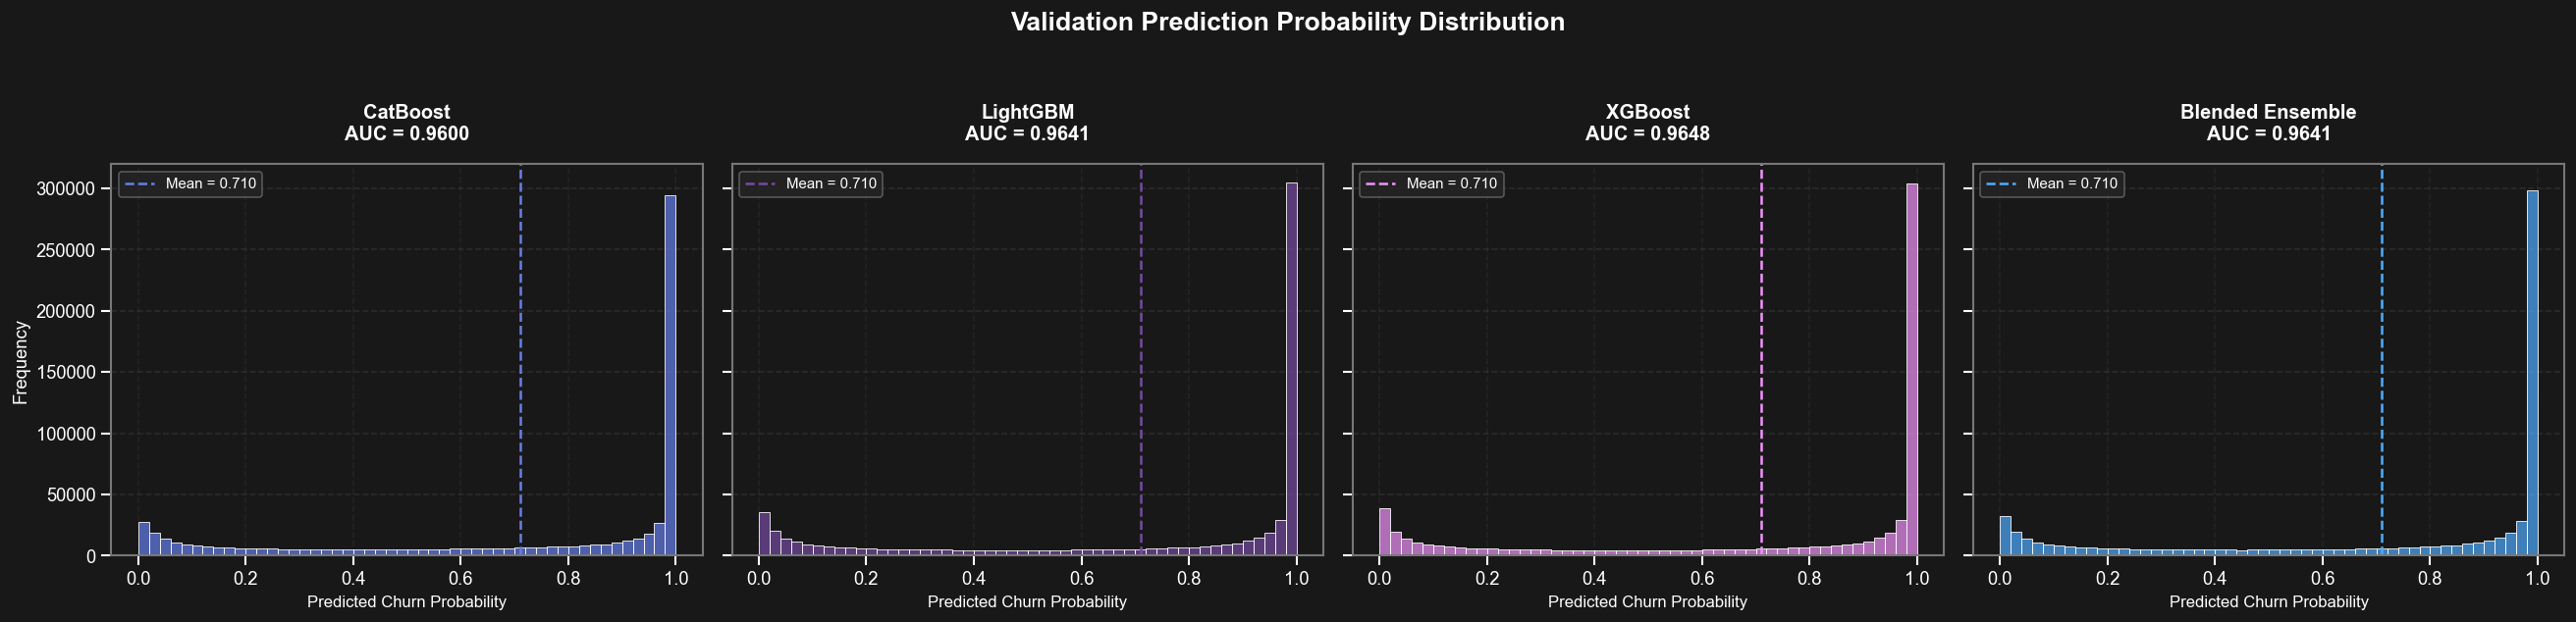

In [107]:
# Prediction Distribution Visualization
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
prediction_data = [
    ("CatBoost", cat_oof_preds, cat_auc),
    ("LightGBM", lgbm_oof_preds, lgb_auc),
    ("XGBoost",  xgb_oof_preds, xgb_auc),
    ("Blended Ensemble", blended_oof, blend_auc)
]

# Plot distributions
colors = list(CFG.COLORS.values())
for i, (ax, (model_name, predictions, auc)) in enumerate(zip(axes, prediction_data)):
    sns.histplot(predictions, color=colors[i], alpha=0.7, ax=ax, bins=50)
    ax.axvline(predictions.mean(), color=colors[i], linestyle="--", linewidth=1.5, label=f"Mean = {predictions.mean():.3f}")
    ax.set_title(f"{model_name}\nAUC = {auc:.4f}", fontsize=12, fontweight="bold", pad=15)
    ax.set_xlabel("Predicted Churn Probability", fontsize=10)
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

# Final layout
fig.suptitle("Validation Prediction Probability Distribution", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendation
    </h1>
</div>


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    font-size:22px;
    font-weight:600;
    margin-bottom:18px;
">
💡 Recommendations
</div>

<ul style="line-height:1.9;font-size:15px;">

<li>
<b style="color:#ff6b6b;">Prioritize behavioral indicators</b> such as
<b>daily screen time</b>, <b>weekend screen time</b>, and
<b>social media usage</b>, as these are the strongest predictors of smartphone addiction.
</li>

<li>
Implement <b>early warning systems</b> that identify users with excessive daily or weekend screen time and encourage healthier digital habits through timely reminders or usage limits.
</li>

<li>
Monitor <b>secondary behavioral signals</b> such as gaming time, work/study screen time, and app opening frequency to improve risk assessment when combined with primary indicators.
</li>

<li>
Avoid relying heavily on <b>demographic characteristics</b> (e.g., age or gender) or weak behavioral factors (e.g., notifications, sleep duration, stress level), as they contribute little to distinguishing smartphone addiction.
</li>

<li>
Focus intervention strategies on <b>reducing prolonged screen exposure</b> and <b>social media engagement</b>, which are likely to have the greatest impact on lowering smartphone addiction risk.
</li>

</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy coding 🙌😊
    </p>
</div>
